# ⚡️ Energy-Based Models

In this notebook, we'll walk through the steps required to train your own Energy Based Model to predict the distribution of a demo dataset

The code is adapted from the excellent ['Deep Energy-Based Generative Models' tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial8/Deep_Energy_Models.html) created by Phillip Lippe.

In [3]:
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Add parent directory to path so notebooks.utils can be found
sys.path.insert(0, os.path.abspath(".."))

import tensorflow as tf
from tensorflow.keras import (
    datasets,
    layers,
    models,
    optimizers,
    activations,
    metrics,
    callbacks,
)

from notebooks.utils import display, sample_batch
import random

# Create output and models directories if they don't exist
os.makedirs("./output", exist_ok=True)
os.makedirs("./models", exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. Parameters <a name="parameters"></a>

In [4]:
IMAGE_SIZE = 32
CHANNELS = 1
STEP_SIZE = 10
STEPS = 60
NOISE = 0.005
ALPHA = 0.1
GRADIENT_CLIP = 0.03
BATCH_SIZE = 128
BUFFER_SIZE = 8192
LEARNING_RATE = 0.0001
EPOCHS = 120
LOAD_MODEL = False

In [5]:
# Load the data
(x_train, _), (x_test, _) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Preprocess the data


def preprocess(imgs):
    """
    Normalize and reshape the images
    """
    imgs = (imgs.astype("float32") - 127.5) / 127.5
    imgs = np.pad(imgs, ((0, 0), (2, 2), (2, 2)), constant_values=-1.0)
    imgs = np.expand_dims(imgs, -1)
    return imgs


x_train = preprocess(x_train)
x_test = preprocess(x_test)

In [7]:
x_train = tf.data.Dataset.from_tensor_slices(x_train).batch(BATCH_SIZE)
x_test = tf.data.Dataset.from_tensor_slices(x_test).batch(BATCH_SIZE)

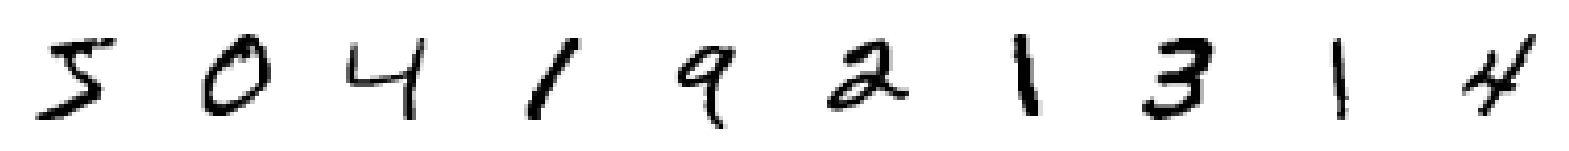

In [8]:
# Show some items of clothing from the training set
train_sample = sample_batch(x_train)
display(train_sample)

## 1. Build the EBM network <a name="train"></a>

In [9]:
ebm_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
x = layers.Conv2D(
    16, kernel_size=5, strides=2, padding="same", activation=activations.swish
)(ebm_input)
x = layers.Conv2D(
    32, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Conv2D(
    64, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Conv2D(
    64, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation=activations.swish)(x)
ebm_output = layers.Dense(1)(x)
model = models.Model(ebm_input, ebm_output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,993 (300.75 KB)

 Trainable params: 76,993 (300.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
if LOAD_MODEL:
    model.load_weights("./models/model.weights.h5")

## 2. Set up a Langevin sampler function <a name="sampler"></a>

In [11]:
# Function to generate samples using Langevin Dynamics
def generate_samples(
    model, inp_imgs, steps, step_size, noise, return_img_per_step=False
):
    imgs_per_step = []
    for _ in range(steps):
        inp_imgs += tf.random.normal(inp_imgs.shape, mean=0, stddev=noise)
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)
        with tf.GradientTape() as tape:
            tape.watch(inp_imgs)
            out_score = model(inp_imgs)
        grads = tape.gradient(out_score, inp_imgs)
        grads = tf.clip_by_value(grads, -GRADIENT_CLIP, GRADIENT_CLIP)
        inp_imgs += step_size * grads
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)
        if return_img_per_step:
            imgs_per_step.append(inp_imgs)
    if return_img_per_step:
        return tf.stack(imgs_per_step, axis=0)
    else:
        return inp_imgs

## 3. Set up a buffer to store examples <a name="buffer"></a>

In [12]:
class Buffer:
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.examples = [
            tf.random.uniform(shape=(1, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2
            - 1
            for _ in range(BATCH_SIZE)
        ]

    def sample_new_exmps(self, steps, step_size, noise):
        n_new = np.random.binomial(BATCH_SIZE, 0.05)
        rand_imgs = (
            tf.random.uniform((n_new, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
        )
        old_imgs = tf.concat(
            random.choices(self.examples, k=BATCH_SIZE - n_new), axis=0
        )
        inp_imgs = tf.concat([rand_imgs, old_imgs], axis=0)
        inp_imgs = generate_samples(
            self.model, inp_imgs, steps=steps, step_size=step_size, noise=noise
        )
        self.examples = tf.split(inp_imgs, BATCH_SIZE, axis=0) + self.examples
        self.examples = self.examples[:BUFFER_SIZE]
        return inp_imgs

In [13]:
class EBM(models.Model):
    def __init__(self):
        super(EBM, self).__init__()
        self.model = model
        self.buffer = Buffer(self.model)
        self.alpha = ALPHA
        self.loss_metric = metrics.Mean(name="loss")
        self.reg_loss_metric = metrics.Mean(name="reg")
        self.cdiv_loss_metric = metrics.Mean(name="cdiv")
        self.real_out_metric = metrics.Mean(name="real")
        self.fake_out_metric = metrics.Mean(name="fake")

    @property
    def metrics(self):
        return [
            self.loss_metric,
            self.reg_loss_metric,
            self.cdiv_loss_metric,
            self.real_out_metric,
            self.fake_out_metric,
        ]

    def train_step(self, real_imgs):
        real_imgs += tf.random.normal(
            shape=tf.shape(real_imgs), mean=0, stddev=NOISE
        )
        real_imgs = tf.clip_by_value(real_imgs, -1.0, 1.0)
        fake_imgs = self.buffer.sample_new_exmps(
            steps=STEPS, step_size=STEP_SIZE, noise=NOISE
        )
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)
        with tf.GradientTape() as training_tape:
            real_out, fake_out = tf.split(self.model(inp_imgs), 2, axis=0)
            cdiv_loss = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(
                real_out, axis=0
            )
            reg_loss = self.alpha * tf.reduce_mean(
                real_out**2 + fake_out**2, axis=0
            )
            loss = cdiv_loss + reg_loss
        grads = training_tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(
            zip(grads, self.model.trainable_variables)
        )
        self.loss_metric.update_state(loss)
        self.reg_loss_metric.update_state(reg_loss)
        self.cdiv_loss_metric.update_state(cdiv_loss)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, real_imgs):
        batch_size = real_imgs.shape[0]
        fake_imgs = (
            tf.random.uniform((batch_size, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
            * 2
            - 1
        )
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)
        real_out, fake_out = tf.split(self.model(inp_imgs), 2, axis=0)
        cdiv = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(
            real_out, axis=0
        )
        self.cdiv_loss_metric.update_state(cdiv)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))
        return {m.name: m.result() for m in self.metrics[2:]}

In [14]:
ebm = EBM()

## 4. Train the EBM network <a name="train"></a>

In [15]:
# Compile and train the model
ebm.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE), run_eagerly=True
)

In [16]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        self.num_img = num_img

    def on_epoch_end(self, epoch, logs=None):
        start_imgs = (
            np.random.uniform(
                size=(self.num_img, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
            )
            * 2
            - 1
        )
        generated_images = generate_samples(
            ebm.model,
            start_imgs,
            steps=1000,
            step_size=STEP_SIZE,
            noise=NOISE,
            return_img_per_step=False,
        )
        generated_images = generated_images.numpy()
        display(
            generated_images,
            save_to="./output/generated_img_%03d.png" % (epoch),
        )

        example_images = tf.concat(
            random.choices(ebm.buffer.examples, k=10), axis=0
        )
        example_images = example_images.numpy()
        display(
            example_images, save_to="./output/example_img_%03d.png" % (epoch)
        )


image_generator_callback = ImageGenerator(num_img=10)

In [19]:
class SaveModel(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        model.save_weights("./models/model.weights.h5")


save_model_callback = SaveModel()

Epoch 1/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -0.0038 - fake: 0.0046 - loss: -0.0018 - real: 0.0083 - reg: 0.0020
Saved to ./output/generated_img_000.png


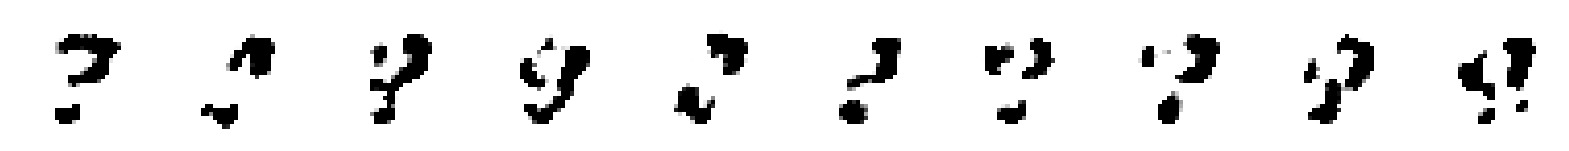


Saved to ./output/example_img_000.png


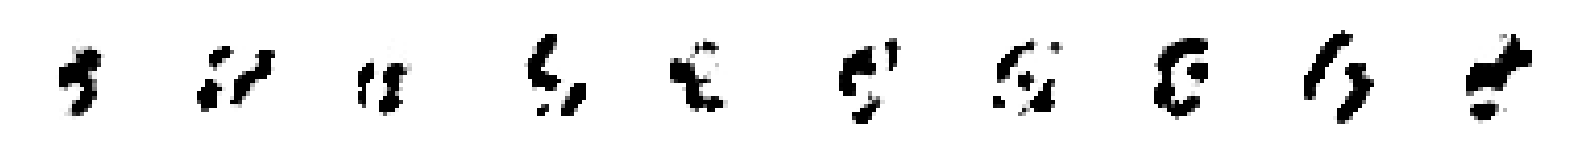

469/469 ━━━━━━━━━━━━━━━━━━━━ 595s 1s/step - cdiv: -0.0046 - fake: 0.0045 - loss: -0.0028 - real: 0.0091 - reg: 0.0018 - val_cdiv: -1.5443 - val_fake: -1.6412 - val_real: -0.0969
Epoch 2/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -0.0035 - fake: 7.4117e-04 - loss: -0.0022 - real: 0.0043 - reg: 0.0013
Saved to ./output/generated_img_001.png


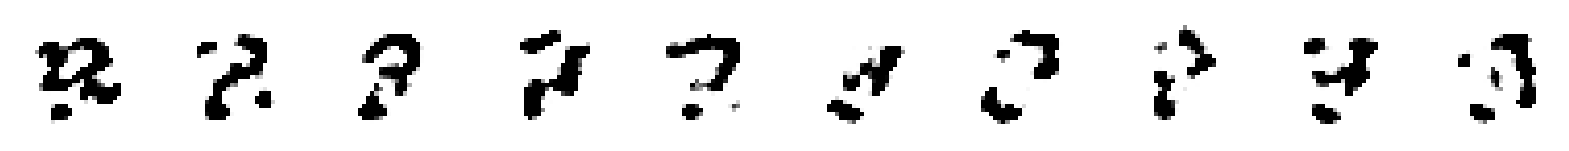


Saved to ./output/example_img_001.png


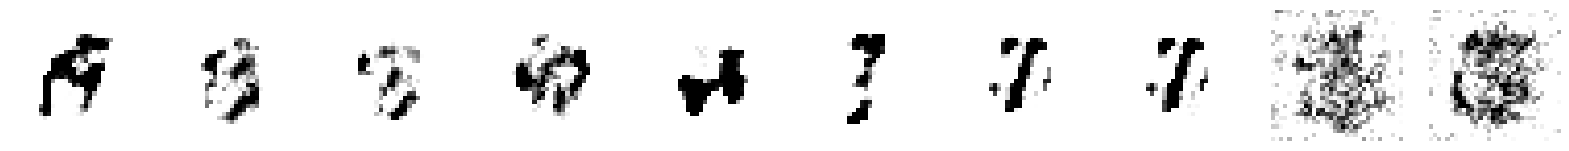

469/469 ━━━━━━━━━━━━━━━━━━━━ 623s 1s/step - cdiv: -0.0024 - fake: 0.0013 - loss: -0.0013 - real: 0.0037 - reg: 0.0011 - val_cdiv: -1.7494 - val_fake: -1.8333 - val_real: -0.0839
Epoch 3/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -0.0024 - fake: 7.3937e-04 - loss: -0.0014 - real: 0.0031 - reg: 9.8573e-04
Saved to ./output/generated_img_002.png


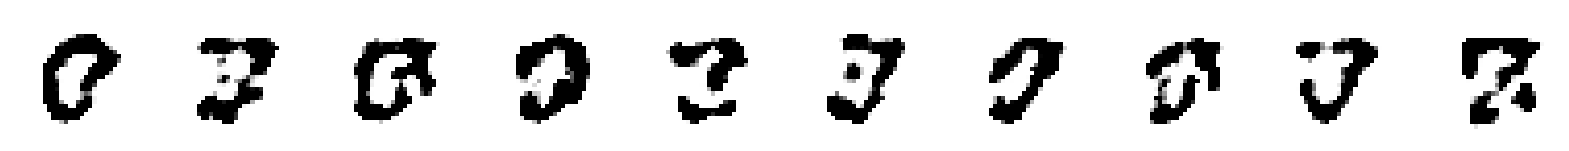


Saved to ./output/example_img_002.png


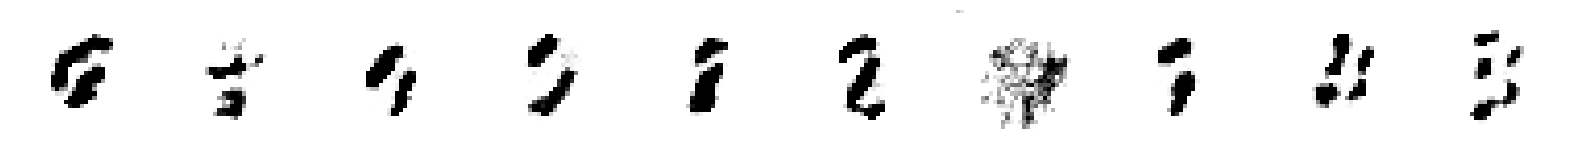

469/469 ━━━━━━━━━━━━━━━━━━━━ 636s 1s/step - cdiv: -0.0014 - fake: 0.0012 - loss: -6.5477e-04 - real: 0.0026 - reg: 7.6578e-04 - val_cdiv: -2.0099 - val_fake: -2.0656 - val_real: -0.0557
Epoch 4/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -4.7152e-04 - fake: 0.0016 - loss: 8.3349e-05 - real: 0.0020 - reg: 5.5487e-04
Saved to ./output/generated_img_003.png


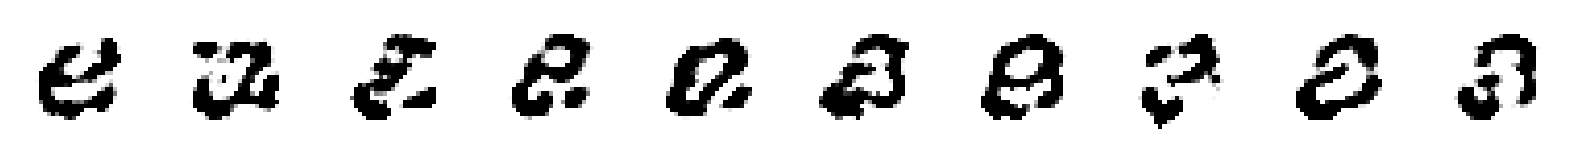


Saved to ./output/example_img_003.png


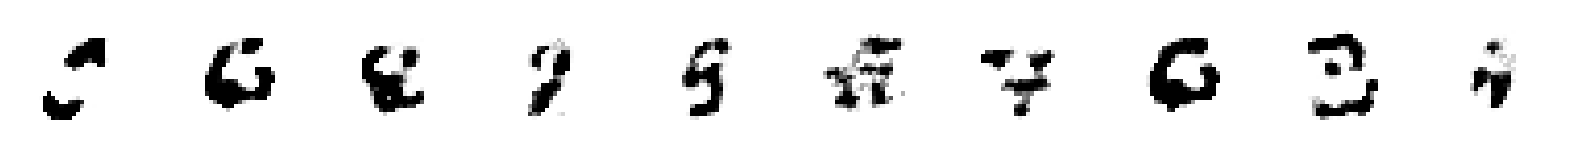

469/469 ━━━━━━━━━━━━━━━━━━━━ 587s 1s/step - cdiv: 3.2645e-04 - fake: 0.0012 - loss: 7.2239e-04 - real: 8.8781e-04 - reg: 3.9594e-04 - val_cdiv: -2.1290 - val_fake: -2.1756 - val_real: -0.0466
Epoch 5/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.4359e-04 - fake: -1.2737e-04 - loss: 1.3723e-04 - real: 1.1623e-04 - reg: 3.8082e-04
Saved to ./output/generated_img_004.png


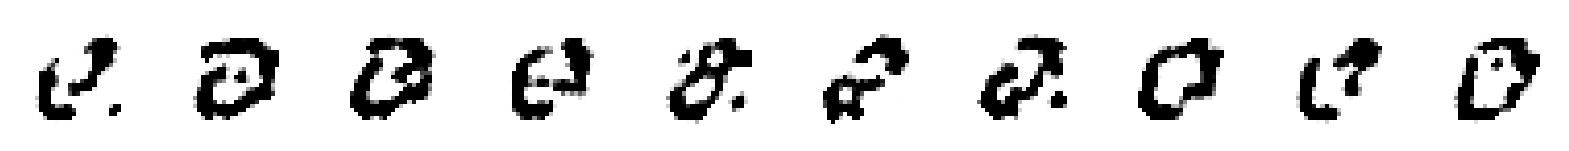


Saved to ./output/example_img_004.png


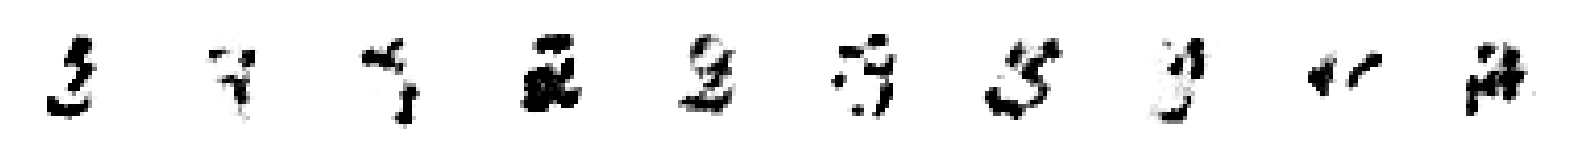

469/469 ━━━━━━━━━━━━━━━━━━━━ 612s 1s/step - cdiv: -1.3261e-04 - fake: 0.0010 - loss: 1.6723e-04 - real: 0.0011 - reg: 2.9984e-04 - val_cdiv: -2.4135 - val_fake: -2.4442 - val_real: -0.0307
Epoch 6/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 6.8496e-04 - fake: -6.7811e-04 - loss: 9.4352e-04 - real: -0.0014 - reg: 2.5855e-04
Saved to ./output/generated_img_005.png


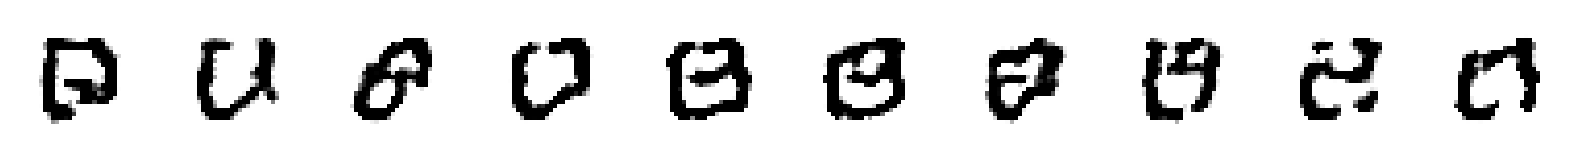


Saved to ./output/example_img_005.png


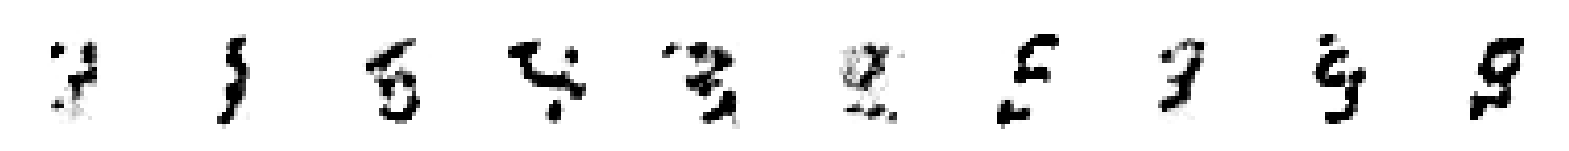

469/469 ━━━━━━━━━━━━━━━━━━━━ 621s 1s/step - cdiv: 4.3620e-04 - fake: 4.1890e-04 - loss: 6.5377e-04 - real: -1.7301e-05 - reg: 2.1757e-04 - val_cdiv: -2.5936 - val_fake: -2.6275 - val_real: -0.0339
Epoch 7/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -8.9181e-05 - fake: -1.6261e-04 - loss: 1.4887e-04 - real: -7.3428e-05 - reg: 2.3805e-04
Saved to ./output/generated_img_006.png


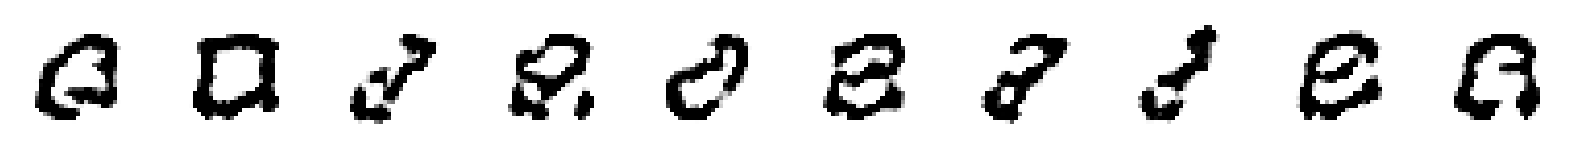


Saved to ./output/example_img_006.png


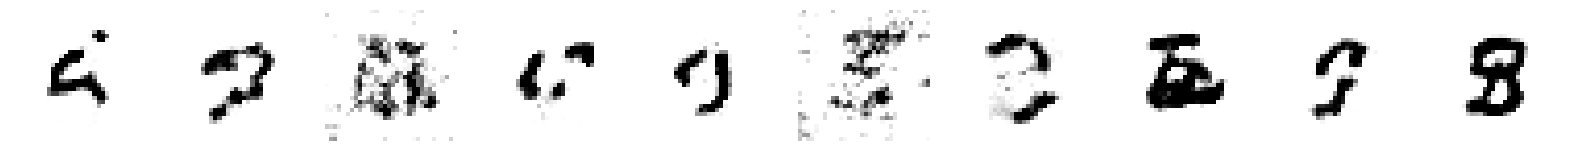

469/469 ━━━━━━━━━━━━━━━━━━━━ 677s 1s/step - cdiv: 6.9309e-05 - fake: 8.0593e-04 - loss: 2.6489e-04 - real: 7.3662e-04 - reg: 1.9558e-04 - val_cdiv: -2.9036 - val_fake: -2.9408 - val_real: -0.0372
Epoch 8/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 4.5054e-04 - fake: -9.9158e-04 - loss: 7.1730e-04 - real: -0.0014 - reg: 2.6675e-04
Saved to ./output/generated_img_007.png


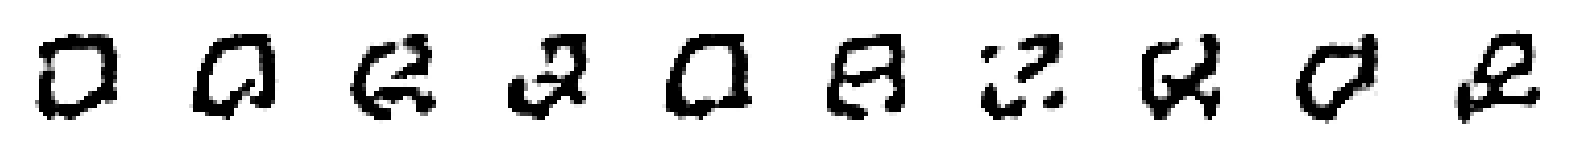


Saved to ./output/example_img_007.png


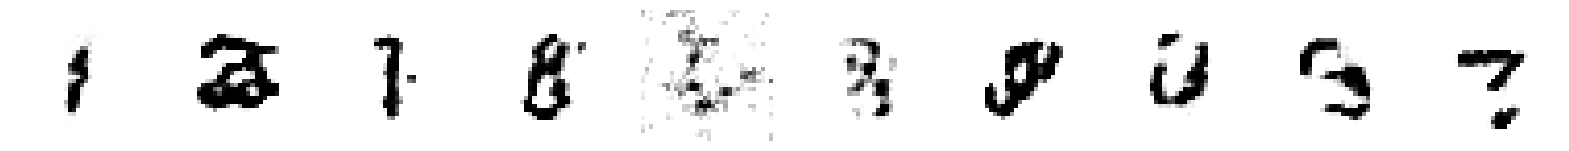

469/469 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - cdiv: 2.8400e-04 - fake: 7.1036e-04 - loss: 4.9187e-04 - real: 4.2636e-04 - reg: 2.0787e-04 - val_cdiv: -3.2099 - val_fake: -3.2392 - val_real: -0.0293
Epoch 9/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 6.4588e-04 - fake: -0.0019 - loss: 9.4549e-04 - real: -0.0026 - reg: 2.9961e-04
Saved to ./output/generated_img_008.png


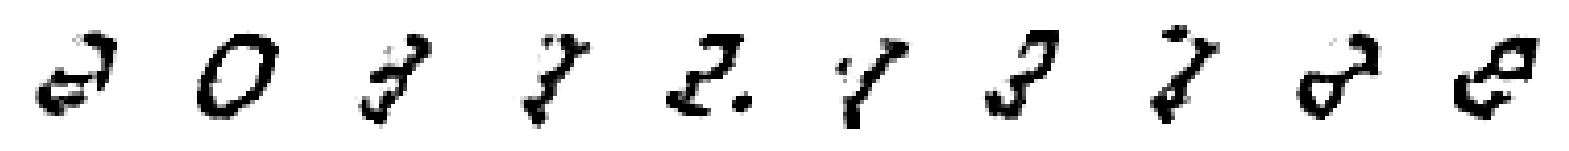


Saved to ./output/example_img_008.png


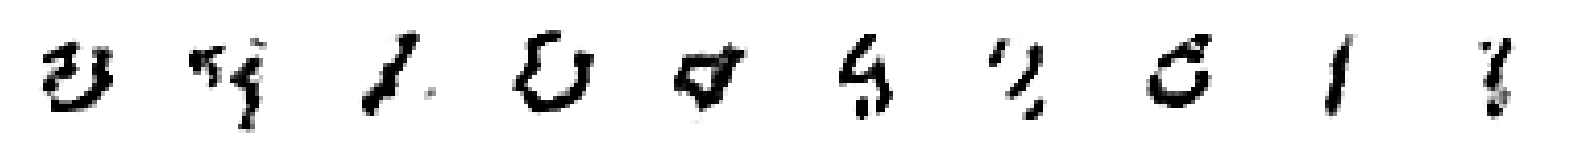

469/469 ━━━━━━━━━━━━━━━━━━━━ 702s 1s/step - cdiv: 4.0708e-04 - fake: 6.8741e-04 - loss: 6.3396e-04 - real: 2.8033e-04 - reg: 2.2688e-04 - val_cdiv: -3.5456 - val_fake: -3.5289 - val_real: 0.0167
Epoch 10/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.6423e-05 - fake: -0.0019 - loss: 2.5086e-04 - real: -0.0019 - reg: 2.7728e-04
Saved to ./output/generated_img_009.png


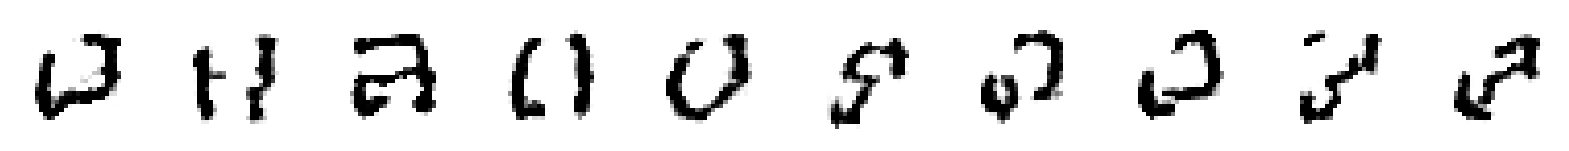


Saved to ./output/example_img_009.png


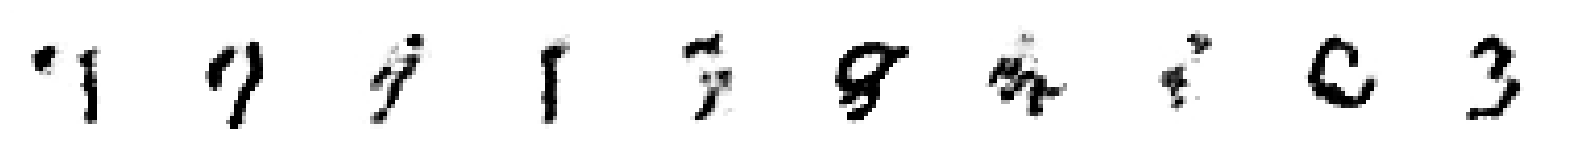

469/469 ━━━━━━━━━━━━━━━━━━━━ 708s 2s/step - cdiv: 8.6105e-05 - fake: 5.9907e-04 - loss: 2.9682e-04 - real: 5.1297e-04 - reg: 2.1071e-04 - val_cdiv: -3.8477 - val_fake: -3.8386 - val_real: 0.0091
Epoch 11/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 2.7700e-04 - fake: -0.0019 - loss: 6.0473e-04 - real: -0.0022 - reg: 3.2773e-04
Saved to ./output/generated_img_010.png


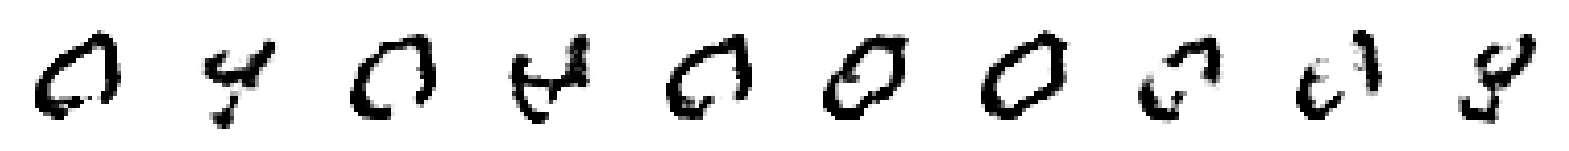


Saved to ./output/example_img_010.png


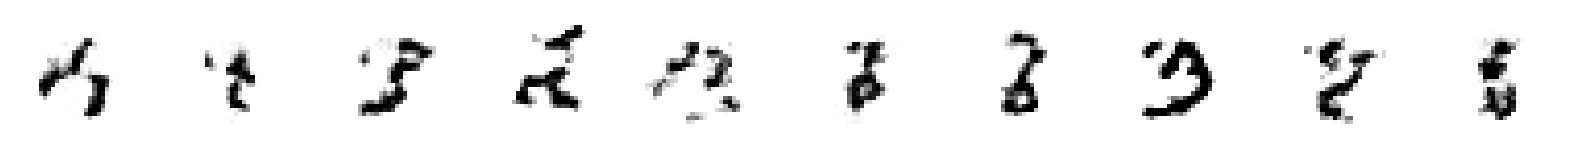

469/469 ━━━━━━━━━━━━━━━━━━━━ 684s 1s/step - cdiv: 1.6337e-04 - fake: 3.5729e-04 - loss: 4.0549e-04 - real: 1.9393e-04 - reg: 2.4212e-04 - val_cdiv: -4.1476 - val_fake: -4.1336 - val_real: 0.0139
Epoch 12/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.9511e-04 - fake: -0.0016 - loss: 1.2955e-04 - real: -0.0014 - reg: 3.2466e-04
Saved to ./output/generated_img_011.png


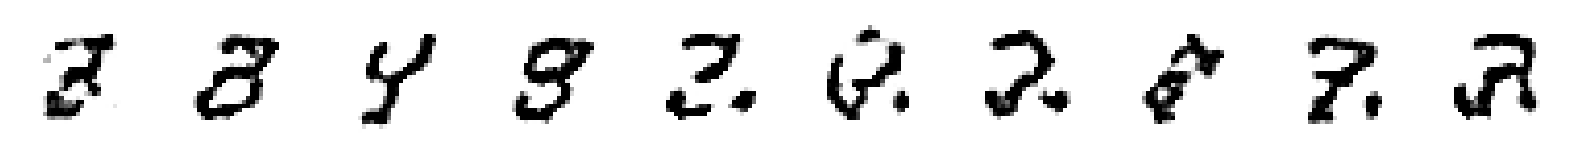


Saved to ./output/example_img_011.png


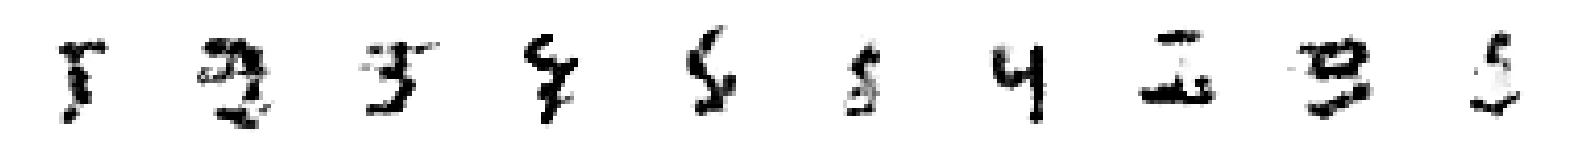

469/469 ━━━━━━━━━━━━━━━━━━━━ 655s 1s/step - cdiv: -3.8608e-04 - fake: 2.7158e-04 - loss: -1.3073e-04 - real: 6.5766e-04 - reg: 2.5535e-04 - val_cdiv: -4.5837 - val_fake: -4.5770 - val_real: 0.0067
Epoch 13/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 4.6728e-04 - fake: -0.0012 - loss: 7.8708e-04 - real: -0.0017 - reg: 3.1981e-04
Saved to ./output/generated_img_012.png


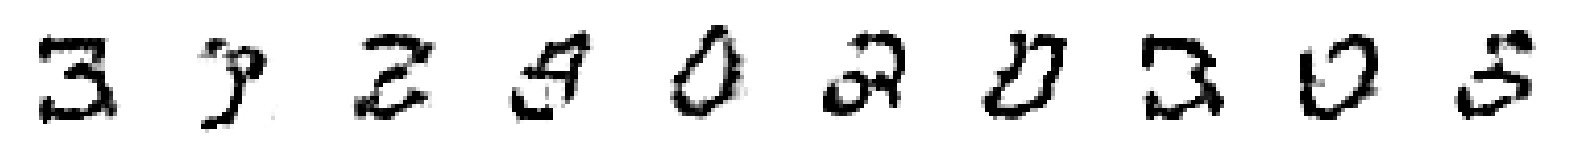


Saved to ./output/example_img_012.png


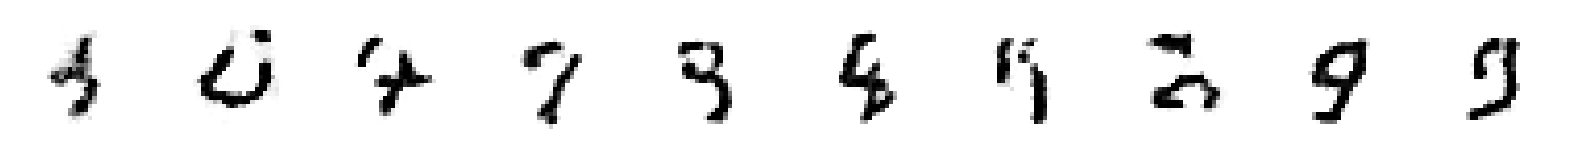

469/469 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step - cdiv: 5.7011e-04 - fake: 8.5484e-04 - loss: 8.0767e-04 - real: 2.8473e-04 - reg: 2.3756e-04 - val_cdiv: -4.8272 - val_fake: -4.7960 - val_real: 0.0311
Epoch 14/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.9961e-04 - fake: -0.0033 - loss: -3.8528e-04 - real: -0.0026 - reg: 3.1433e-04
Saved to ./output/generated_img_013.png


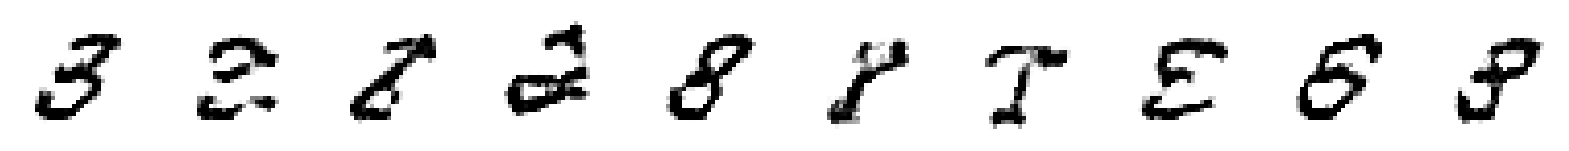


Saved to ./output/example_img_013.png


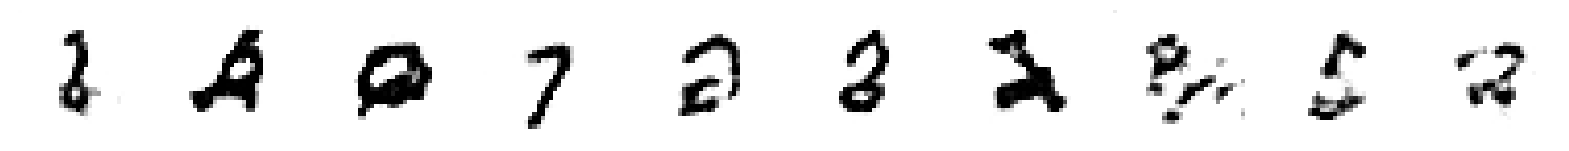

469/469 ━━━━━━━━━━━━━━━━━━━━ 635s 1s/step - cdiv: -4.0485e-04 - fake: -4.0585e-05 - loss: -1.8511e-04 - real: 3.6427e-04 - reg: 2.1974e-04 - val_cdiv: -5.2712 - val_fake: -5.2526 - val_real: 0.0185
Epoch 15/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.3568e-05 - fake: -0.0018 - loss: 3.3614e-04 - real: -0.0018 - reg: 3.6971e-04
Saved to ./output/generated_img_014.png


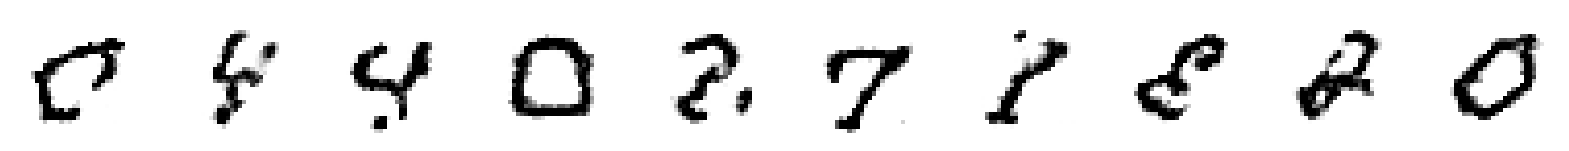


Saved to ./output/example_img_014.png


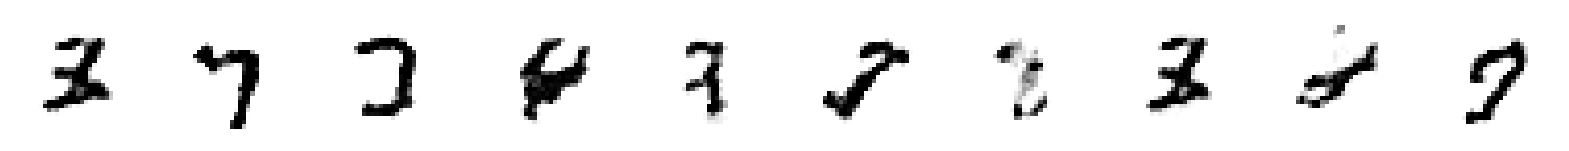

469/469 ━━━━━━━━━━━━━━━━━━━━ 635s 1s/step - cdiv: -1.4754e-05 - fake: 2.7330e-04 - loss: 2.6307e-04 - real: 2.8806e-04 - reg: 2.7782e-04 - val_cdiv: -5.5989 - val_fake: -5.5766 - val_real: 0.0223
Epoch 16/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.4312e-05 - fake: -0.0017 - loss: 2.0898e-04 - real: -0.0016 - reg: 2.7329e-04
Saved to ./output/generated_img_015.png


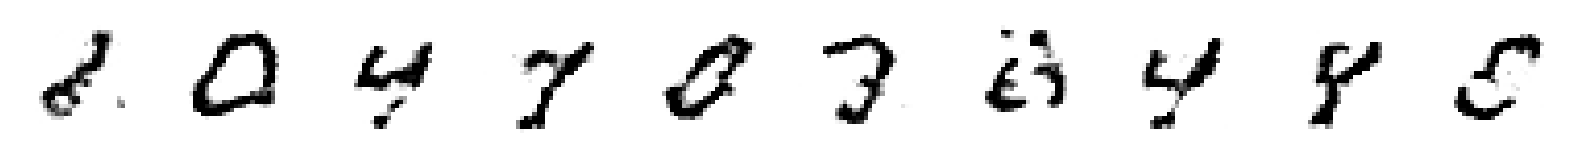


Saved to ./output/example_img_015.png


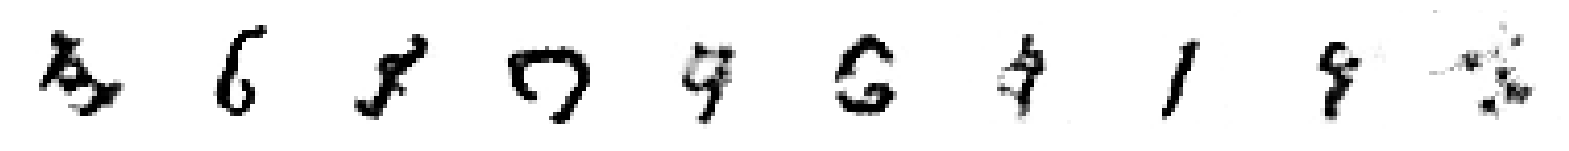

469/469 ━━━━━━━━━━━━━━━━━━━━ 635s 1s/step - cdiv: 5.1760e-05 - fake: 3.2087e-04 - loss: 2.5248e-04 - real: 2.6911e-04 - reg: 2.0072e-04 - val_cdiv: -6.0397 - val_fake: -6.0166 - val_real: 0.0231
Epoch 17/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.2211e-04 - fake: -0.0012 - loss: -4.4811e-05 - real: -8.9199e-04 - reg: 2.7730e-04
Saved to ./output/generated_img_016.png


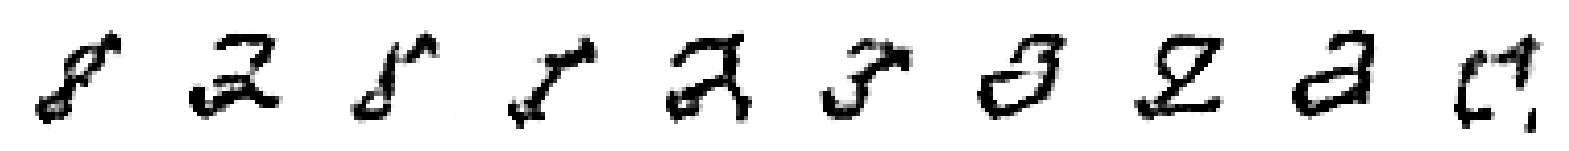


Saved to ./output/example_img_016.png


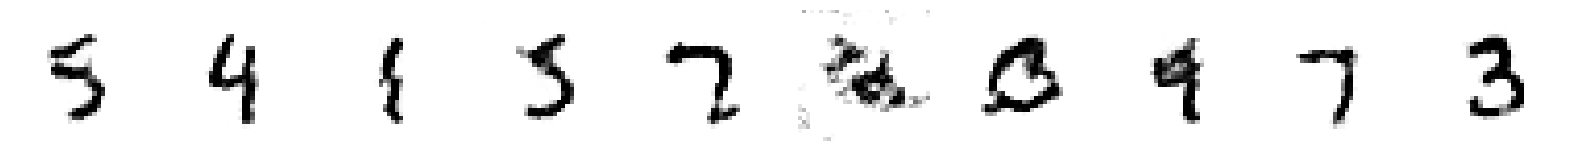

469/469 ━━━━━━━━━━━━━━━━━━━━ 635s 1s/step - cdiv: -5.3186e-05 - fake: 3.9152e-04 - loss: 1.5824e-04 - real: 4.4471e-04 - reg: 2.1143e-04 - val_cdiv: -6.3844 - val_fake: -6.3652 - val_real: 0.0192
Epoch 18/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 4.1291e-05 - fake: -0.0022 - loss: 3.3062e-04 - real: -0.0023 - reg: 2.8933e-04
Saved to ./output/generated_img_017.png


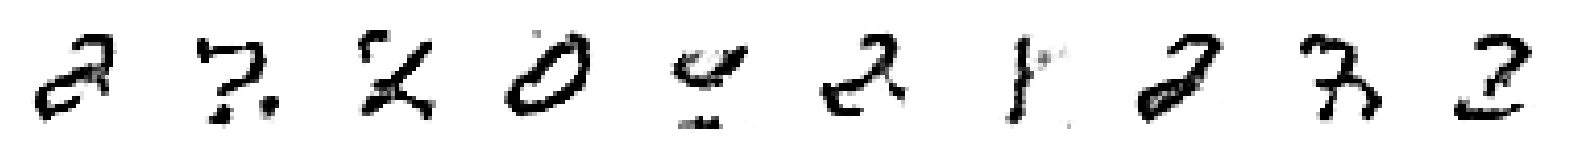


Saved to ./output/example_img_017.png


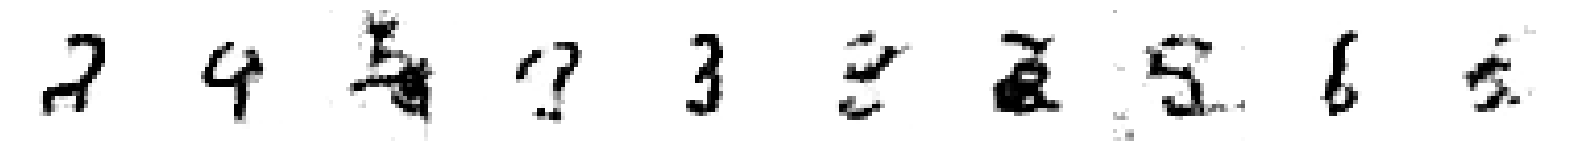

469/469 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step - cdiv: 8.6562e-05 - fake: 1.2510e-05 - loss: 2.9912e-04 - real: -7.4052e-05 - reg: 2.1256e-04 - val_cdiv: -6.7334 - val_fake: -6.7199 - val_real: 0.0136
Epoch 19/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.7316e-04 - fake: -0.0014 - loss: 3.9633e-05 - real: -0.0011 - reg: 3.1279e-04
Saved to ./output/generated_img_018.png


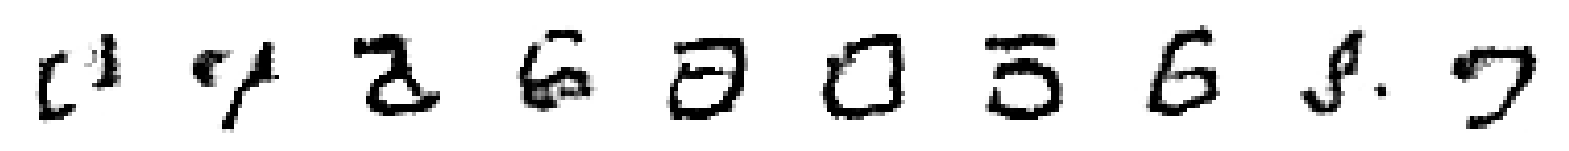


Saved to ./output/example_img_018.png


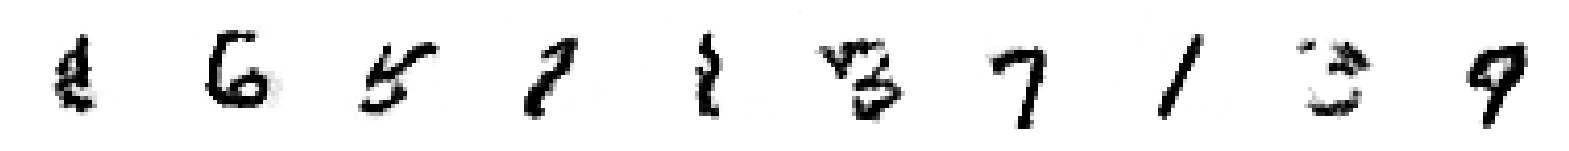

469/469 ━━━━━━━━━━━━━━━━━━━━ 636s 1s/step - cdiv: -4.3499e-05 - fake: 3.6199e-04 - loss: 1.9228e-04 - real: 4.0549e-04 - reg: 2.3578e-04 - val_cdiv: -7.1196 - val_fake: -7.1034 - val_real: 0.0161
Epoch 20/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.0275e-04 - fake: -0.0016 - loss: 5.4017e-05 - real: -0.0014 - reg: 2.5677e-04
Saved to ./output/generated_img_019.png


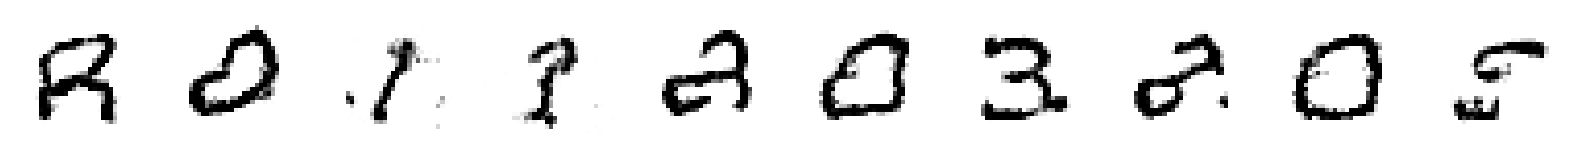


Saved to ./output/example_img_019.png


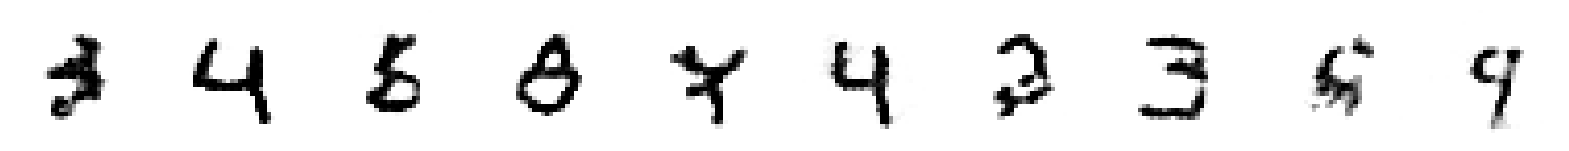

469/469 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step - cdiv: 9.0864e-05 - fake: 4.2810e-04 - loss: 2.9004e-04 - real: 3.3723e-04 - reg: 1.9917e-04 - val_cdiv: -7.3026 - val_fake: -7.2892 - val_real: 0.0134
Epoch 21/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.8143e-05 - fake: -0.0026 - loss: 1.9432e-04 - real: -0.0026 - reg: 2.3246e-04
Saved to ./output/generated_img_020.png


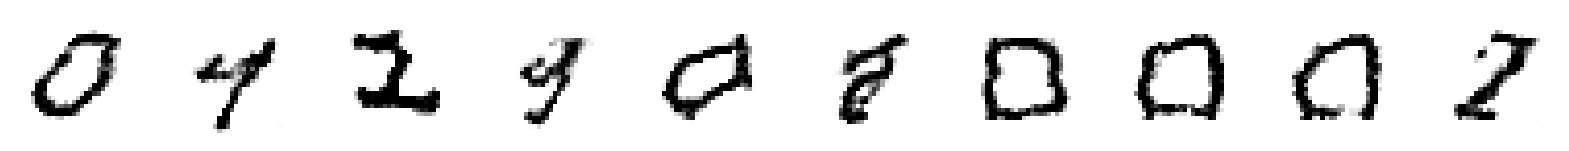


Saved to ./output/example_img_020.png


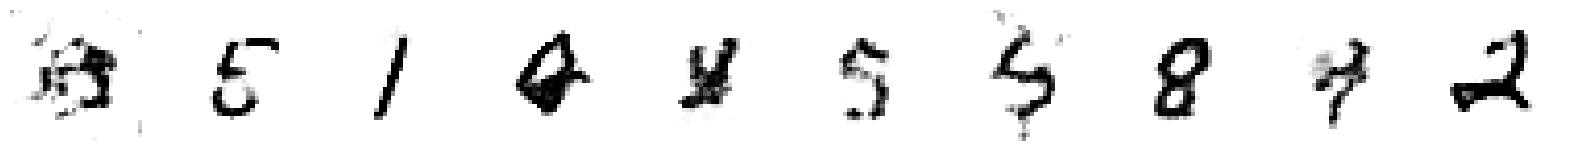

469/469 ━━━━━━━━━━━━━━━━━━━━ 637s 1s/step - cdiv: -1.5114e-05 - fake: -3.1113e-05 - loss: 1.5667e-04 - real: -1.5999e-05 - reg: 1.7178e-04 - val_cdiv: -7.7674 - val_fake: -7.7597 - val_real: 0.0077
Epoch 22/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 2.5926e-05 - fake: -0.0019 - loss: 2.7221e-04 - real: -0.0019 - reg: 2.4628e-04
Saved to ./output/generated_img_021.png


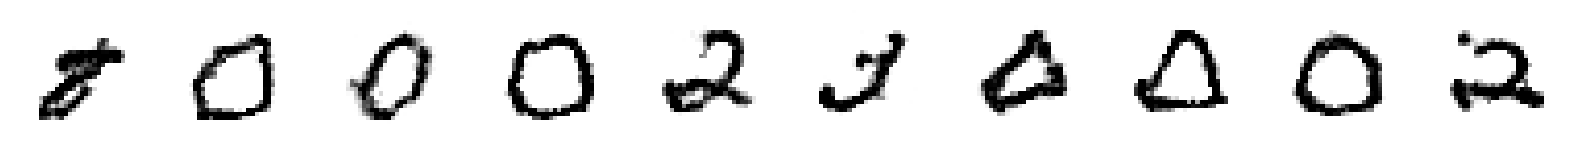


Saved to ./output/example_img_021.png


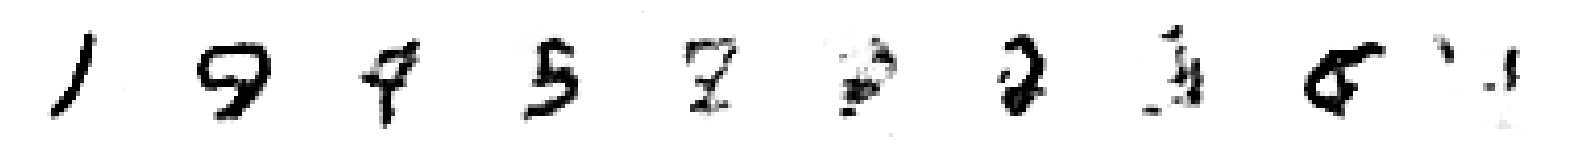

469/469 ━━━━━━━━━━━━━━━━━━━━ 636s 1s/step - cdiv: 1.0773e-04 - fake: 1.9198e-04 - loss: 2.8455e-04 - real: 8.4248e-05 - reg: 1.7681e-04 - val_cdiv: -8.0302 - val_fake: -8.0243 - val_real: 0.0059
Epoch 23/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.6066e-05 - fake: -0.0016 - loss: 1.0608e-04 - real: -0.0016 - reg: 1.7215e-04
Saved to ./output/generated_img_022.png


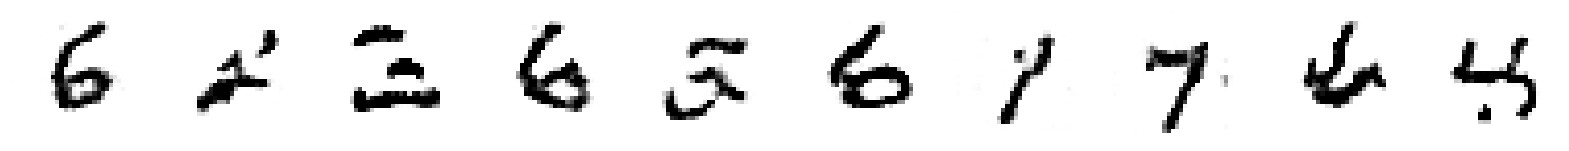


Saved to ./output/example_img_022.png


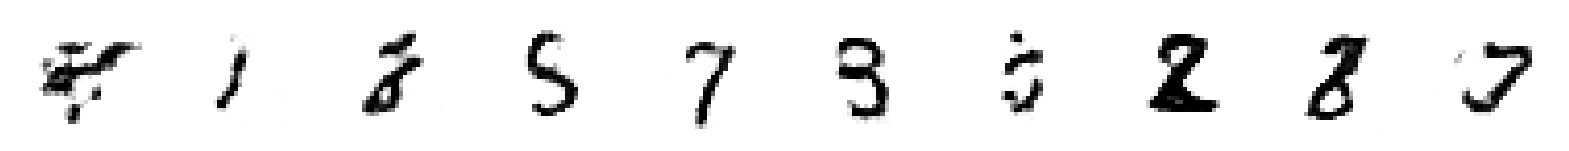

469/469 ━━━━━━━━━━━━━━━━━━━━ 637s 1s/step - cdiv: 3.6286e-05 - fake: -1.2822e-05 - loss: 1.8466e-04 - real: -4.9108e-05 - reg: 1.4837e-04 - val_cdiv: -8.4384 - val_fake: -8.4287 - val_real: 0.0098
Epoch 24/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.3980e-04 - fake: -0.0012 - loss: 7.7941e-05 - real: -0.0011 - reg: 2.1774e-04
Saved to ./output/generated_img_023.png


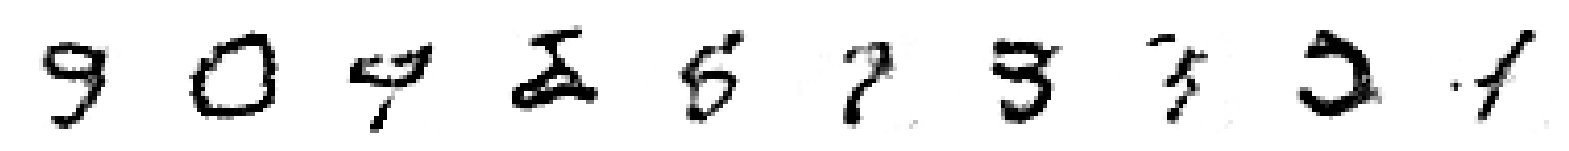


Saved to ./output/example_img_023.png


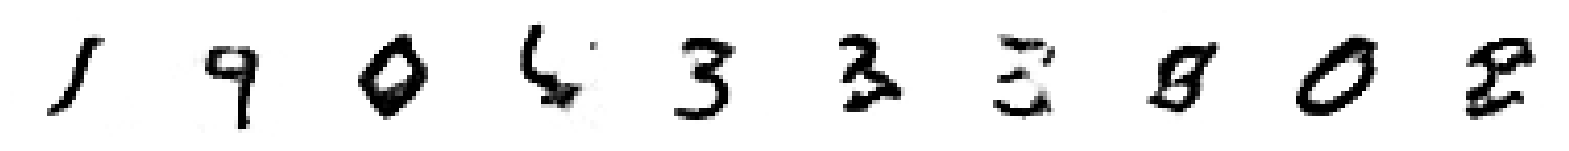

469/469 ━━━━━━━━━━━━━━━━━━━━ 636s 1s/step - cdiv: -4.0864e-05 - fake: 3.7647e-05 - loss: 1.2368e-04 - real: 7.8511e-05 - reg: 1.6455e-04 - val_cdiv: -8.9441 - val_fake: -8.9321 - val_real: 0.0120
Epoch 25/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 1.6449e-04 - fake: -0.0013 - loss: 3.6881e-04 - real: -0.0015 - reg: 2.0432e-04
Saved to ./output/generated_img_024.png


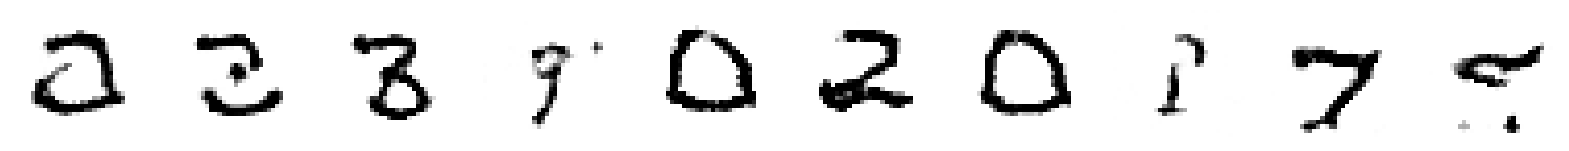


Saved to ./output/example_img_024.png


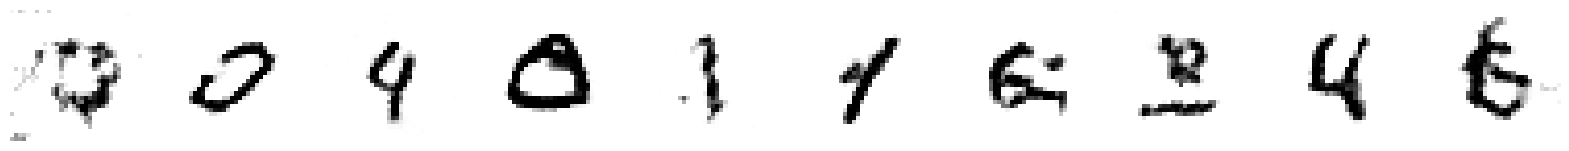

469/469 ━━━━━━━━━━━━━━━━━━━━ 639s 1s/step - cdiv: 1.8045e-04 - fake: 2.1927e-04 - loss: 3.4973e-04 - real: 3.8821e-05 - reg: 1.6928e-04 - val_cdiv: -9.2603 - val_fake: -9.2562 - val_real: 0.0041
Epoch 26/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -9.8278e-05 - fake: -0.0019 - loss: 1.0867e-04 - real: -0.0018 - reg: 2.0694e-04
Saved to ./output/generated_img_025.png


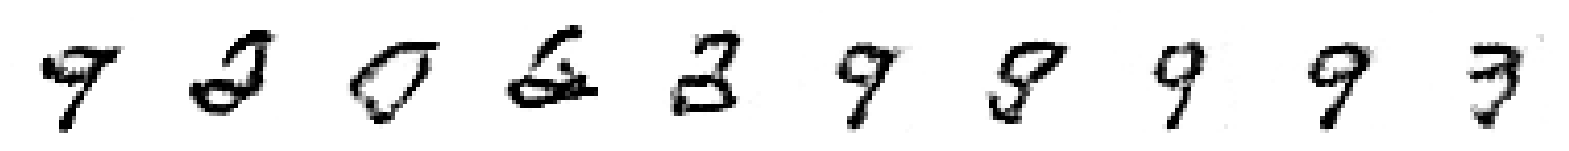


Saved to ./output/example_img_025.png


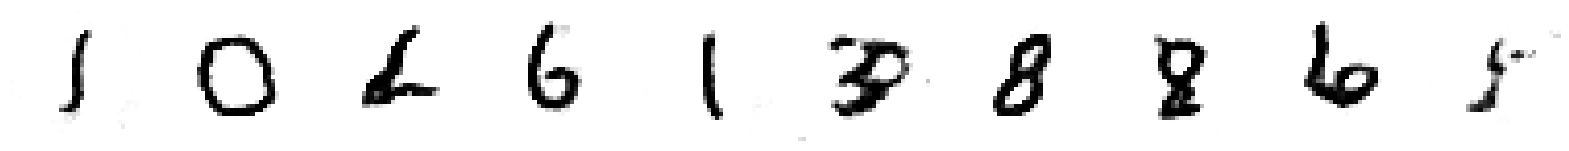

469/469 ━━━━━━━━━━━━━━━━━━━━ 637s 1s/step - cdiv: 3.2959e-04 - fake: -1.9349e-04 - loss: 4.9250e-04 - real: -5.2308e-04 - reg: 1.6292e-04 - val_cdiv: -9.5511 - val_fake: -9.5387 - val_real: 0.0124
Epoch 27/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.9409e-04 - fake: -0.0010 - loss: -2.2777e-04 - real: -6.4359e-04 - reg: 1.6631e-04
Saved to ./output/generated_img_026.png


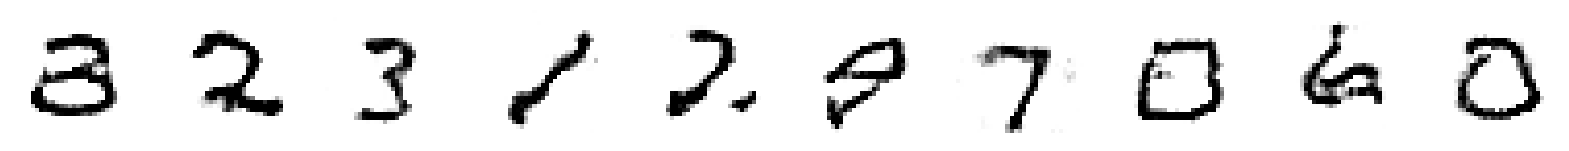


Saved to ./output/example_img_026.png


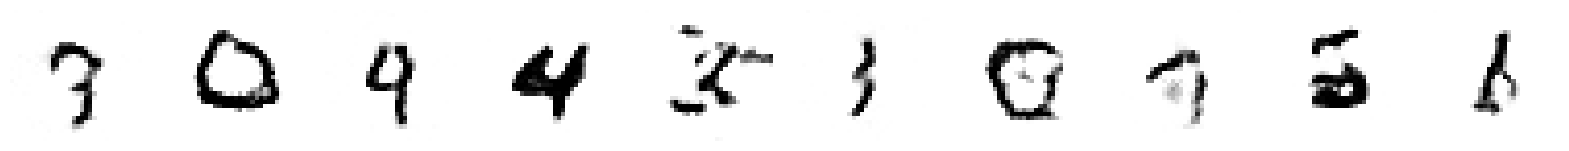

469/469 ━━━━━━━━━━━━━━━━━━━━ 640s 1s/step - cdiv: -4.4709e-05 - fake: 1.2237e-04 - loss: 1.0047e-04 - real: 1.6708e-04 - reg: 1.4518e-04 - val_cdiv: -10.0945 - val_fake: -10.0812 - val_real: 0.0133
Epoch 28/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.7787e-04 - fake: -7.7512e-04 - loss: 2.1826e-05 - real: -5.9725e-04 - reg: 1.9969e-04
Saved to ./output/generated_img_027.png


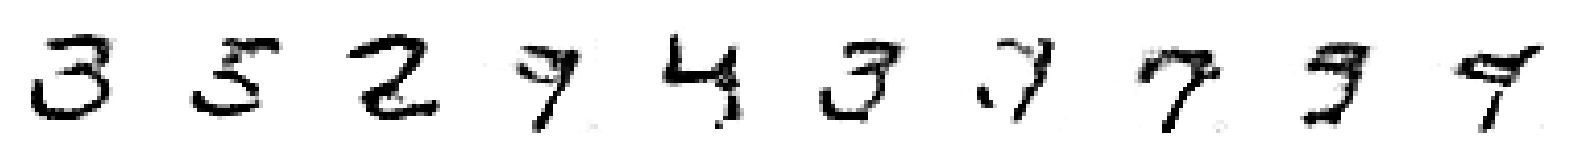


Saved to ./output/example_img_027.png


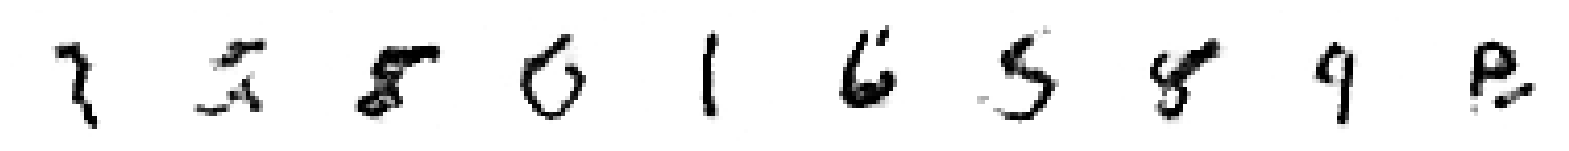

469/469 ━━━━━━━━━━━━━━━━━━━━ 640s 1s/step - cdiv: 3.0147e-04 - fake: 1.1836e-04 - loss: 4.5885e-04 - real: -1.8311e-04 - reg: 1.5738e-04 - val_cdiv: -10.4394 - val_fake: -10.4310 - val_real: 0.0084
Epoch 29/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.2735e-04 - fake: -0.0018 - loss: -5.9529e-05 - real: -0.0015 - reg: 1.6782e-04
Saved to ./output/generated_img_028.png


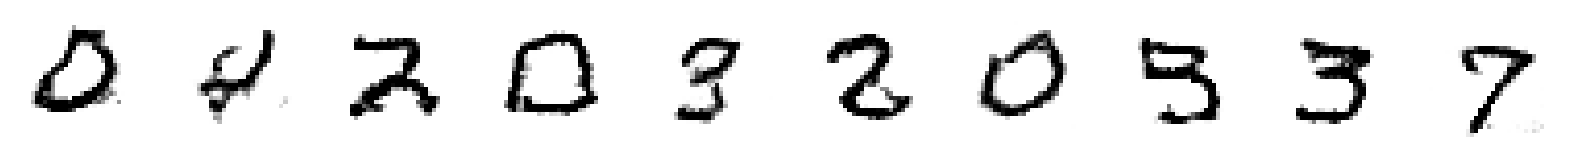


Saved to ./output/example_img_028.png


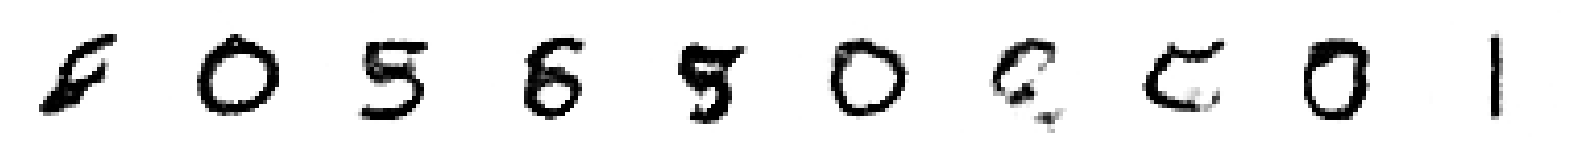

469/469 ━━━━━━━━━━━━━━━━━━━━ 641s 1s/step - cdiv: 7.7062e-05 - fake: 3.9412e-05 - loss: 2.0842e-04 - real: -3.7650e-05 - reg: 1.3136e-04 - val_cdiv: -10.6462 - val_fake: -10.6418 - val_real: 0.0045
Epoch 30/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 1.4344e-04 - fake: -0.0014 - loss: 3.1512e-04 - real: -0.0015 - reg: 1.7168e-04
Saved to ./output/generated_img_029.png


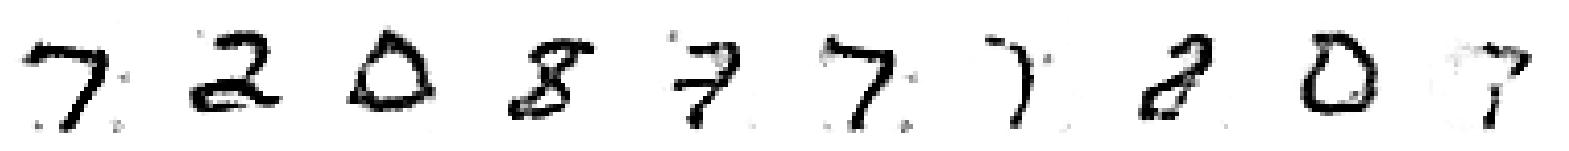


Saved to ./output/example_img_029.png


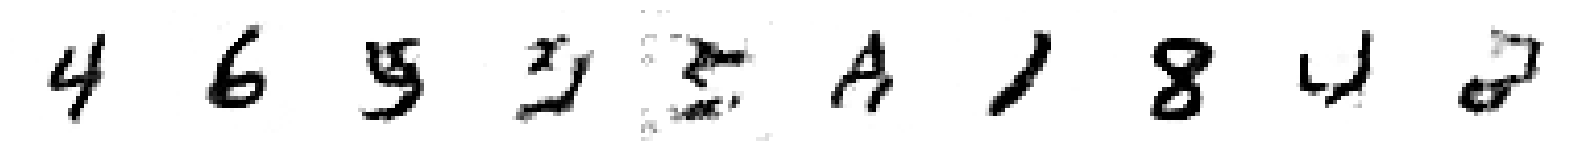

469/469 ━━━━━━━━━━━━━━━━━━━━ 641s 1s/step - cdiv: 2.4863e-04 - fake: 1.5927e-04 - loss: 3.8935e-04 - real: -8.9361e-05 - reg: 1.4073e-04 - val_cdiv: -11.0213 - val_fake: -11.0111 - val_real: 0.0102
Epoch 31/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.3945e-04 - fake: -0.0015 - loss: -7.9967e-05 - real: -0.0012 - reg: 1.5948e-04
Saved to ./output/generated_img_030.png


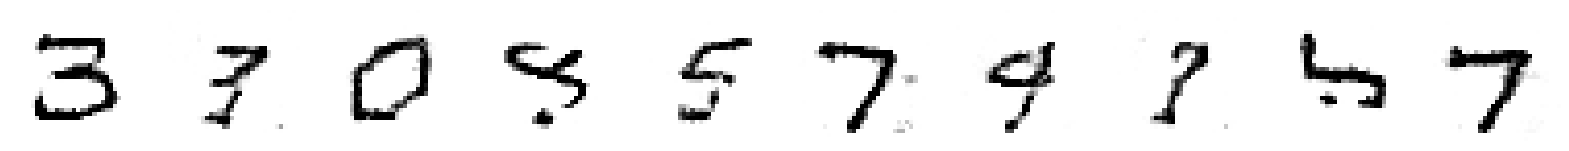


Saved to ./output/example_img_030.png


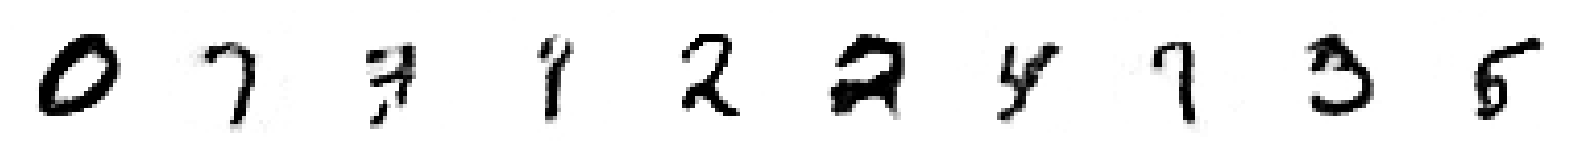

469/469 ━━━━━━━━━━━━━━━━━━━━ 639s 1s/step - cdiv: -6.1133e-06 - fake: 8.4637e-05 - loss: 1.2850e-04 - real: 9.0750e-05 - reg: 1.3462e-04 - val_cdiv: -11.6231 - val_fake: -11.6188 - val_real: 0.0043
Epoch 32/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 1.2880e-04 - fake: -0.0012 - loss: 2.6457e-04 - real: -0.0014 - reg: 1.3577e-04
Saved to ./output/generated_img_031.png


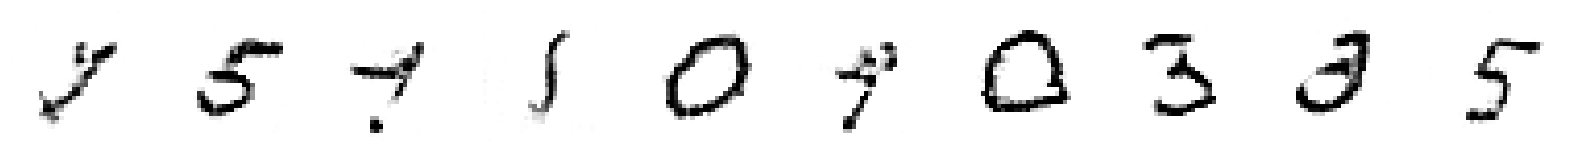


Saved to ./output/example_img_031.png


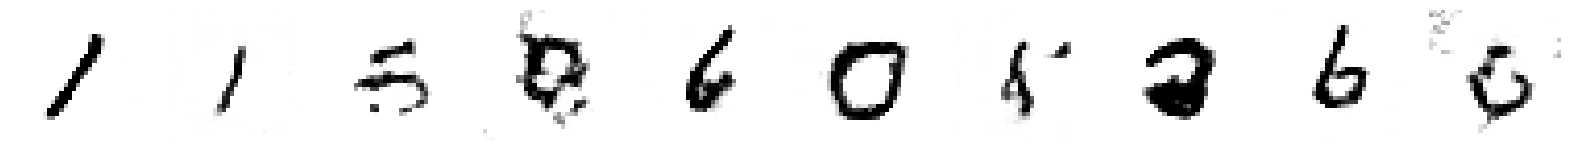

469/469 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - cdiv: 1.2487e-04 - fake: -8.0226e-05 - loss: 2.3649e-04 - real: -2.0510e-04 - reg: 1.1161e-04 - val_cdiv: -11.9303 - val_fake: -11.9251 - val_real: 0.0052
Epoch 33/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.1911e-04 - fake: -0.0011 - loss: 2.5336e-05 - real: -9.6732e-04 - reg: 1.4445e-04
Saved to ./output/generated_img_032.png


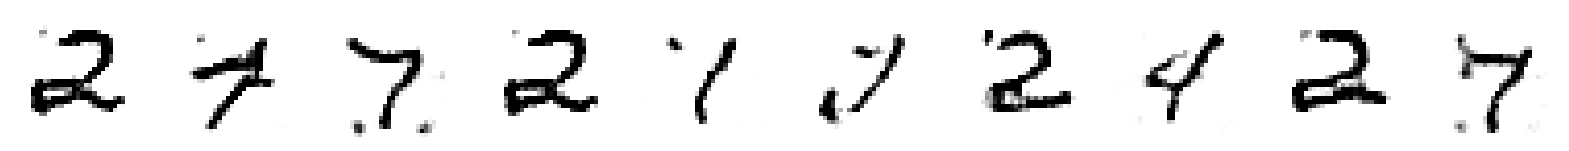


Saved to ./output/example_img_032.png


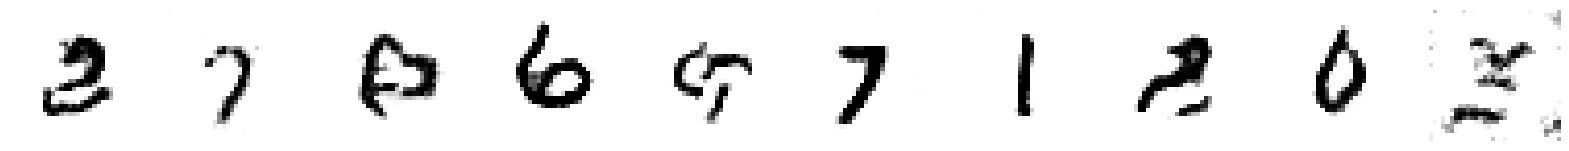

469/469 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - cdiv: 5.5398e-05 - fake: 1.0515e-04 - loss: 1.8670e-04 - real: 4.9754e-05 - reg: 1.3130e-04 - val_cdiv: -12.2737 - val_fake: -12.2660 - val_real: 0.0077
Epoch 34/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 1.2884e-04 - fake: -0.0012 - loss: 2.9036e-04 - real: -0.0013 - reg: 1.6152e-04
Saved to ./output/generated_img_033.png


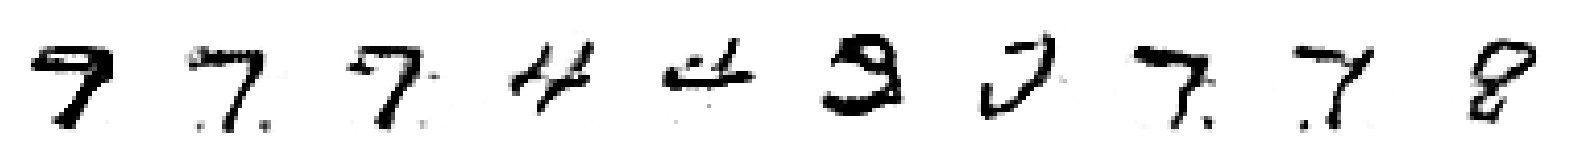


Saved to ./output/example_img_033.png


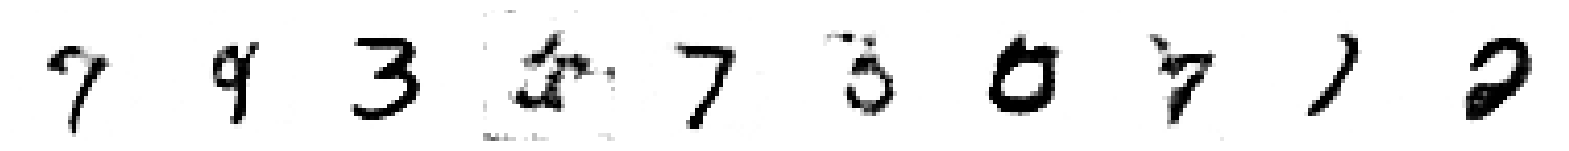

469/469 ━━━━━━━━━━━━━━━━━━━━ 640s 1s/step - cdiv: 4.4742e-05 - fake: -2.3169e-06 - loss: 1.7866e-04 - real: -4.7059e-05 - reg: 1.3392e-04 - val_cdiv: -12.6528 - val_fake: -12.6454 - val_real: 0.0075
Epoch 35/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.4499e-04 - fake: -0.0010 - loss: 5.0868e-05 - real: -8.7800e-04 - reg: 1.9586e-04
Saved to ./output/generated_img_034.png


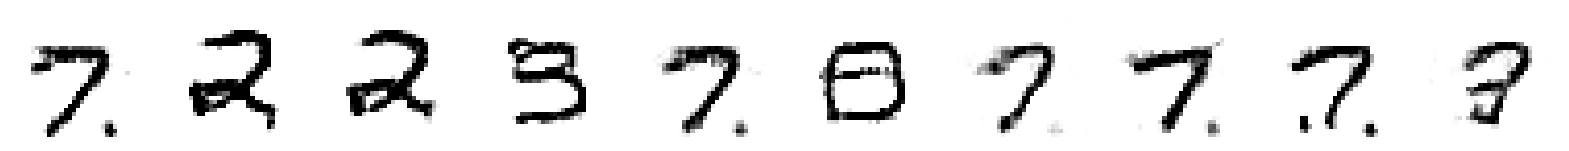


Saved to ./output/example_img_034.png


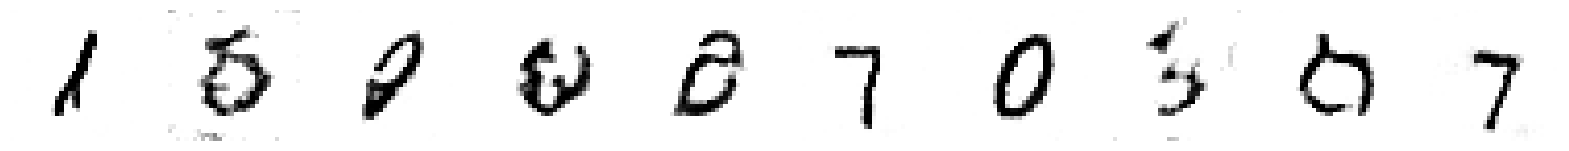

469/469 ━━━━━━━━━━━━━━━━━━━━ 645s 1s/step - cdiv: 1.1784e-04 - fake: -8.5521e-05 - loss: 2.8213e-04 - real: -2.0336e-04 - reg: 1.6429e-04 - val_cdiv: -12.9683 - val_fake: -12.9526 - val_real: 0.0157
Epoch 36/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.6732e-04 - fake: -5.3093e-04 - loss: -1.0143e-04 - real: -2.6361e-04 - reg: 1.6588e-04
Saved to ./output/generated_img_035.png


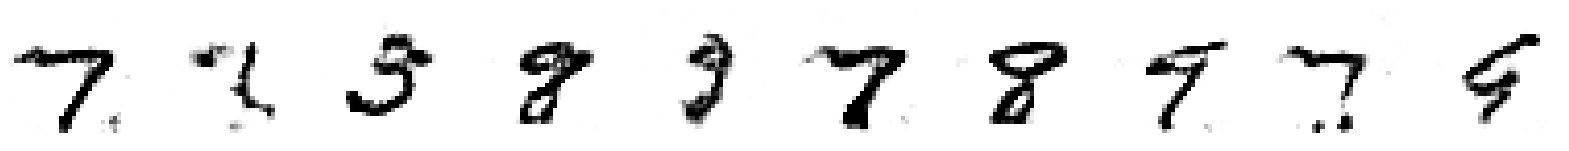


Saved to ./output/example_img_035.png


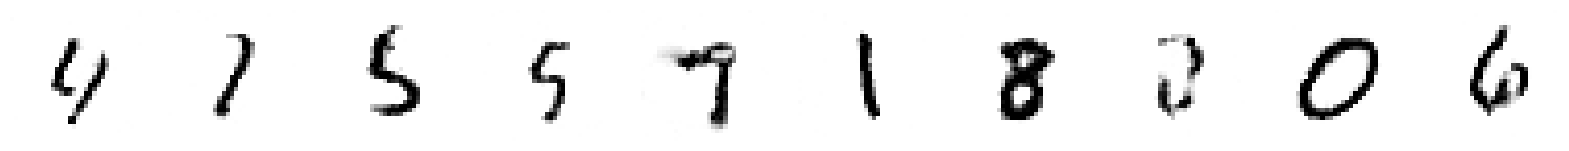

469/469 ━━━━━━━━━━━━━━━━━━━━ 640s 1s/step - cdiv: -9.9367e-07 - fake: 3.5557e-05 - loss: 1.3782e-04 - real: 3.6551e-05 - reg: 1.3882e-04 - val_cdiv: -13.6506 - val_fake: -13.6416 - val_real: 0.0090
Epoch 37/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 3.5285e-04 - fake: -7.3697e-04 - loss: 4.9705e-04 - real: -0.0011 - reg: 1.4420e-04
Saved to ./output/generated_img_036.png


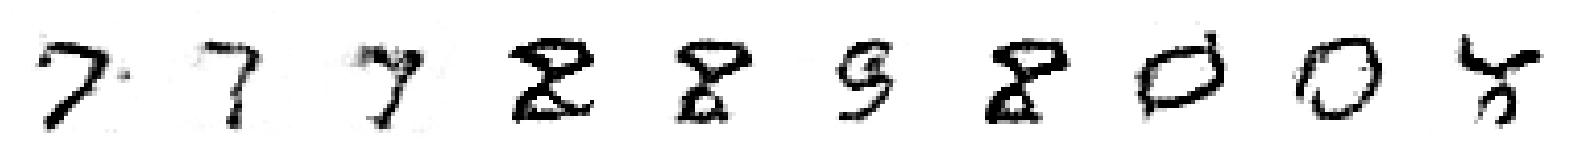


Saved to ./output/example_img_036.png


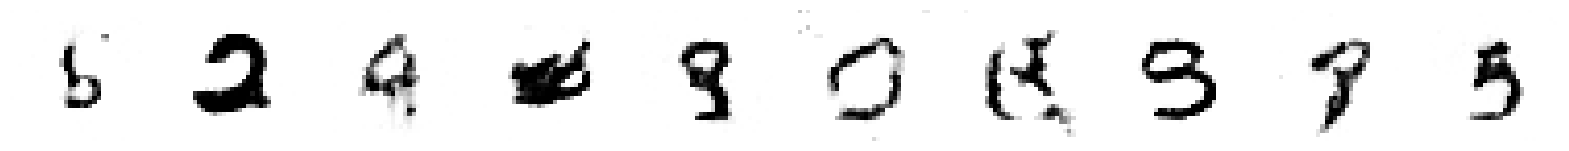

469/469 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - cdiv: 2.9044e-04 - fake: 9.3261e-06 - loss: 4.1023e-04 - real: -2.8111e-04 - reg: 1.1980e-04 - val_cdiv: -14.1218 - val_fake: -14.1131 - val_real: 0.0087
Epoch 38/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -8.9206e-05 - fake: -8.7086e-04 - loss: 6.7872e-05 - real: -7.8166e-04 - reg: 1.5708e-04
Saved to ./output/generated_img_037.png


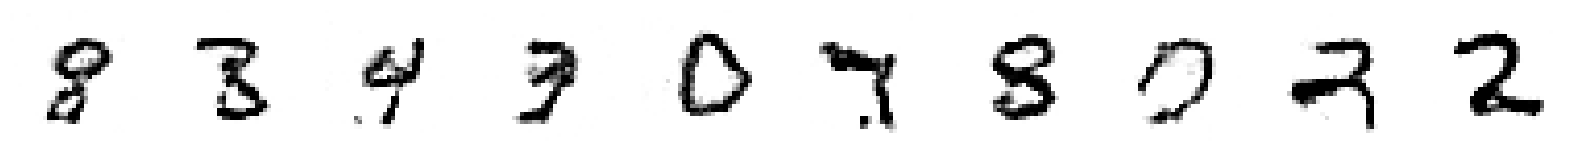


Saved to ./output/example_img_037.png


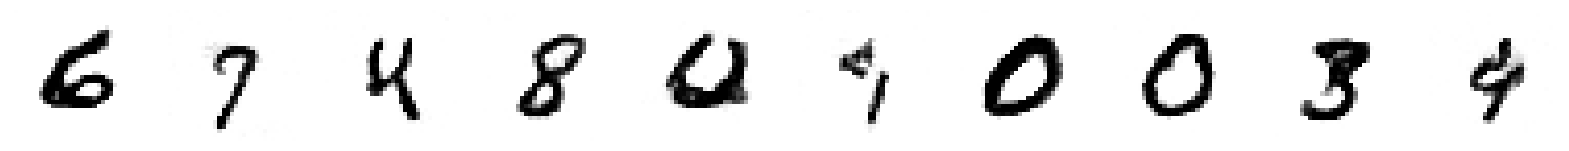

469/469 ━━━━━━━━━━━━━━━━━━━━ 643s 1s/step - cdiv: 8.2568e-05 - fake: -1.2902e-04 - loss: 2.1921e-04 - real: -2.1159e-04 - reg: 1.3664e-04 - val_cdiv: -14.3607 - val_fake: -14.3533 - val_real: 0.0075
Epoch 39/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.3458e-04 - fake: -6.3747e-05 - loss: -7.6834e-05 - real: 1.7083e-04 - reg: 1.5774e-04
Saved to ./output/generated_img_038.png


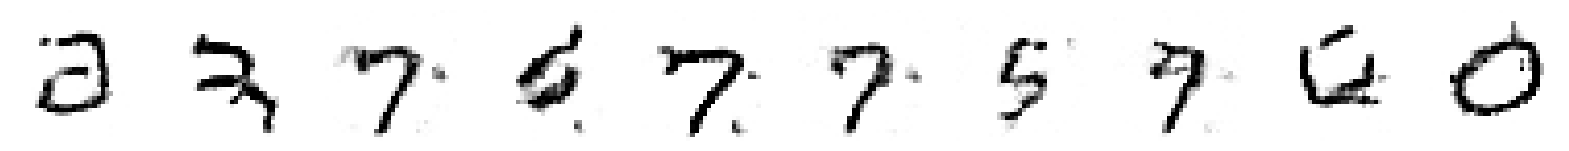


Saved to ./output/example_img_038.png


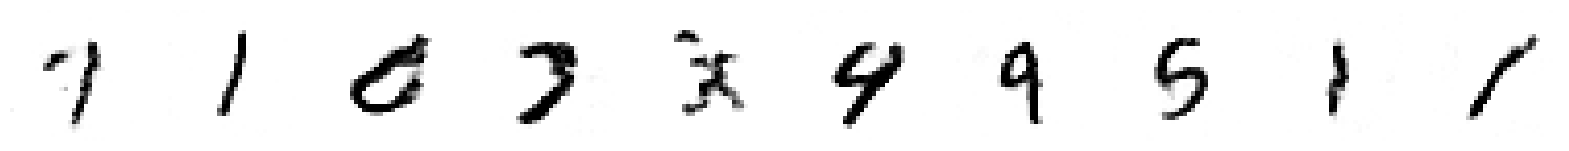

469/469 ━━━━━━━━━━━━━━━━━━━━ 643s 1s/step - cdiv: 1.0413e-04 - fake: 2.1265e-04 - loss: 2.4383e-04 - real: 1.0852e-04 - reg: 1.3970e-04 - val_cdiv: -14.8510 - val_fake: -14.8469 - val_real: 0.0041
Epoch 40/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 5.1093e-06 - fake: -0.0010 - loss: 1.4587e-04 - real: -0.0010 - reg: 1.4076e-04
Saved to ./output/generated_img_039.png


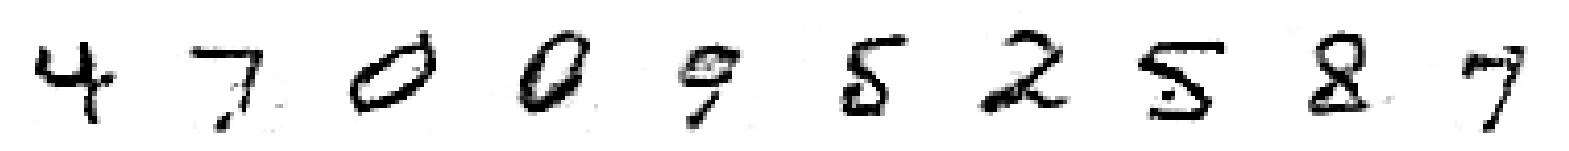


Saved to ./output/example_img_039.png


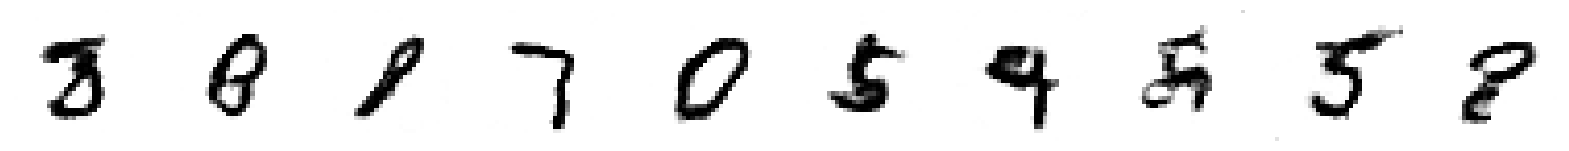

469/469 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - cdiv: 7.3171e-05 - fake: -1.9573e-04 - loss: 1.9952e-04 - real: -2.6890e-04 - reg: 1.2635e-04 - val_cdiv: -15.0826 - val_fake: -15.0818 - val_real: 7.5966e-04
Epoch 41/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 8.8044e-05 - fake: -7.8975e-04 - loss: 2.0466e-04 - real: -8.7779e-04 - reg: 1.1662e-04
Saved to ./output/generated_img_040.png


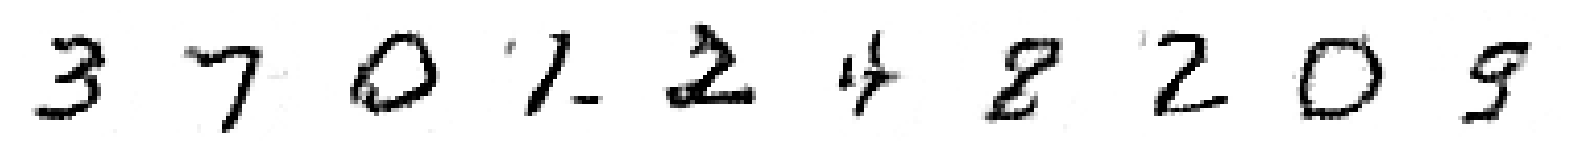


Saved to ./output/example_img_040.png


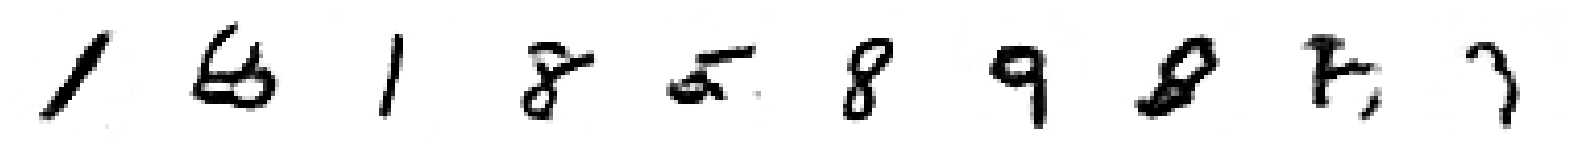

469/469 ━━━━━━━━━━━━━━━━━━━━ 648s 1s/step - cdiv: 9.8587e-05 - fake: 1.8004e-04 - loss: 2.0801e-04 - real: 8.1452e-05 - reg: 1.0942e-04 - val_cdiv: -15.4675 - val_fake: -15.4627 - val_real: 0.0048
Epoch 42/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.1133e-04 - fake: -9.5807e-04 - loss: -1.7587e-04 - real: -6.4673e-04 - reg: 1.3546e-04
Saved to ./output/generated_img_041.png


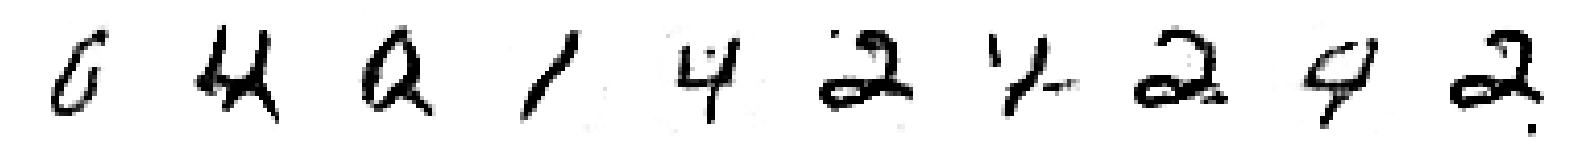


Saved to ./output/example_img_041.png


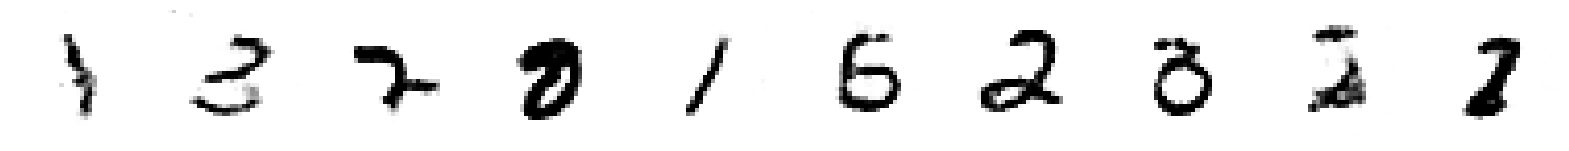

469/469 ━━━━━━━━━━━━━━━━━━━━ 643s 1s/step - cdiv: -5.9048e-05 - fake: -1.7538e-04 - loss: 5.7523e-05 - real: -1.1634e-04 - reg: 1.1657e-04 - val_cdiv: -15.9280 - val_fake: -15.9251 - val_real: 0.0029
Epoch 43/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 1.0950e-04 - fake: -1.8873e-04 - loss: 2.5292e-04 - real: -2.9823e-04 - reg: 1.4342e-04
Saved to ./output/generated_img_042.png


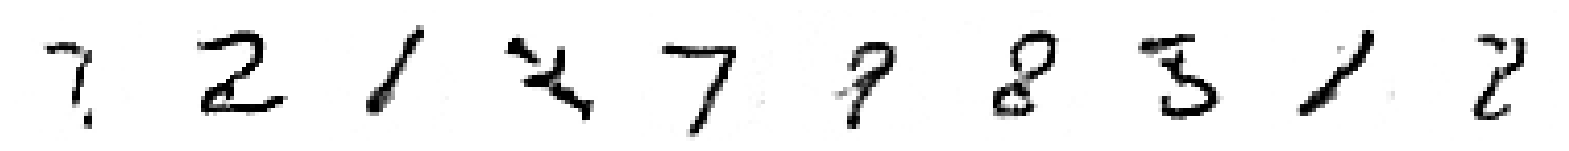


Saved to ./output/example_img_042.png


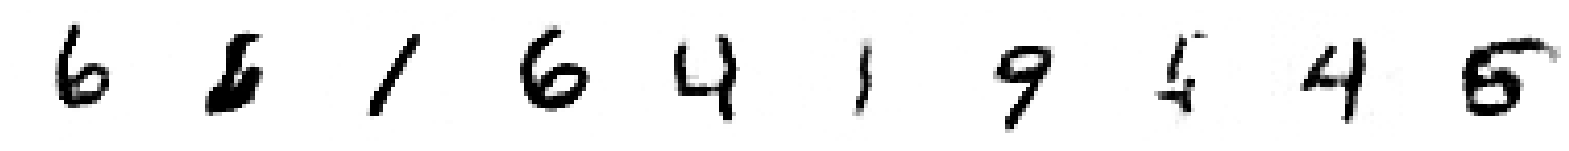

469/469 ━━━━━━━━━━━━━━━━━━━━ 644s 1s/step - cdiv: 3.2828e-04 - fake: 6.5043e-05 - loss: 4.5063e-04 - real: -2.6323e-04 - reg: 1.2235e-04 - val_cdiv: -16.4611 - val_fake: -16.4563 - val_real: 0.0048
Epoch 44/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.2497e-04 - fake: -3.8644e-04 - loss: -1.1866e-04 - real: -1.6147e-04 - reg: 1.0631e-04
Saved to ./output/generated_img_043.png


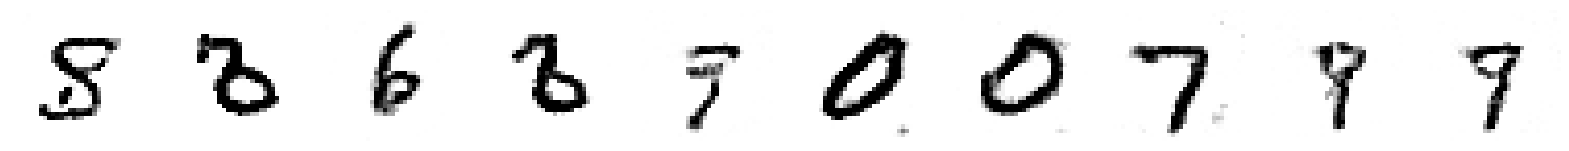


Saved to ./output/example_img_043.png


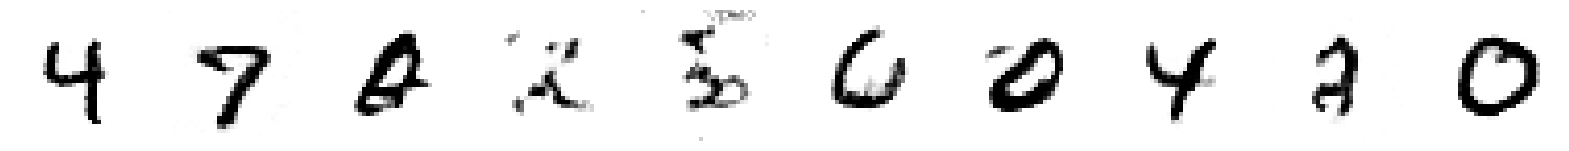

469/469 ━━━━━━━━━━━━━━━━━━━━ 647s 1s/step - cdiv: -1.0205e-04 - fake: 1.9537e-04 - loss: -7.7705e-06 - real: 2.9742e-04 - reg: 9.4281e-05 - val_cdiv: -16.9937 - val_fake: -16.9914 - val_real: 0.0023
Epoch 45/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.4673e-04 - fake: -5.7870e-04 - loss: 6.1995e-06 - real: -4.3197e-04 - reg: 1.5293e-04
Saved to ./output/generated_img_044.png


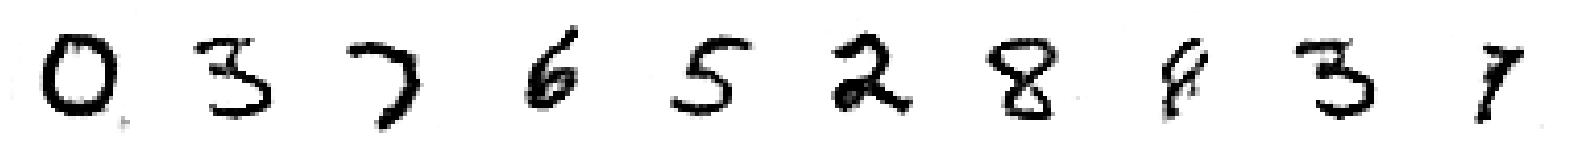


Saved to ./output/example_img_044.png


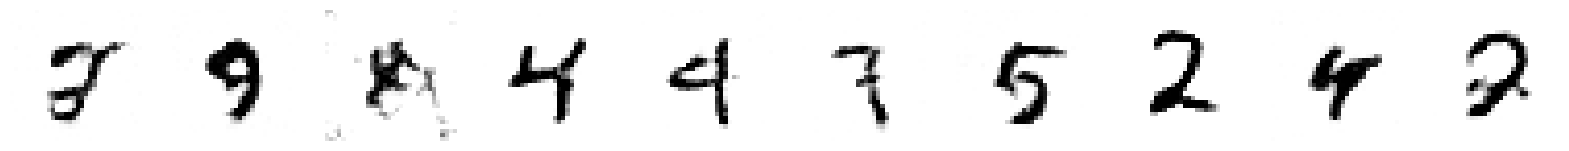

469/469 ━━━━━━━━━━━━━━━━━━━━ 646s 1s/step - cdiv: 5.9196e-06 - fake: -7.8618e-05 - loss: 1.4785e-04 - real: -8.4537e-05 - reg: 1.4193e-04 - val_cdiv: -16.9380 - val_fake: -16.9464 - val_real: -0.0084
Epoch 46/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.5484e-04 - fake: -7.4711e-04 - loss: -2.3164e-04 - real: -3.9227e-04 - reg: 1.2320e-04
Saved to ./output/generated_img_045.png


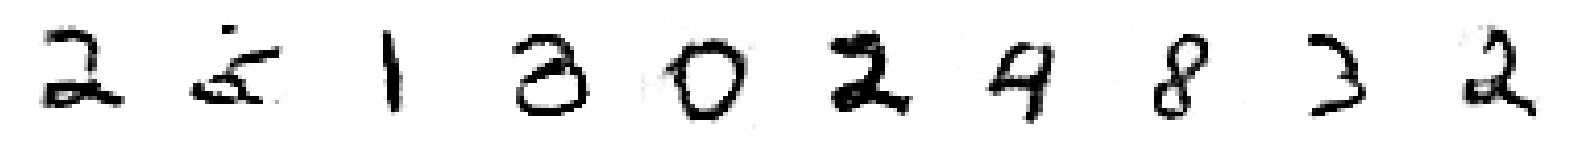


Saved to ./output/example_img_045.png


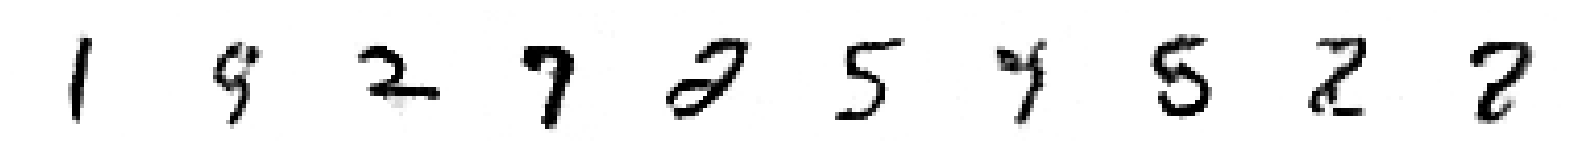

469/469 ━━━━━━━━━━━━━━━━━━━━ 647s 1s/step - cdiv: 2.9068e-05 - fake: -6.4989e-05 - loss: 1.4499e-04 - real: -9.4057e-05 - reg: 1.1592e-04 - val_cdiv: -17.8347 - val_fake: -17.8399 - val_real: -0.0052
Epoch 47/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 1.3476e-04 - fake: -5.9968e-04 - loss: 2.4543e-04 - real: -7.3444e-04 - reg: 1.1067e-04
Saved to ./output/generated_img_046.png


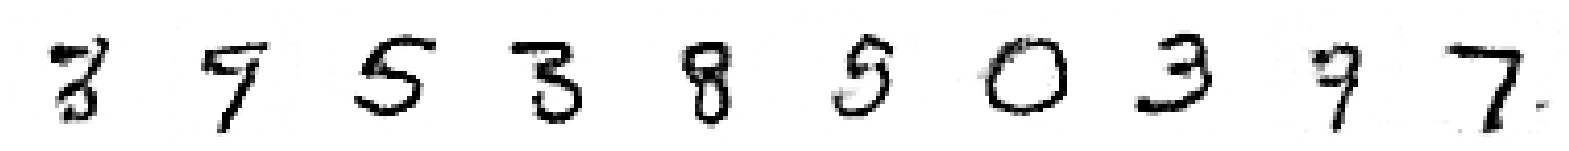


Saved to ./output/example_img_046.png


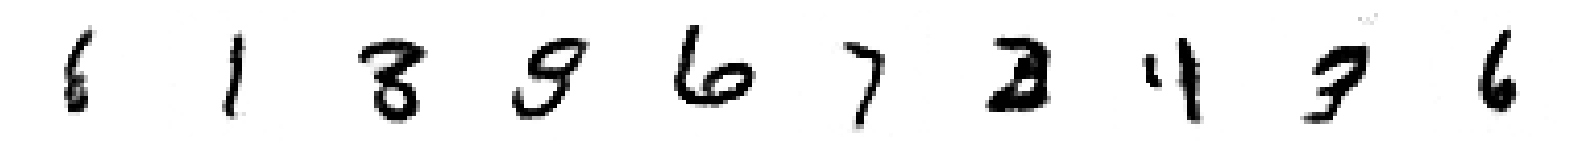

469/469 ━━━━━━━━━━━━━━━━━━━━ 647s 1s/step - cdiv: 1.9977e-04 - fake: 1.3056e-04 - loss: 3.0307e-04 - real: -6.9209e-05 - reg: 1.0330e-04 - val_cdiv: -18.0710 - val_fake: -18.0697 - val_real: 0.0012
Epoch 48/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.4289e-04 - fake: -0.0010 - loss: -2.0801e-04 - real: -6.6482e-04 - reg: 1.3487e-04
Saved to ./output/generated_img_047.png


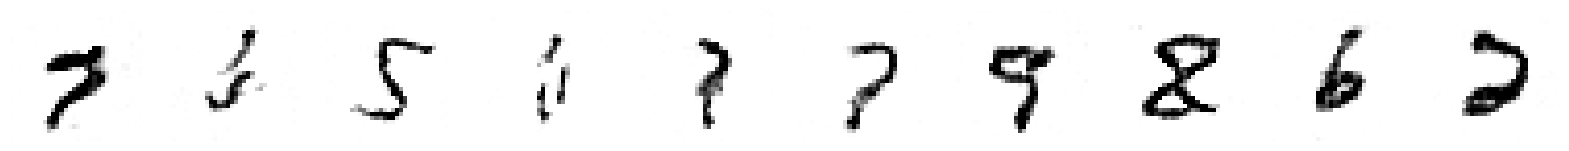


Saved to ./output/example_img_047.png


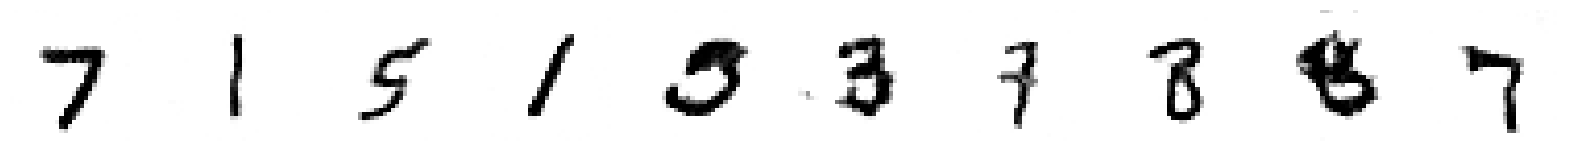

469/469 ━━━━━━━━━━━━━━━━━━━━ 646s 1s/step - cdiv: 1.4188e-04 - fake: 8.7383e-05 - loss: 2.5755e-04 - real: -5.4501e-05 - reg: 1.1566e-04 - val_cdiv: -18.7338 - val_fake: -18.7308 - val_real: 0.0030
Epoch 49/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.0607e-04 - fake: -0.0011 - loss: -8.0231e-05 - real: -8.4979e-04 - reg: 1.2584e-04
Saved to ./output/generated_img_048.png


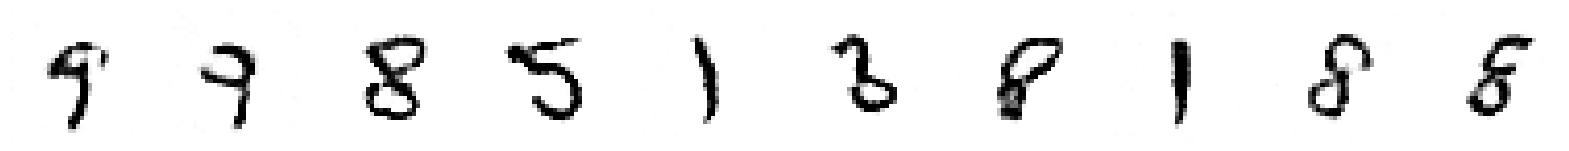


Saved to ./output/example_img_048.png


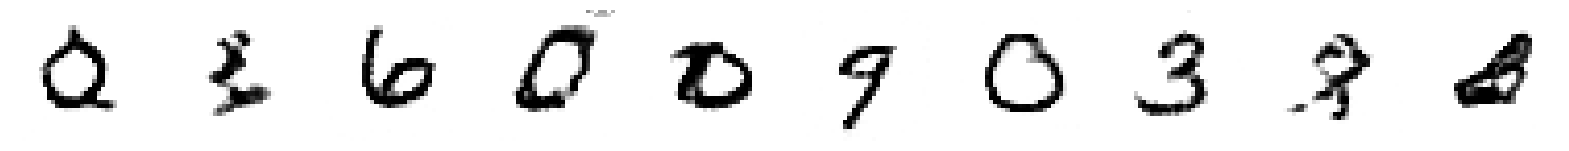

469/469 ━━━━━━━━━━━━━━━━━━━━ 647s 1s/step - cdiv: 6.4648e-05 - fake: 1.0574e-06 - loss: 1.8109e-04 - real: -6.3590e-05 - reg: 1.1645e-04 - val_cdiv: -18.0055 - val_fake: -18.0121 - val_real: -0.0066
Epoch 50/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -5.4857e-04 - fake: -9.0909e-04 - loss: -3.8534e-04 - real: -3.6052e-04 - reg: 1.6323e-04
Saved to ./output/generated_img_049.png


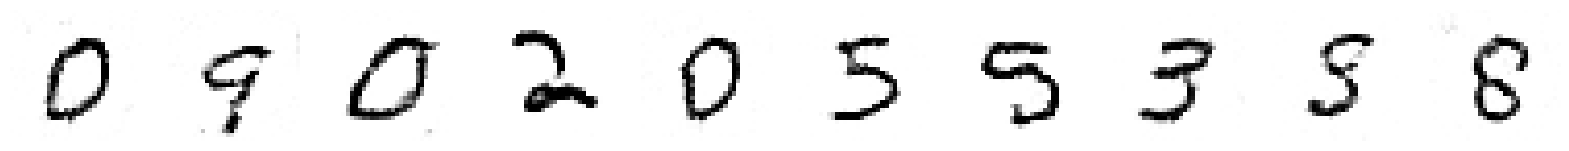


Saved to ./output/example_img_049.png


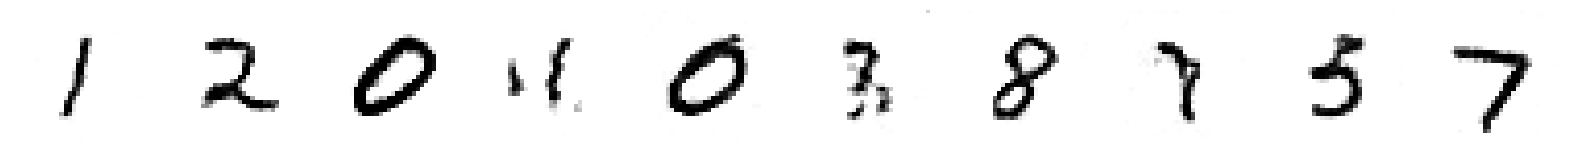

469/469 ━━━━━━━━━━━━━━━━━━━━ 650s 1s/step - cdiv: -1.5387e-05 - fake: 5.5269e-05 - loss: 1.3060e-04 - real: 7.0656e-05 - reg: 1.4598e-04 - val_cdiv: -18.5143 - val_fake: -18.5079 - val_real: 0.0063
Epoch 51/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.7237e-04 - fake: -6.4120e-04 - loss: -1.2514e-04 - real: -3.6884e-04 - reg: 1.4723e-04
Saved to ./output/generated_img_050.png


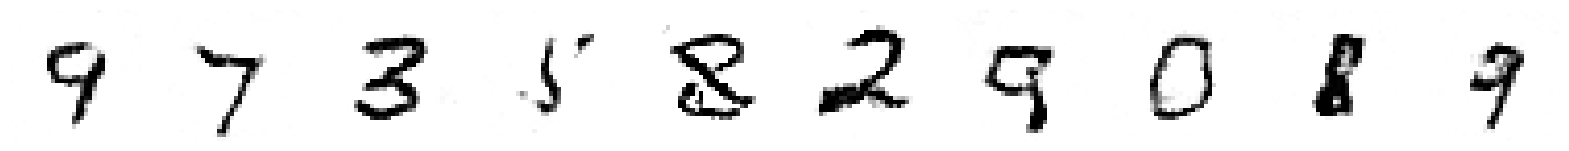


Saved to ./output/example_img_050.png


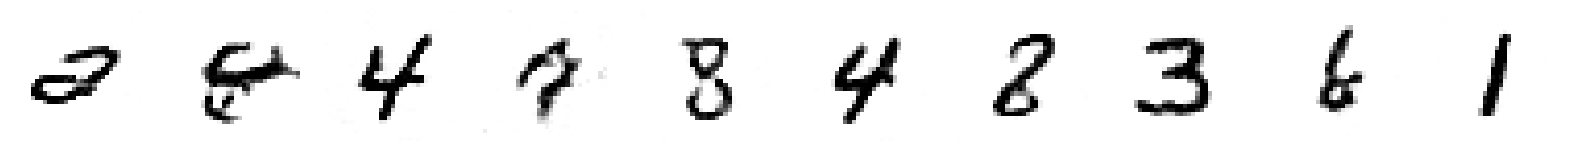

469/469 ━━━━━━━━━━━━━━━━━━━━ 650s 1s/step - cdiv: 1.4628e-04 - fake: -5.1007e-05 - loss: 2.8346e-04 - real: -1.9729e-04 - reg: 1.3718e-04 - val_cdiv: -19.0820 - val_fake: -19.0762 - val_real: 0.0058
Epoch 52/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.4357e-04 - fake: -8.1265e-04 - loss: -2.0847e-04 - real: -4.6908e-04 - reg: 1.3510e-04
Saved to ./output/generated_img_051.png


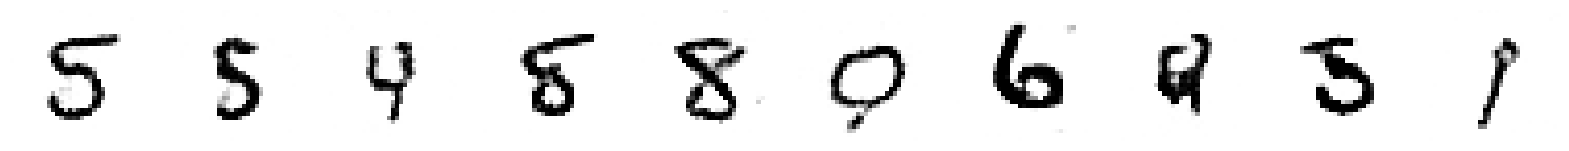


Saved to ./output/example_img_051.png


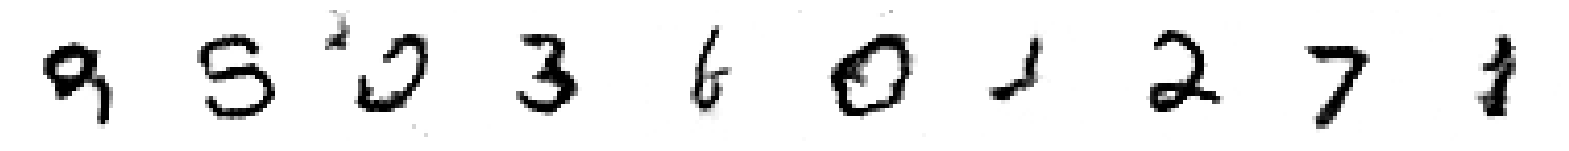

469/469 ━━━━━━━━━━━━━━━━━━━━ 650s 1s/step - cdiv: 4.7848e-06 - fake: -5.2180e-06 - loss: 1.2695e-04 - real: -1.0003e-05 - reg: 1.2217e-04 - val_cdiv: -18.6324 - val_fake: -18.6417 - val_real: -0.0093
Epoch 53/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.5525e-04 - fake: -8.6456e-04 - loss: -1.9629e-04 - real: -5.0931e-04 - reg: 1.5896e-04
Saved to ./output/generated_img_052.png


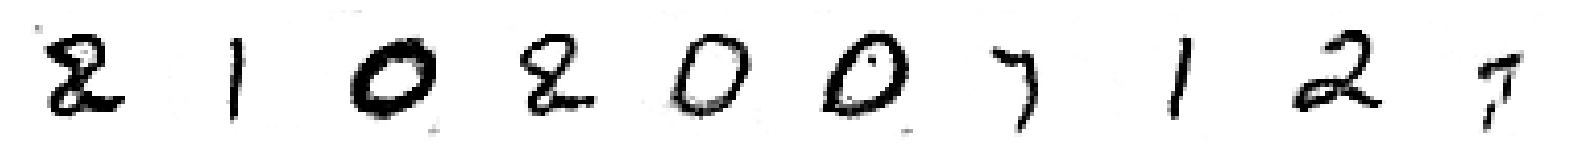


Saved to ./output/example_img_052.png


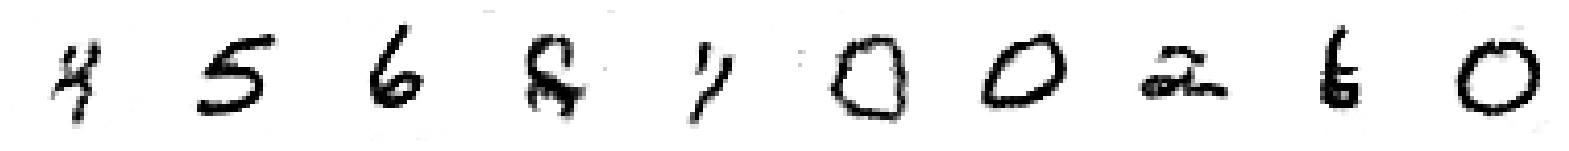

469/469 ━━━━━━━━━━━━━━━━━━━━ 651s 1s/step - cdiv: 1.1713e-04 - fake: 1.2534e-04 - loss: 2.5427e-04 - real: 8.2074e-06 - reg: 1.3714e-04 - val_cdiv: -19.2001 - val_fake: -19.1982 - val_real: 0.0018
Epoch 54/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -4.3367e-04 - fake: -5.3236e-04 - loss: -2.7489e-04 - real: -9.8683e-05 - reg: 1.5878e-04
Saved to ./output/generated_img_053.png


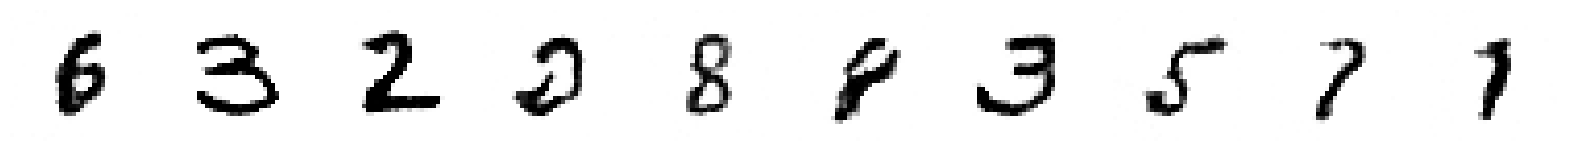


Saved to ./output/example_img_053.png


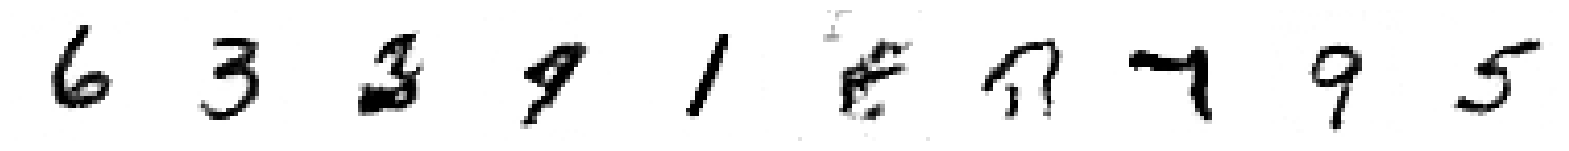

469/469 ━━━━━━━━━━━━━━━━━━━━ 652s 1s/step - cdiv: -1.4562e-04 - fake: 1.9018e-05 - loss: 2.5277e-05 - real: 1.6464e-04 - reg: 1.7090e-04 - val_cdiv: -19.1885 - val_fake: -19.1875 - val_real: 0.0010
Epoch 55/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.3398e-04 - fake: -7.4876e-04 - loss: 2.8469e-05 - real: -6.1478e-04 - reg: 1.6245e-04
Saved to ./output/generated_img_054.png


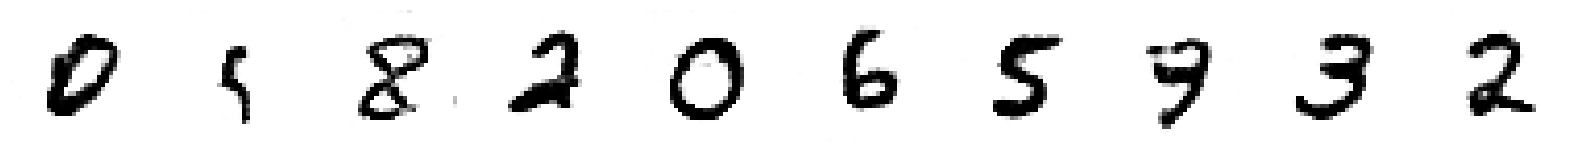


Saved to ./output/example_img_054.png


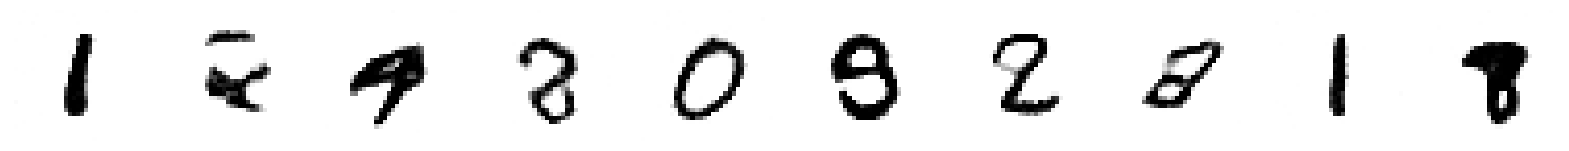

469/469 ━━━━━━━━━━━━━━━━━━━━ 652s 1s/step - cdiv: 2.2741e-04 - fake: -1.9988e-04 - loss: 3.5257e-04 - real: -4.2729e-04 - reg: 1.2516e-04 - val_cdiv: -19.1088 - val_fake: -19.1101 - val_real: -0.0013
Epoch 56/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.6547e-04 - fake: 2.5959e-04 - loss: -2.9256e-05 - real: 4.2506e-04 - reg: 1.3621e-04
Saved to ./output/generated_img_055.png


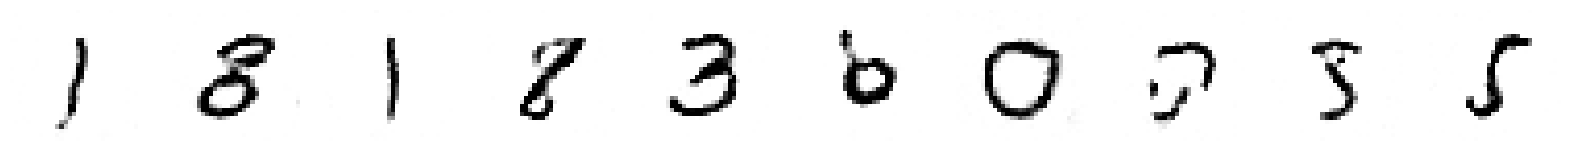


Saved to ./output/example_img_055.png


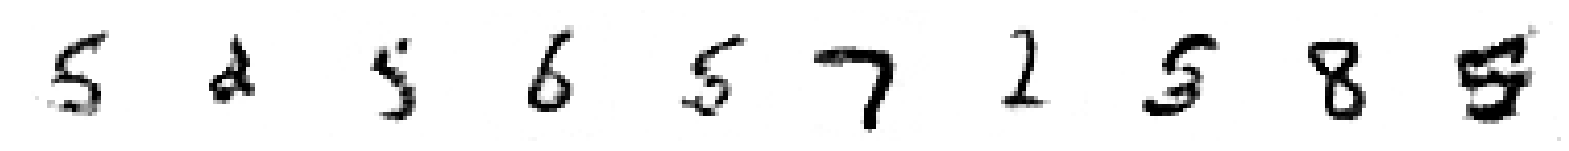

469/469 ━━━━━━━━━━━━━━━━━━━━ 654s 1s/step - cdiv: 5.2725e-05 - fake: 2.9835e-04 - loss: 1.8564e-04 - real: 2.4562e-04 - reg: 1.3291e-04 - val_cdiv: -19.4668 - val_fake: -19.4620 - val_real: 0.0048
Epoch 57/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -4.4869e-04 - fake: -6.4226e-04 - loss: -3.1535e-04 - real: -1.9357e-04 - reg: 1.3334e-04
Saved to ./output/generated_img_056.png


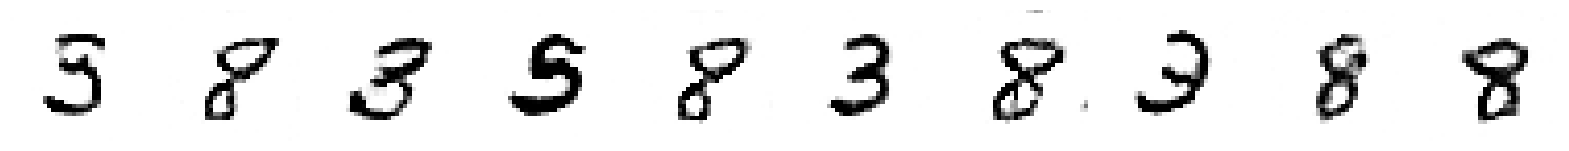


Saved to ./output/example_img_056.png


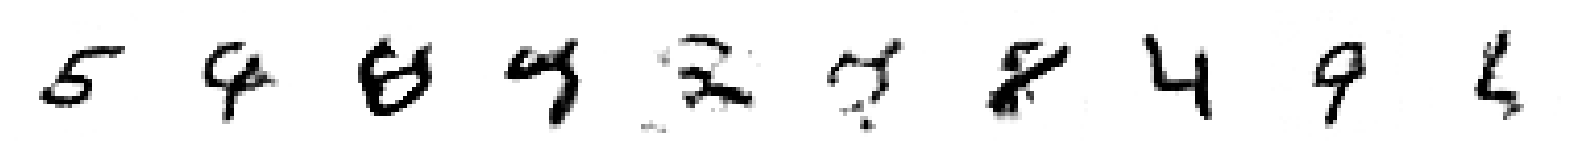

469/469 ━━━━━━━━━━━━━━━━━━━━ 656s 1s/step - cdiv: -2.1110e-04 - fake: 7.9547e-05 - loss: -7.6589e-05 - real: 2.9064e-04 - reg: 1.3451e-04 - val_cdiv: -19.6319 - val_fake: -19.6405 - val_real: -0.0086
Epoch 58/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.3805e-04 - fake: -9.3890e-04 - loss: -1.4859e-04 - real: -6.0085e-04 - reg: 1.8946e-04
Saved to ./output/generated_img_057.png


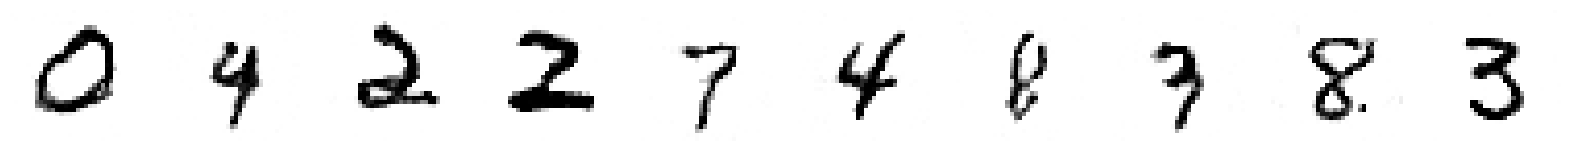


Saved to ./output/example_img_057.png


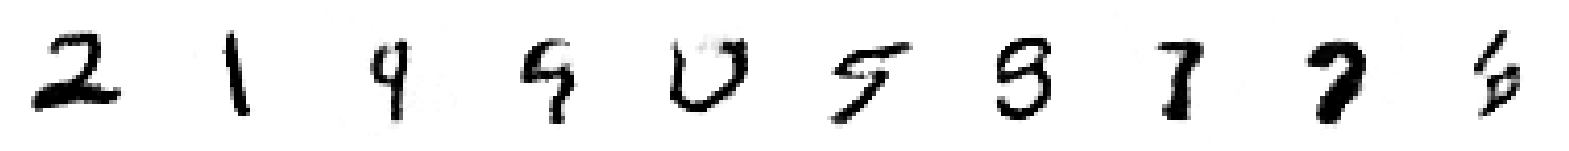

469/469 ━━━━━━━━━━━━━━━━━━━━ 657s 1s/step - cdiv: 2.4896e-04 - fake: -9.9003e-05 - loss: 3.9336e-04 - real: -3.4796e-04 - reg: 1.4440e-04 - val_cdiv: -20.0848 - val_fake: -20.0819 - val_real: 0.0028
Epoch 59/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.5433e-04 - fake: -4.1956e-04 - loss: -4.9158e-04 - real: 2.3478e-04 - reg: 1.6275e-04
Saved to ./output/generated_img_058.png


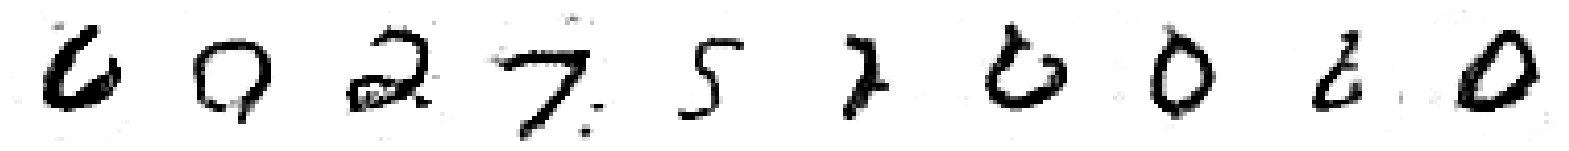


Saved to ./output/example_img_058.png


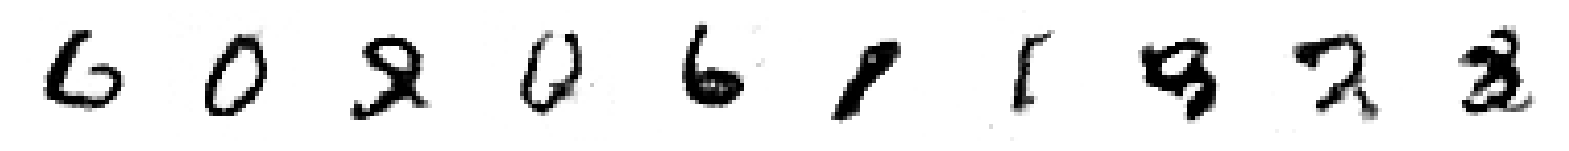

469/469 ━━━━━━━━━━━━━━━━━━━━ 657s 1s/step - cdiv: -3.5547e-04 - fake: -1.1355e-04 - loss: -2.0044e-04 - real: 2.4192e-04 - reg: 1.5503e-04 - val_cdiv: -20.5264 - val_fake: -20.5207 - val_real: 0.0057
Epoch 60/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.1692e-04 - fake: 1.0450e-04 - loss: -4.9915e-05 - real: 3.2142e-04 - reg: 1.6701e-04
Saved to ./output/generated_img_059.png


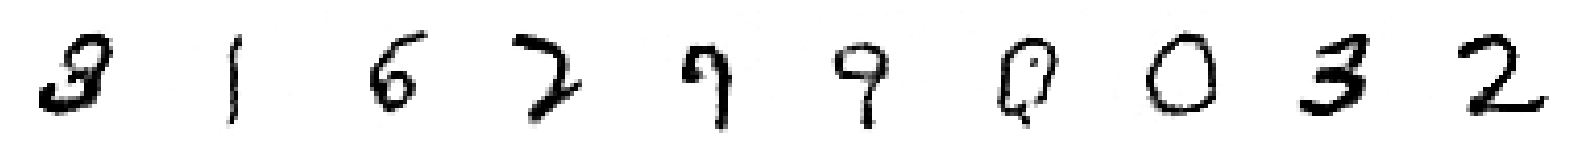


Saved to ./output/example_img_059.png


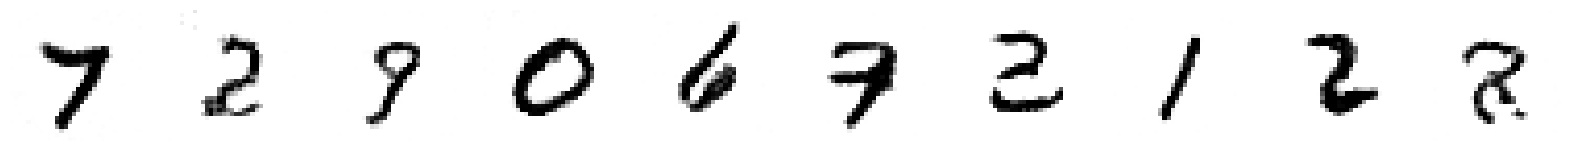

469/469 ━━━━━━━━━━━━━━━━━━━━ 656s 1s/step - cdiv: 9.1862e-05 - fake: 2.0100e-04 - loss: 2.3233e-04 - real: 1.0913e-04 - reg: 1.4047e-04 - val_cdiv: -21.4265 - val_fake: -21.4258 - val_real: 6.6716e-04
Epoch 61/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.1744e-04 - fake: -8.7648e-04 - loss: -7.1458e-05 - real: -6.5904e-04 - reg: 1.4598e-04
Saved to ./output/generated_img_060.png


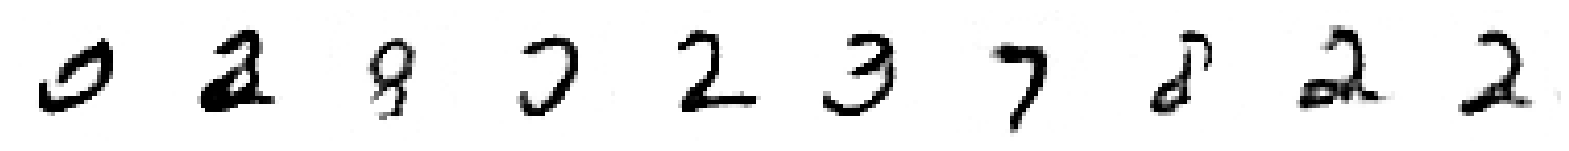


Saved to ./output/example_img_060.png


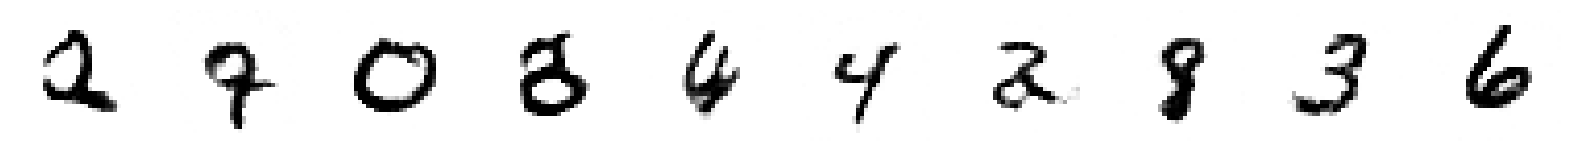

469/469 ━━━━━━━━━━━━━━━━━━━━ 657s 1s/step - cdiv: 8.4357e-05 - fake: -3.0813e-05 - loss: 2.2512e-04 - real: -1.1517e-04 - reg: 1.4076e-04 - val_cdiv: -20.8943 - val_fake: -20.8946 - val_real: -2.9299e-04
Epoch 62/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.0027e-04 - fake: -3.5120e-04 - loss: -1.4386e-04 - real: -5.0925e-05 - reg: 1.5641e-04
Saved to ./output/generated_img_061.png


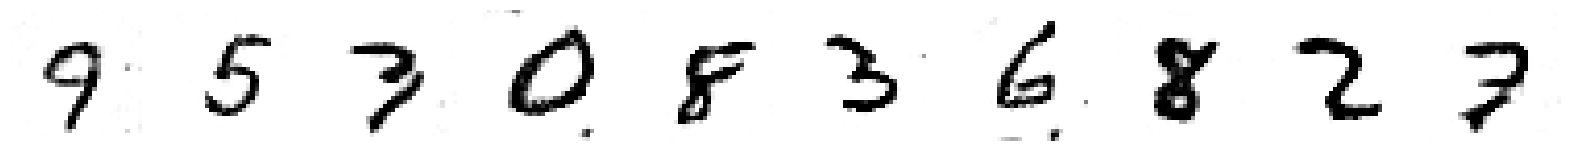


Saved to ./output/example_img_061.png


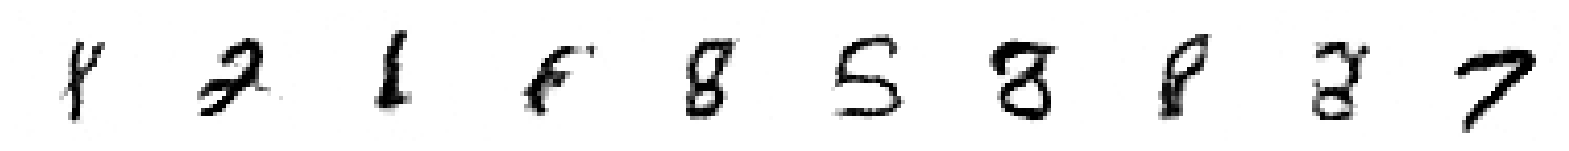

469/469 ━━━━━━━━━━━━━━━━━━━━ 658s 1s/step - cdiv: -1.7157e-04 - fake: 1.0169e-04 - loss: -1.6523e-05 - real: 2.7326e-04 - reg: 1.5505e-04 - val_cdiv: -21.1568 - val_fake: -21.1561 - val_real: 7.6074e-04
Epoch 63/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.3380e-04 - fake: -6.0470e-04 - loss: -7.4674e-05 - real: -3.7090e-04 - reg: 1.5912e-04
Saved to ./output/generated_img_062.png


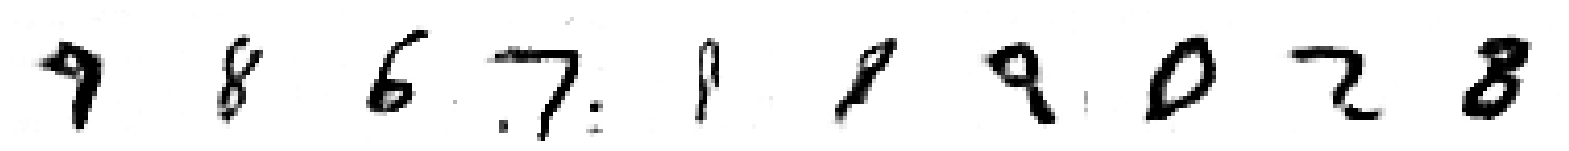


Saved to ./output/example_img_062.png


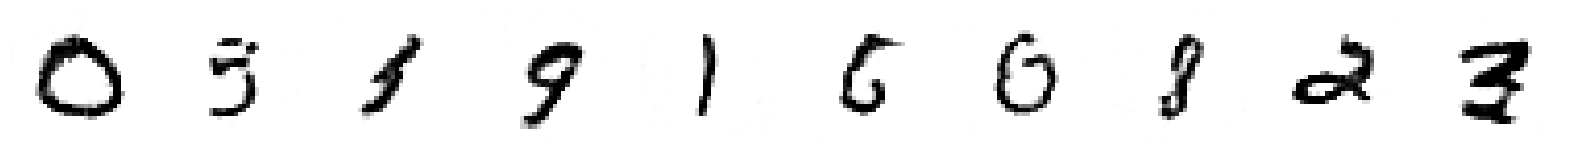

469/469 ━━━━━━━━━━━━━━━━━━━━ 657s 1s/step - cdiv: -1.7367e-05 - fake: 2.9857e-04 - loss: 1.2256e-04 - real: 3.1594e-04 - reg: 1.3993e-04 - val_cdiv: -21.0379 - val_fake: -21.0432 - val_real: -0.0053
Epoch 64/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.9543e-04 - fake: -8.5320e-04 - loss: -1.0938e-04 - real: -5.5777e-04 - reg: 1.8604e-04
Saved to ./output/generated_img_063.png


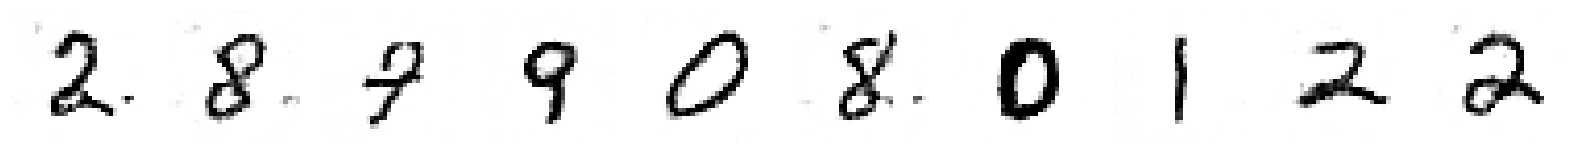


Saved to ./output/example_img_063.png


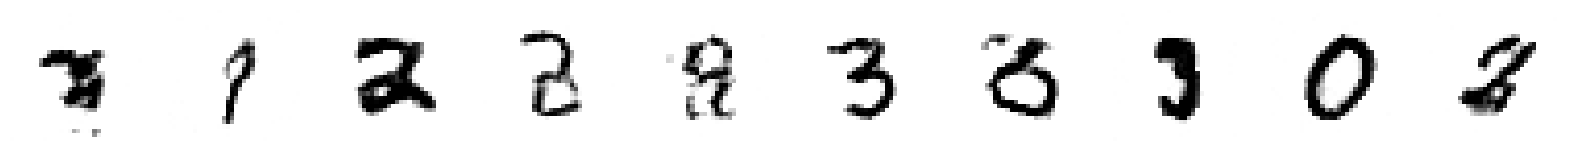

469/469 ━━━━━━━━━━━━━━━━━━━━ 657s 1s/step - cdiv: -4.5559e-06 - fake: -6.4558e-05 - loss: 1.5425e-04 - real: -6.0002e-05 - reg: 1.5880e-04 - val_cdiv: -21.3226 - val_fake: -21.3197 - val_real: 0.0029
Epoch 65/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -5.6055e-04 - fake: -2.3893e-04 - loss: -3.7384e-04 - real: 3.2162e-04 - reg: 1.8671e-04
Saved to ./output/generated_img_064.png


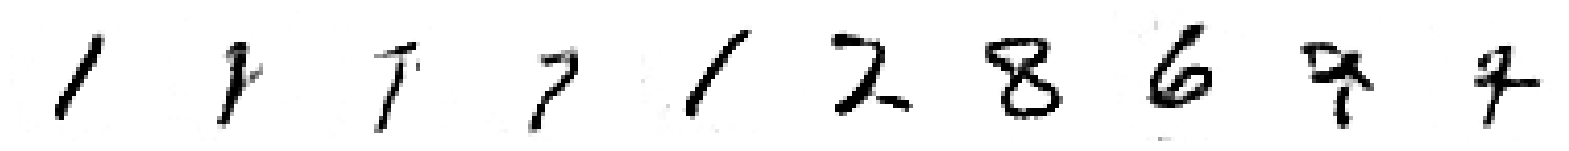


Saved to ./output/example_img_064.png


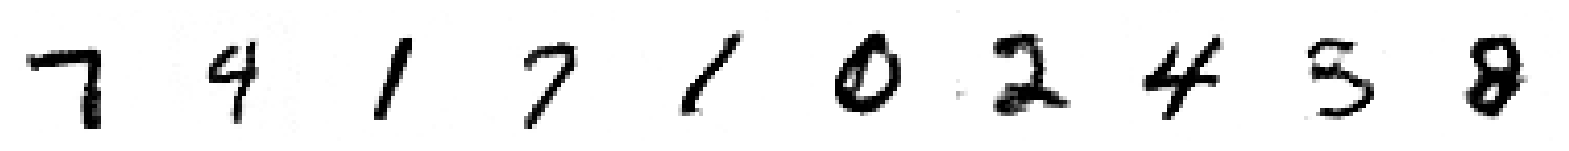

469/469 ━━━━━━━━━━━━━━━━━━━━ 660s 1s/step - cdiv: -1.8813e-04 - fake: -1.1156e-04 - loss: -2.8474e-05 - real: 7.6567e-05 - reg: 1.5966e-04 - val_cdiv: -22.0167 - val_fake: -22.0012 - val_real: 0.0154
Epoch 66/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.3409e-04 - fake: 0.0011 - loss: -3.0470e-05 - real: 0.0014 - reg: 2.0362e-04
Saved to ./output/generated_img_065.png


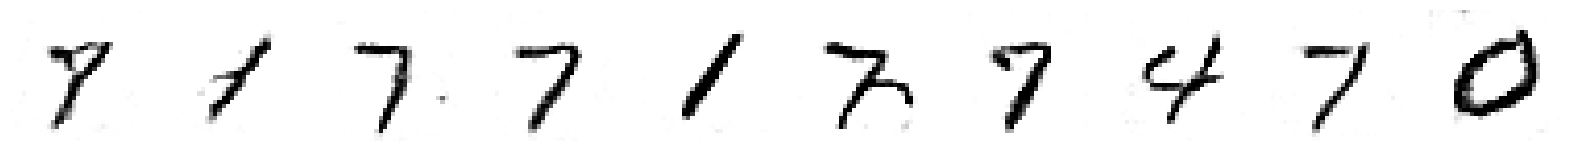


Saved to ./output/example_img_065.png


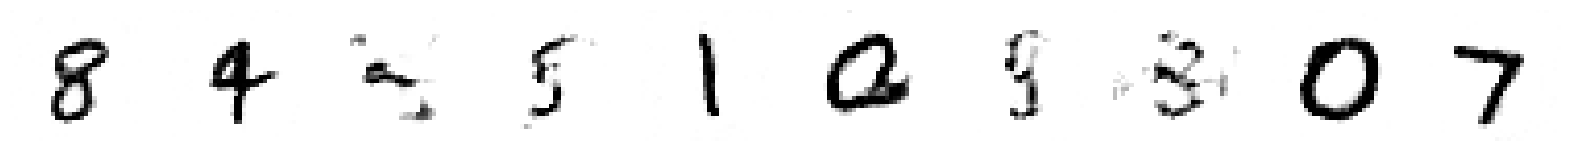

469/469 ━━━━━━━━━━━━━━━━━━━━ 659s 1s/step - cdiv: 2.2423e-04 - fake: 1.6912e-04 - loss: 3.7995e-04 - real: -5.5111e-05 - reg: 1.5572e-04 - val_cdiv: -22.1162 - val_fake: -22.1035 - val_real: 0.0127
Epoch 67/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.8156e-04 - fake: 2.9787e-04 - loss: -4.7916e-04 - real: 9.7943e-04 - reg: 2.0240e-04
Saved to ./output/generated_img_066.png


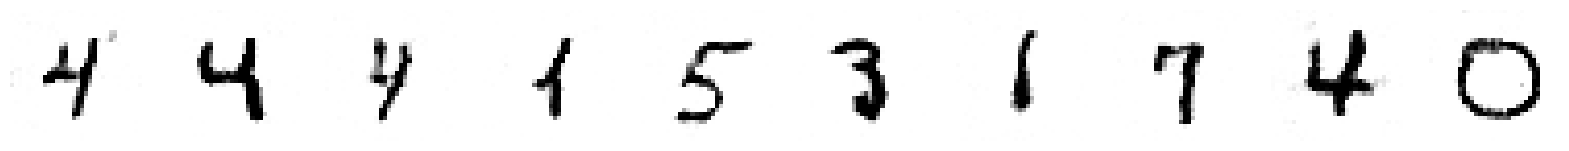


Saved to ./output/example_img_066.png


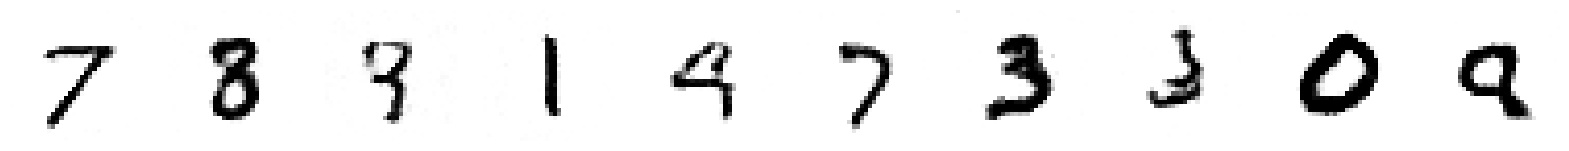

469/469 ━━━━━━━━━━━━━━━━━━━━ 661s 1s/step - cdiv: -1.4360e-04 - fake: 4.1903e-05 - loss: 2.8617e-05 - real: 1.8550e-04 - reg: 1.7221e-04 - val_cdiv: -22.2201 - val_fake: -22.2126 - val_real: 0.0075
Epoch 68/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.4643e-04 - fake: 4.1842e-04 - loss: -1.2123e-04 - real: 6.6485e-04 - reg: 1.2520e-04
Saved to ./output/generated_img_067.png


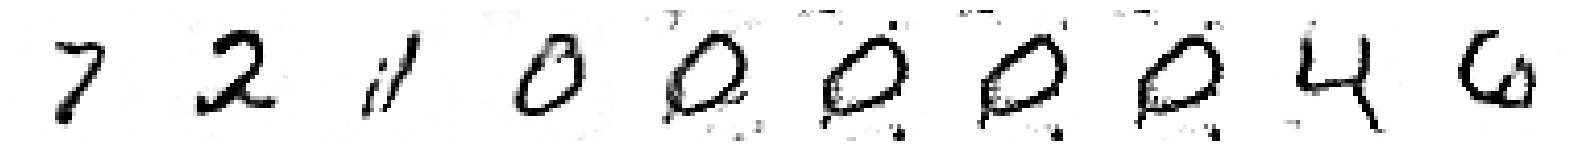


Saved to ./output/example_img_067.png


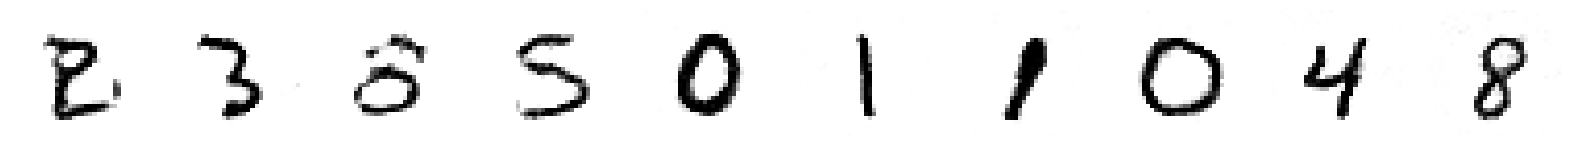

469/469 ━━━━━━━━━━━━━━━━━━━━ 662s 1s/step - cdiv: -1.4277e-04 - fake: 3.1654e-06 - loss: -1.3390e-05 - real: 1.4594e-04 - reg: 1.2938e-04 - val_cdiv: -22.4639 - val_fake: -22.4605 - val_real: 0.0034
Epoch 69/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 1.1644e-04 - fake: 4.6606e-04 - loss: 3.1124e-04 - real: 3.4962e-04 - reg: 1.9480e-04
Saved to ./output/generated_img_068.png


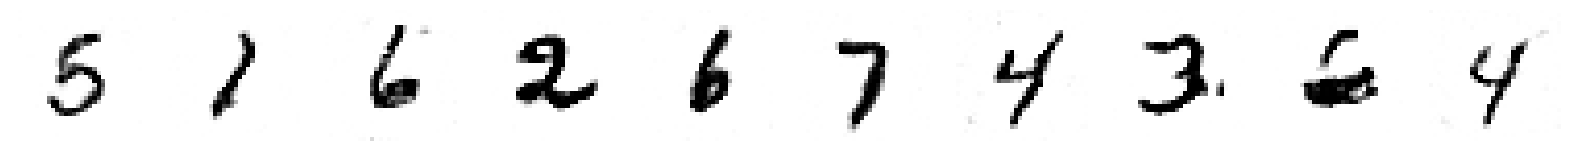


Saved to ./output/example_img_068.png


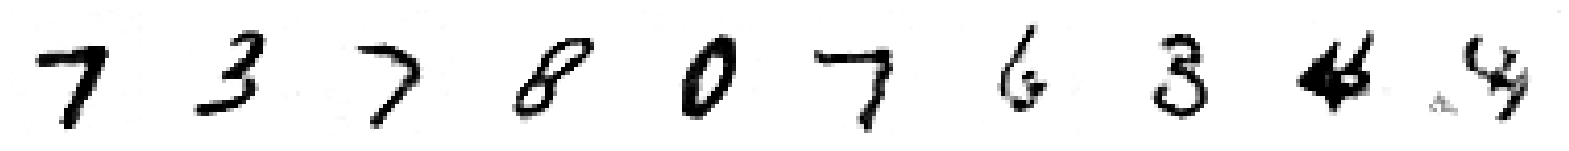

469/469 ━━━━━━━━━━━━━━━━━━━━ 662s 1s/step - cdiv: 2.6983e-04 - fake: 3.4923e-04 - loss: 4.0860e-04 - real: 7.9399e-05 - reg: 1.3876e-04 - val_cdiv: -22.7635 - val_fake: -22.7552 - val_real: 0.0084
Epoch 70/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -5.2266e-04 - fake: -2.2730e-04 - loss: -3.4152e-04 - real: 2.9537e-04 - reg: 1.8114e-04
Saved to ./output/generated_img_069.png


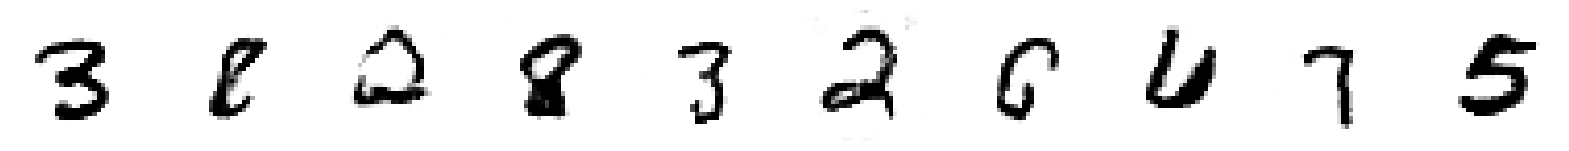


Saved to ./output/example_img_069.png


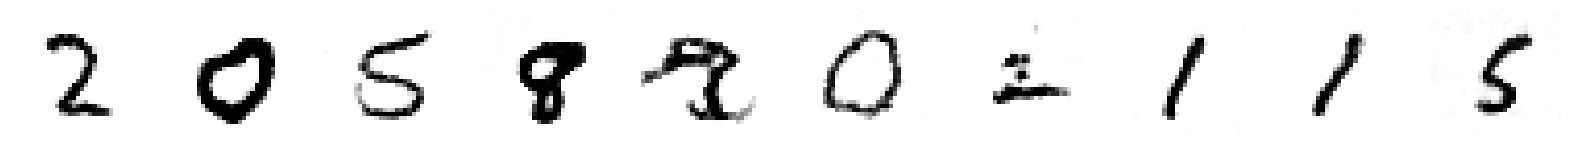

469/469 ━━━━━━━━━━━━━━━━━━━━ 660s 1s/step - cdiv: -1.6809e-04 - fake: -3.3182e-04 - loss: -1.2063e-05 - real: -1.6373e-04 - reg: 1.5603e-04 - val_cdiv: -22.2789 - val_fake: -22.2771 - val_real: 0.0018
Epoch 71/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.8580e-04 - fake: 0.0010 - loss: -1.8640e-04 - real: 0.0014 - reg: 1.9940e-04
Saved to ./output/generated_img_070.png


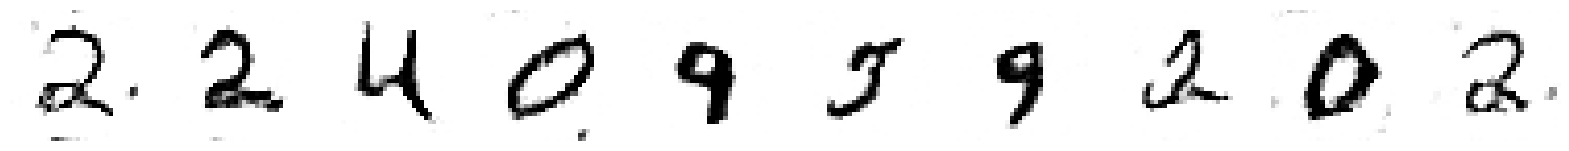


Saved to ./output/example_img_070.png


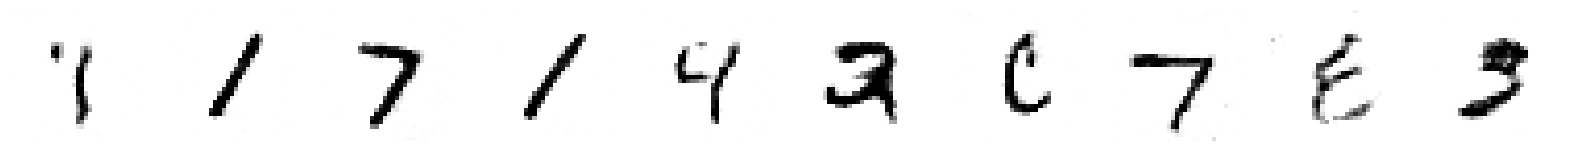

469/469 ━━━━━━━━━━━━━━━━━━━━ 662s 1s/step - cdiv: -5.8331e-05 - fake: -1.1970e-06 - loss: 1.1862e-04 - real: 5.7133e-05 - reg: 1.7696e-04 - val_cdiv: -23.3308 - val_fake: -23.3219 - val_real: 0.0089
Epoch 72/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.0626e-04 - fake: 7.6207e-04 - loss: -4.0160e-04 - real: 0.0014 - reg: 2.0465e-04
Saved to ./output/generated_img_071.png


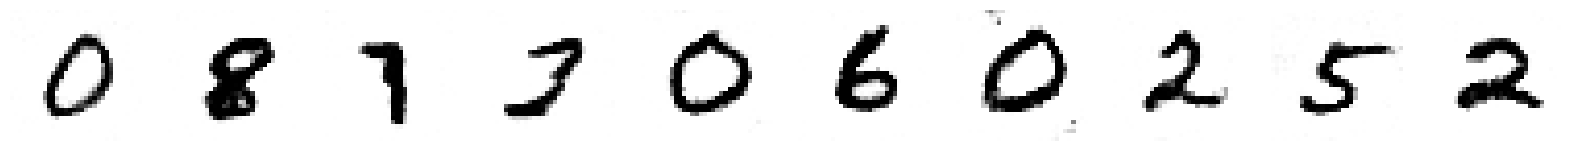


Saved to ./output/example_img_071.png


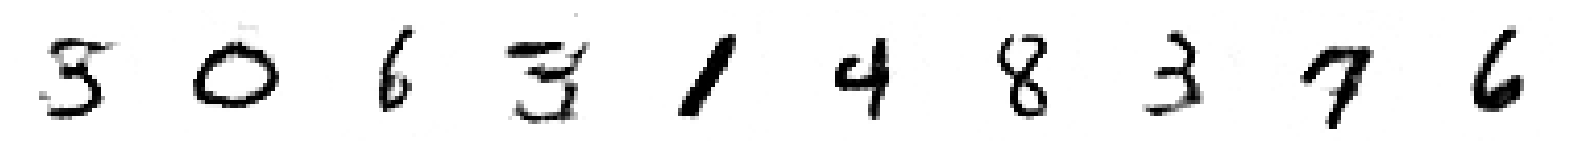

469/469 ━━━━━━━━━━━━━━━━━━━━ 661s 1s/step - cdiv: -1.3190e-04 - fake: 2.1114e-05 - loss: 5.2354e-05 - real: 1.5302e-04 - reg: 1.8426e-04 - val_cdiv: -23.5212 - val_fake: -23.5242 - val_real: -0.0030
Epoch 73/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -5.7293e-04 - fake: 4.0203e-04 - loss: -4.0019e-04 - real: 9.7495e-04 - reg: 1.7274e-04
Saved to ./output/generated_img_072.png


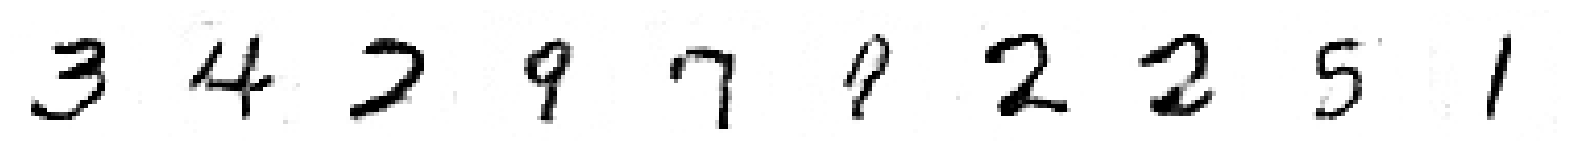


Saved to ./output/example_img_072.png


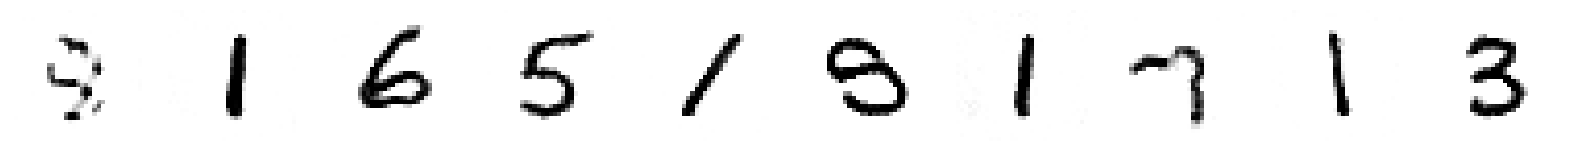

469/469 ━━━━━━━━━━━━━━━━━━━━ 661s 1s/step - cdiv: -2.2920e-04 - fake: 1.9833e-04 - loss: -4.3284e-05 - real: 4.2753e-04 - reg: 1.8591e-04 - val_cdiv: -23.8056 - val_fake: -23.7927 - val_real: 0.0129
Epoch 74/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.3029e-04 - fake: 9.5024e-04 - loss: -1.1758e-04 - real: 0.0013 - reg: 2.1271e-04
Saved to ./output/generated_img_073.png


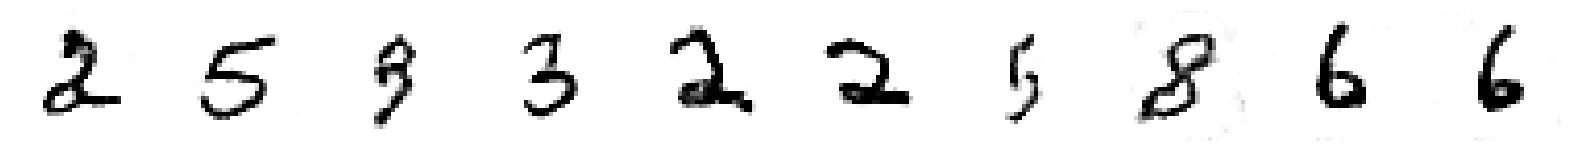


Saved to ./output/example_img_073.png


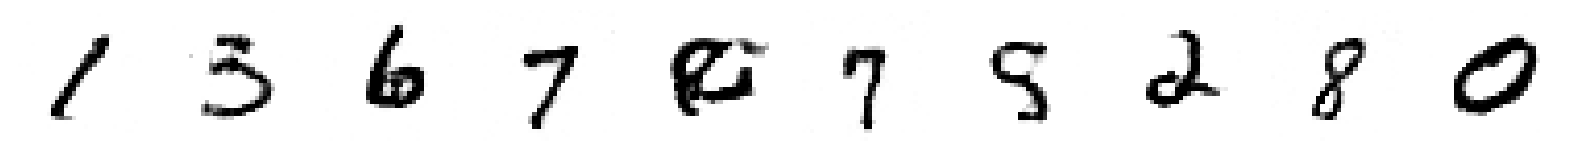

469/469 ━━━━━━━━━━━━━━━━━━━━ 664s 1s/step - cdiv: 6.6732e-05 - fake: 3.0584e-05 - loss: 2.5021e-04 - real: -3.6148e-05 - reg: 1.8348e-04 - val_cdiv: -23.7377 - val_fake: -23.7380 - val_real: -3.2535e-04
Epoch 75/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.0450e-04 - fake: 2.8016e-04 - loss: -4.1863e-04 - real: 8.8466e-04 - reg: 1.8587e-04
Saved to ./output/generated_img_074.png


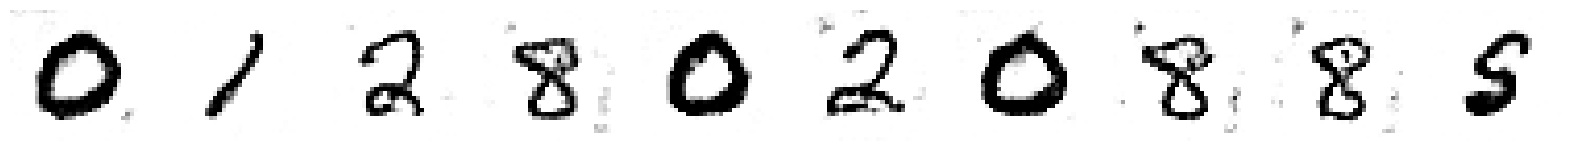


Saved to ./output/example_img_074.png


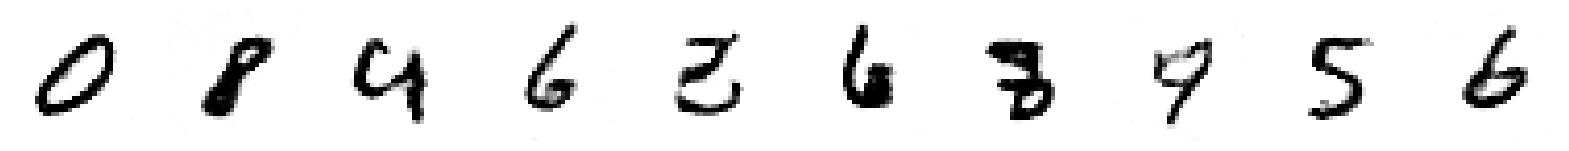

469/469 ━━━━━━━━━━━━━━━━━━━━ 664s 1s/step - cdiv: -2.8608e-04 - fake: -3.2397e-06 - loss: -8.8149e-05 - real: 2.8284e-04 - reg: 1.9793e-04 - val_cdiv: -23.3579 - val_fake: -23.3630 - val_real: -0.0051
Epoch 76/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.9969e-04 - fake: 2.8111e-04 - loss: -1.5320e-04 - real: 5.8080e-04 - reg: 1.4649e-04
Saved to ./output/generated_img_075.png


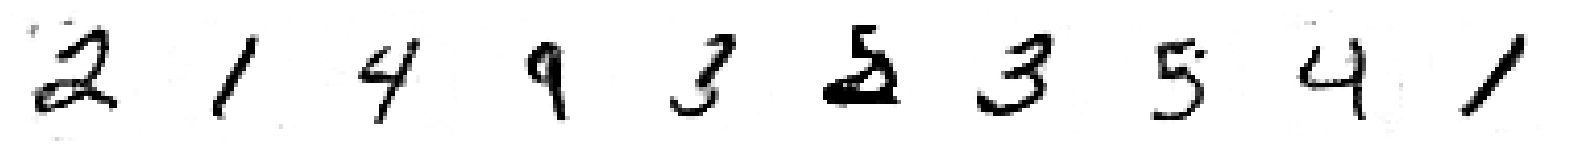


Saved to ./output/example_img_075.png


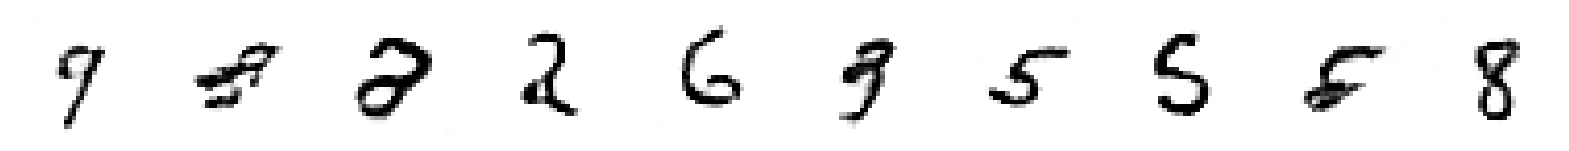

469/469 ━━━━━━━━━━━━━━━━━━━━ 665s 1s/step - cdiv: -1.6740e-04 - fake: 4.8642e-05 - loss: -1.0572e-05 - real: 2.1604e-04 - reg: 1.5683e-04 - val_cdiv: -23.8362 - val_fake: -23.8420 - val_real: -0.0058
Epoch 77/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -5.4951e-04 - fake: 3.8134e-04 - loss: -3.0483e-04 - real: 9.3084e-04 - reg: 2.4468e-04
Saved to ./output/generated_img_076.png


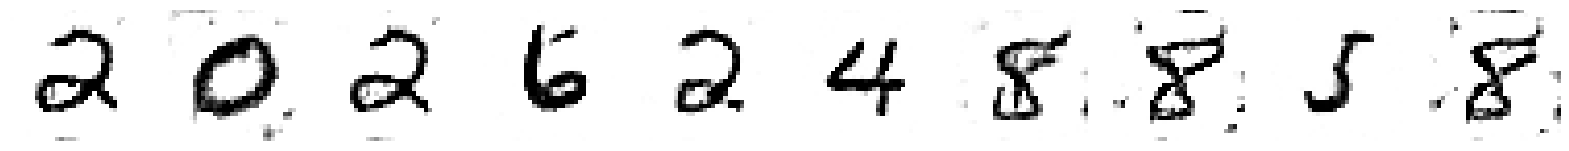


Saved to ./output/example_img_076.png


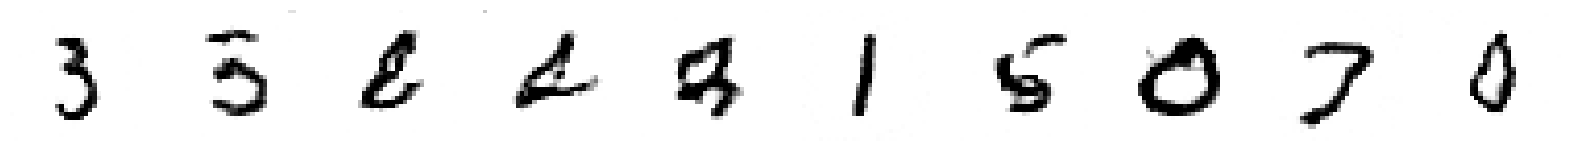

469/469 ━━━━━━━━━━━━━━━━━━━━ 665s 1s/step - cdiv: -4.6945e-05 - fake: -2.9664e-05 - loss: 1.4564e-04 - real: 1.7282e-05 - reg: 1.9259e-04 - val_cdiv: -24.6040 - val_fake: -24.6108 - val_real: -0.0069
Epoch 78/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.6032e-04 - fake: 2.2885e-04 - loss: -1.7509e-04 - real: 5.8917e-04 - reg: 1.8523e-04
Saved to ./output/generated_img_077.png


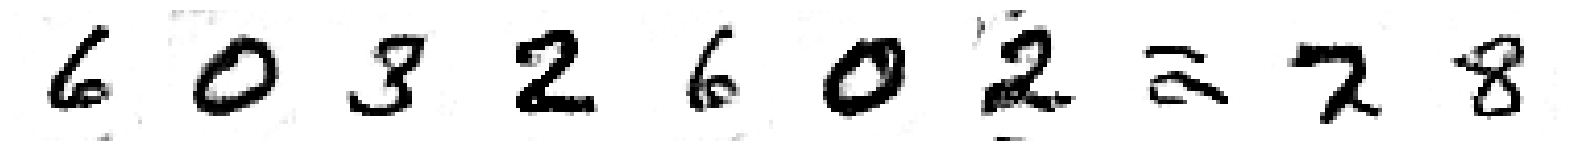


Saved to ./output/example_img_077.png


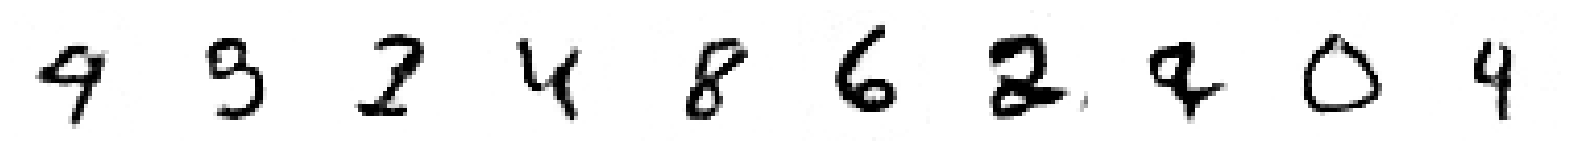

469/469 ━━━━━━━━━━━━━━━━━━━━ 669s 1s/step - cdiv: -1.8618e-04 - fake: -3.2481e-04 - loss: -1.8004e-05 - real: -1.3863e-04 - reg: 1.6818e-04 - val_cdiv: -24.6155 - val_fake: -24.6102 - val_real: 0.0052
Epoch 79/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.1270e-04 - fake: 0.0017 - loss: 5.8649e-05 - real: 0.0018 - reg: 1.7135e-04
Saved to ./output/generated_img_078.png


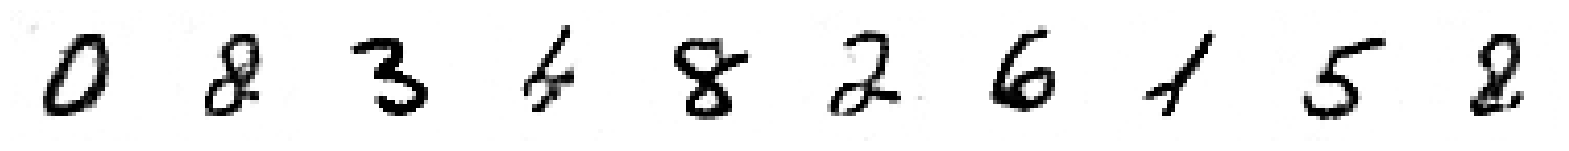


Saved to ./output/example_img_078.png


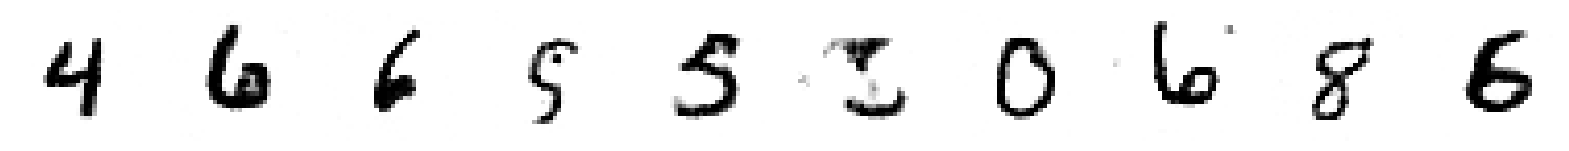

469/469 ━━━━━━━━━━━━━━━━━━━━ 666s 1s/step - cdiv: 1.3396e-05 - fake: 4.6878e-04 - loss: 1.7304e-04 - real: 4.5539e-04 - reg: 1.5965e-04 - val_cdiv: -24.8800 - val_fake: -24.8827 - val_real: -0.0026
Epoch 80/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.5662e-04 - fake: 2.7902e-04 - loss: -8.0791e-05 - real: 5.3564e-04 - reg: 1.7583e-04
Saved to ./output/generated_img_079.png


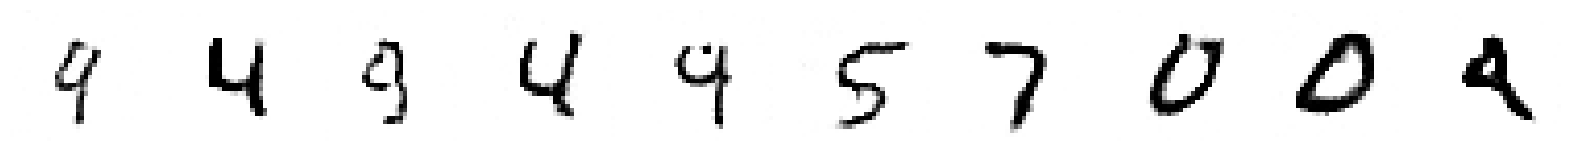


Saved to ./output/example_img_079.png


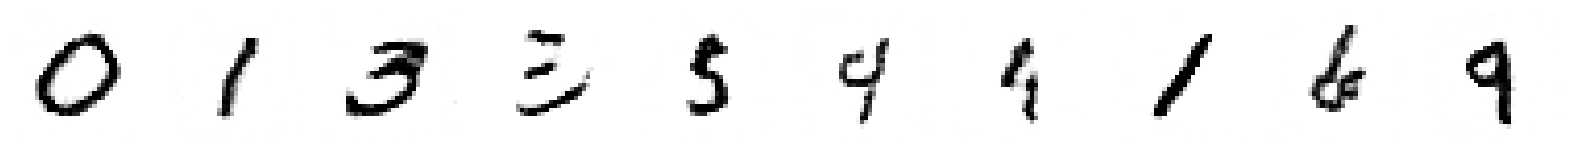

469/469 ━━━━━━━━━━━━━━━━━━━━ 667s 1s/step - cdiv: -7.2044e-05 - fake: 1.6483e-04 - loss: 8.9432e-05 - real: 2.3687e-04 - reg: 1.6148e-04 - val_cdiv: -25.3303 - val_fake: -25.3358 - val_real: -0.0055
Epoch 81/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -5.0578e-04 - fake: 3.3025e-06 - loss: -3.0949e-04 - real: 5.0908e-04 - reg: 1.9629e-04
Saved to ./output/generated_img_080.png


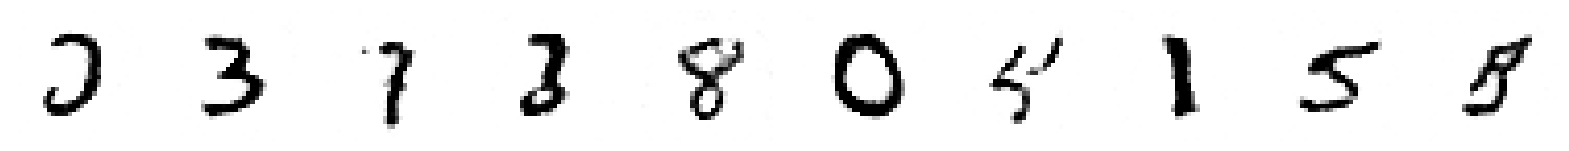


Saved to ./output/example_img_080.png


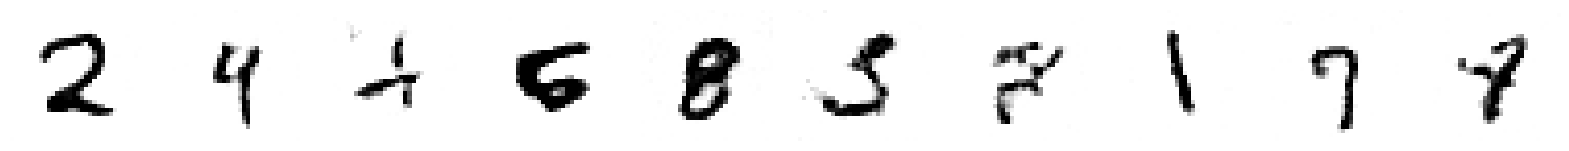

469/469 ━━━━━━━━━━━━━━━━━━━━ 668s 1s/step - cdiv: -1.5815e-04 - fake: -1.2568e-04 - loss: 2.3081e-05 - real: 3.2465e-05 - reg: 1.8123e-04 - val_cdiv: -25.1875 - val_fake: -25.1838 - val_real: 0.0037
Epoch 82/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.7210e-04 - fake: 2.0784e-04 - loss: -1.9852e-04 - real: 5.7993e-04 - reg: 1.7358e-04
Saved to ./output/generated_img_081.png


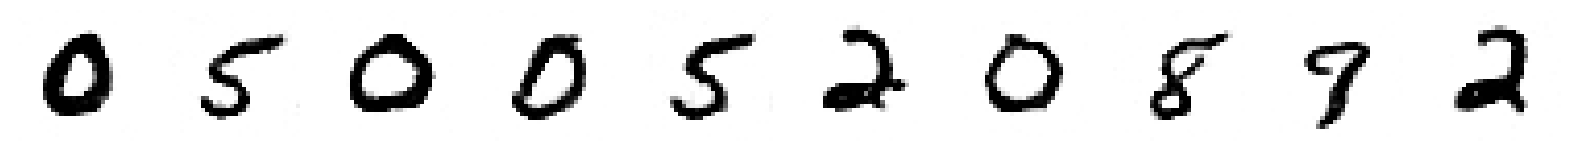


Saved to ./output/example_img_081.png


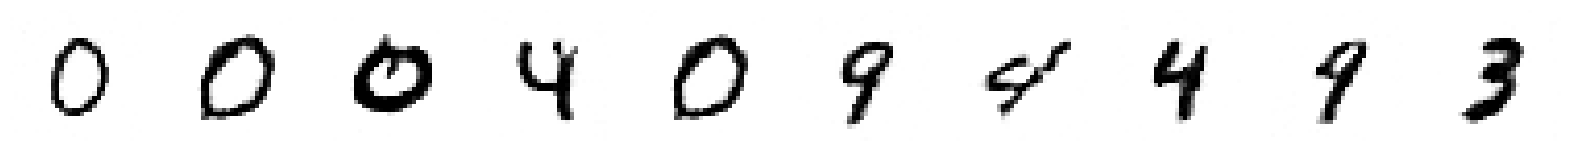

469/469 ━━━━━━━━━━━━━━━━━━━━ 670s 1s/step - cdiv: -8.9287e-05 - fake: -2.4468e-04 - loss: 8.0040e-05 - real: -1.5539e-04 - reg: 1.6933e-04 - val_cdiv: -24.8904 - val_fake: -24.8974 - val_real: -0.0069
Epoch 83/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.8073e-04 - fake: 9.7098e-04 - loss: -9.9738e-05 - real: 0.0013 - reg: 1.8099e-04
Saved to ./output/generated_img_082.png


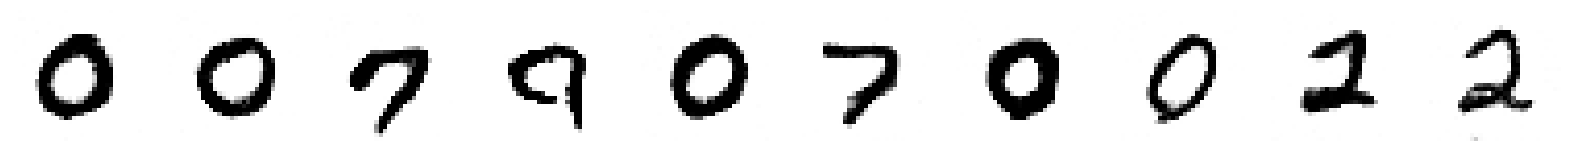


Saved to ./output/example_img_082.png


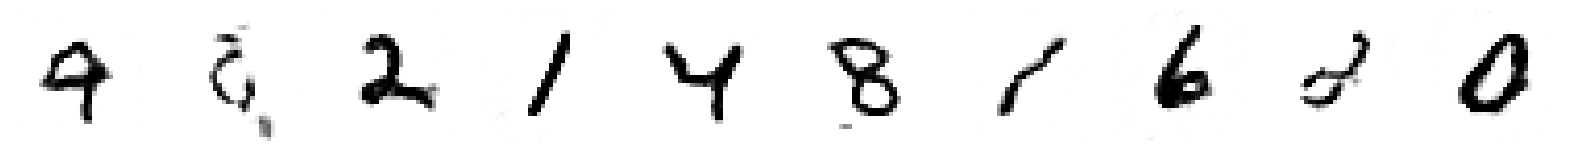

469/469 ━━━━━━━━━━━━━━━━━━━━ 670s 1s/step - cdiv: -1.0384e-04 - fake: 1.0379e-04 - loss: 8.8764e-05 - real: 2.0763e-04 - reg: 1.9261e-04 - val_cdiv: -25.3546 - val_fake: -25.3676 - val_real: -0.0131
Epoch 84/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.5596e-04 - fake: 5.6982e-04 - loss: -6.0734e-05 - real: 8.2578e-04 - reg: 1.9523e-04
Saved to ./output/generated_img_083.png


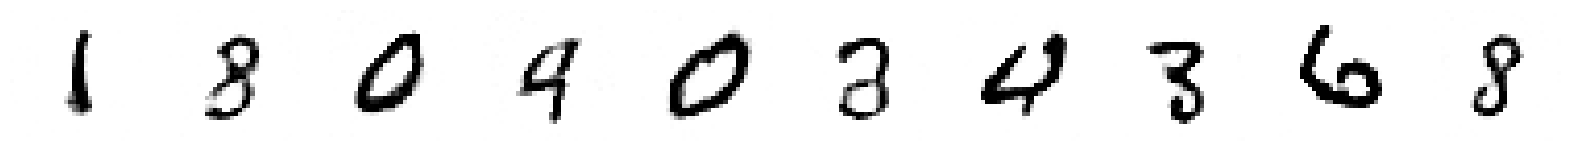


Saved to ./output/example_img_083.png


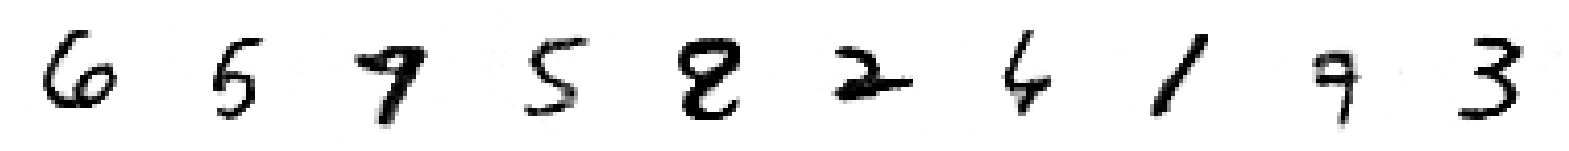

469/469 ━━━━━━━━━━━━━━━━━━━━ 670s 1s/step - cdiv: 2.7279e-06 - fake: 1.3997e-05 - loss: 1.8019e-04 - real: 1.1270e-05 - reg: 1.7746e-04 - val_cdiv: -24.5826 - val_fake: -24.5896 - val_real: -0.0070
Epoch 85/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.7644e-04 - fake: -1.7896e-04 - loss: -1.9925e-04 - real: 1.9748e-04 - reg: 1.7719e-04
Saved to ./output/generated_img_084.png


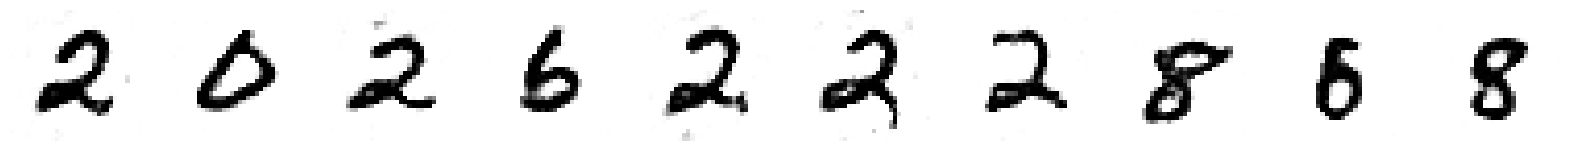


Saved to ./output/example_img_084.png


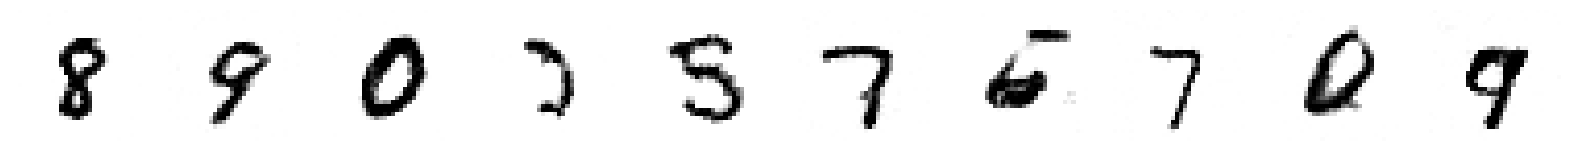

469/469 ━━━━━━━━━━━━━━━━━━━━ 670s 1s/step - cdiv: -3.0042e-04 - fake: -2.2644e-04 - loss: -1.1726e-04 - real: 7.3976e-05 - reg: 1.8315e-04 - val_cdiv: -24.8704 - val_fake: -24.8779 - val_real: -0.0075
Epoch 86/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.4066e-04 - fake: 9.7662e-04 - loss: -3.7251e-04 - real: 0.0016 - reg: 2.6814e-04
Saved to ./output/generated_img_085.png


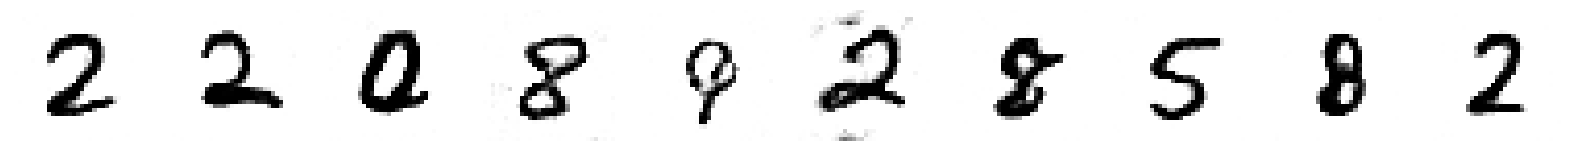


Saved to ./output/example_img_085.png


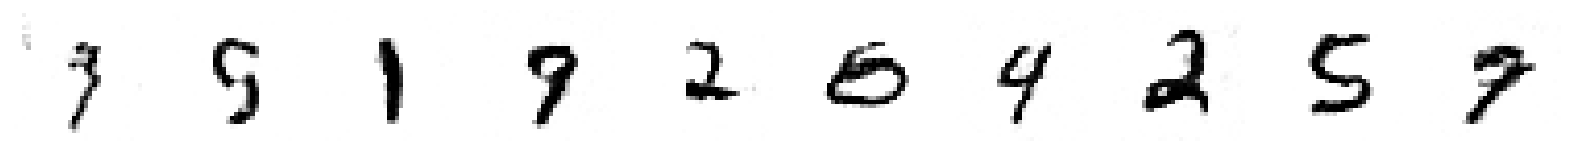

469/469 ━━━━━━━━━━━━━━━━━━━━ 670s 1s/step - cdiv: -1.3017e-04 - fake: 5.4561e-05 - loss: 8.0303e-05 - real: 1.8473e-04 - reg: 2.1047e-04 - val_cdiv: -25.7848 - val_fake: -25.7973 - val_real: -0.0124
Epoch 87/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.4356e-04 - fake: -2.0060e-05 - loss: -6.3477e-05 - real: 2.2350e-04 - reg: 1.8008e-04
Saved to ./output/generated_img_086.png


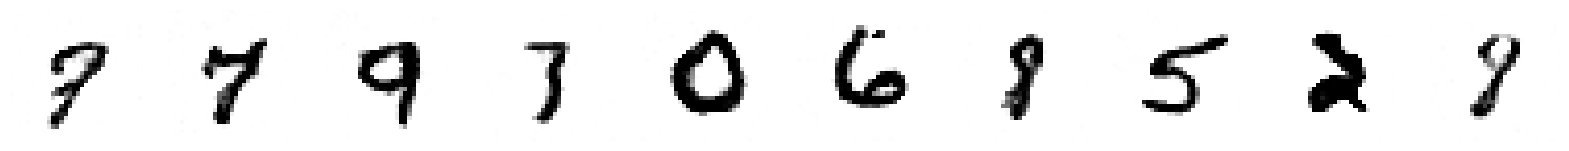


Saved to ./output/example_img_086.png


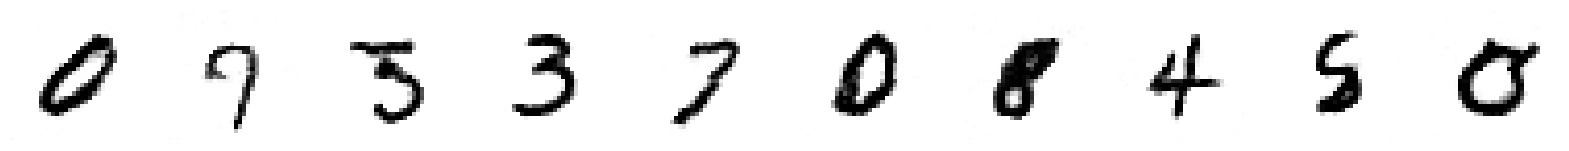

469/469 ━━━━━━━━━━━━━━━━━━━━ 671s 1s/step - cdiv: -1.1527e-04 - fake: 1.7156e-05 - loss: 6.3566e-05 - real: 1.3243e-04 - reg: 1.7884e-04 - val_cdiv: -26.1650 - val_fake: -26.1554 - val_real: 0.0095
Epoch 88/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -7.7661e-04 - fake: 8.8919e-04 - loss: -5.2903e-04 - real: 0.0017 - reg: 2.4758e-04
Saved to ./output/generated_img_087.png


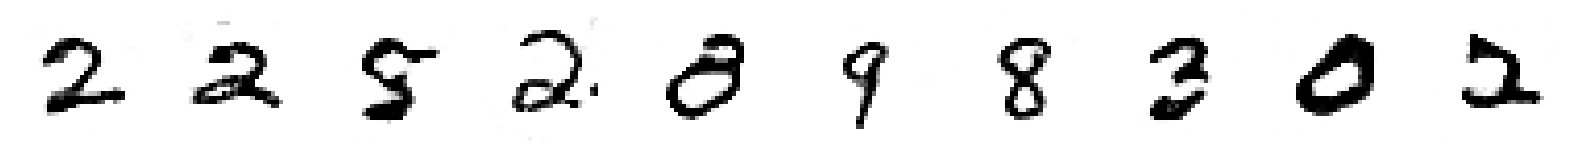


Saved to ./output/example_img_087.png


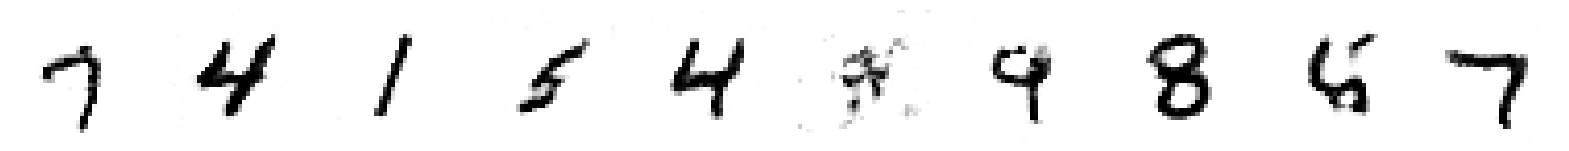

469/469 ━━━━━━━━━━━━━━━━━━━━ 672s 1s/step - cdiv: -2.3094e-04 - fake: 1.6731e-06 - loss: -4.6739e-06 - real: 2.3262e-04 - reg: 2.2627e-04 - val_cdiv: -26.3153 - val_fake: -26.3278 - val_real: -0.0124
Epoch 89/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.7138e-04 - fake: 5.7390e-04 - loss: -1.8928e-04 - real: 9.4528e-04 - reg: 1.8209e-04
Saved to ./output/generated_img_088.png


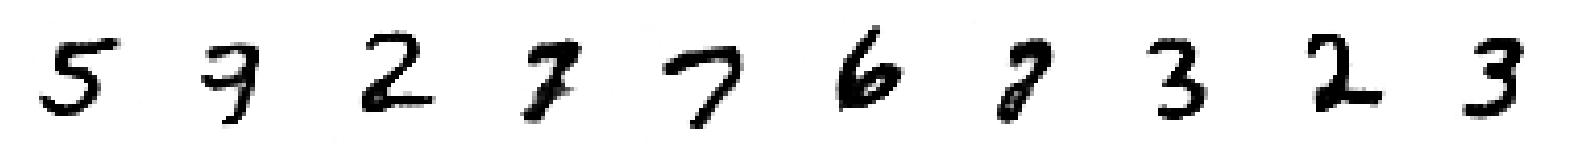


Saved to ./output/example_img_088.png


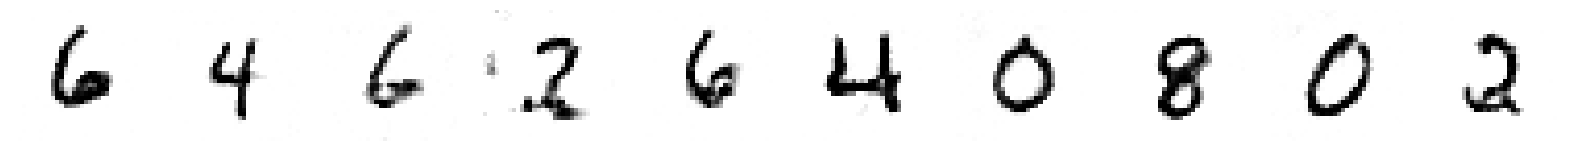

469/469 ━━━━━━━━━━━━━━━━━━━━ 671s 1s/step - cdiv: -1.9750e-04 - fake: -2.3340e-04 - loss: -1.3676e-05 - real: -3.5906e-05 - reg: 1.8382e-04 - val_cdiv: -26.6802 - val_fake: -26.6933 - val_real: -0.0130
Epoch 90/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.3714e-04 - fake: 0.0012 - loss: 5.5014e-05 - real: 0.0014 - reg: 1.9215e-04
Saved to ./output/generated_img_089.png


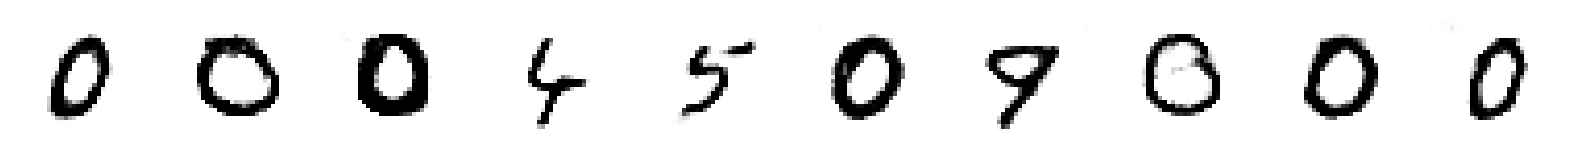


Saved to ./output/example_img_089.png


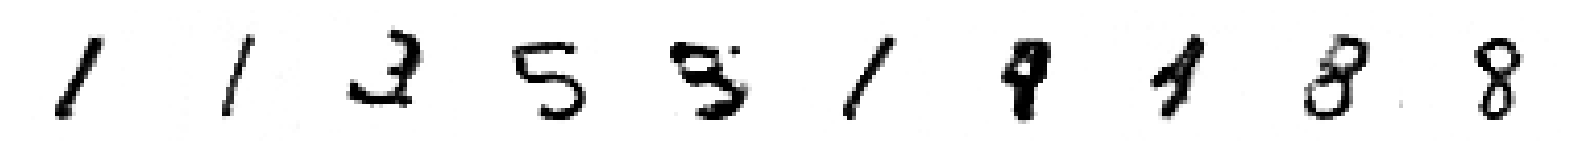

469/469 ━━━━━━━━━━━━━━━━━━━━ 672s 1s/step - cdiv: -5.1771e-05 - fake: 5.2097e-04 - loss: 1.2266e-04 - real: 5.7274e-04 - reg: 1.7443e-04 - val_cdiv: -26.6795 - val_fake: -26.6946 - val_real: -0.0150
Epoch 91/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.9044e-04 - fake: -6.5250e-04 - loss: 1.8948e-05 - real: -4.6207e-04 - reg: 2.0938e-04
Saved to ./output/generated_img_090.png


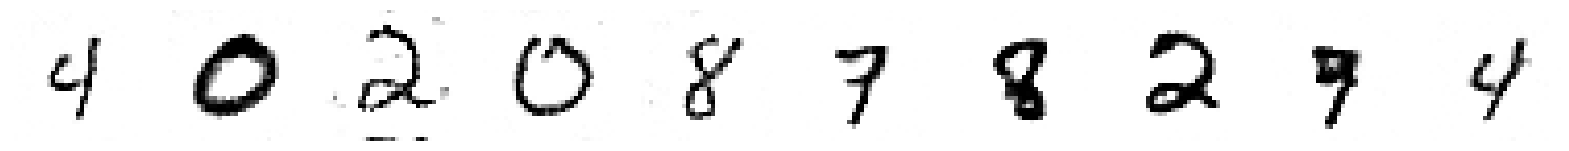


Saved to ./output/example_img_090.png


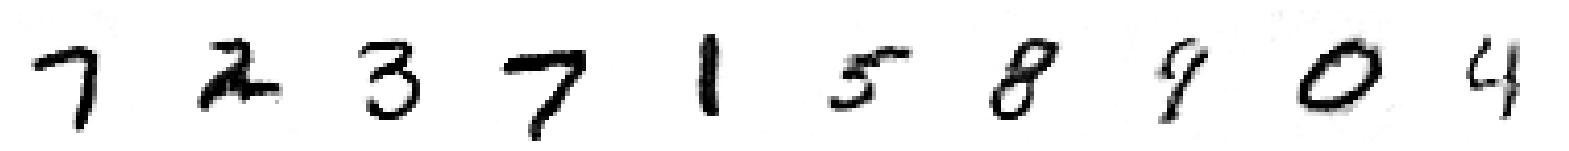

469/469 ━━━━━━━━━━━━━━━━━━━━ 671s 1s/step - cdiv: 8.4400e-05 - fake: 8.5133e-05 - loss: 2.4230e-04 - real: 7.3296e-07 - reg: 1.5790e-04 - val_cdiv: -27.5436 - val_fake: -27.5534 - val_real: -0.0098
Epoch 92/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.9265e-04 - fake: -5.7809e-04 - loss: -2.2336e-04 - real: -1.8544e-04 - reg: 1.6929e-04
Saved to ./output/generated_img_091.png


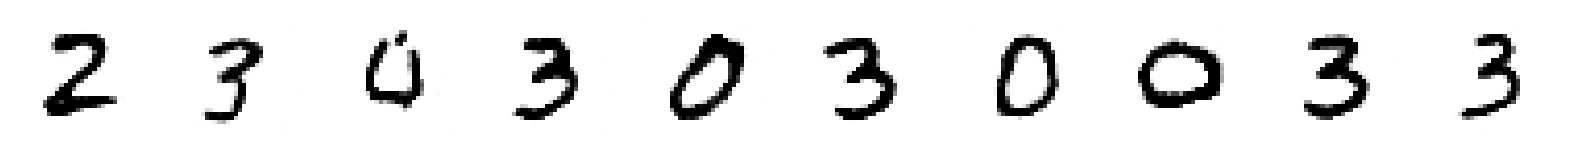


Saved to ./output/example_img_091.png


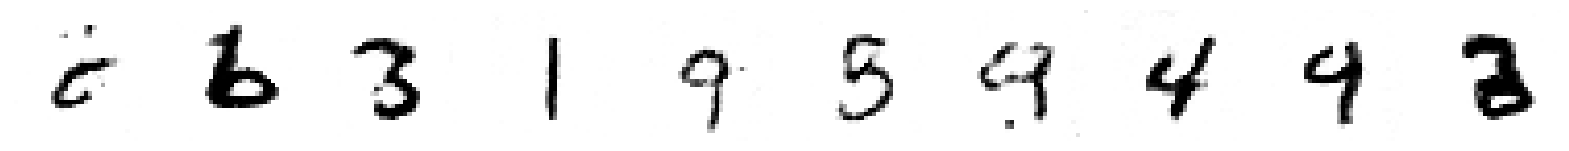

469/469 ━━━━━━━━━━━━━━━━━━━━ 673s 1s/step - cdiv: -1.4293e-04 - fake: -2.8917e-05 - loss: 1.4941e-05 - real: 1.1401e-04 - reg: 1.5787e-04 - val_cdiv: -26.8128 - val_fake: -26.8346 - val_real: -0.0218
Epoch 93/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.0116e-04 - fake: -6.0481e-04 - loss: 2.1438e-05 - real: -4.0365e-04 - reg: 2.2260e-04
Saved to ./output/generated_img_092.png


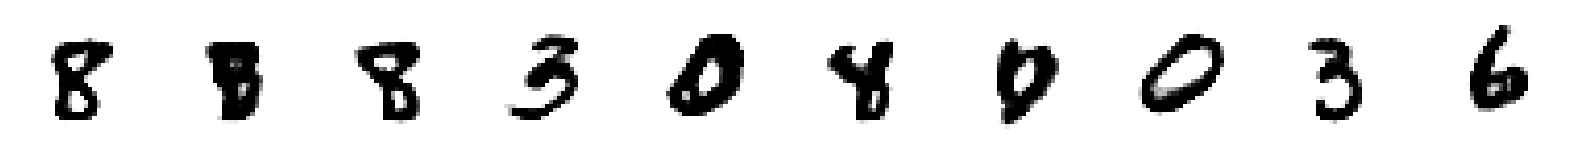


Saved to ./output/example_img_092.png


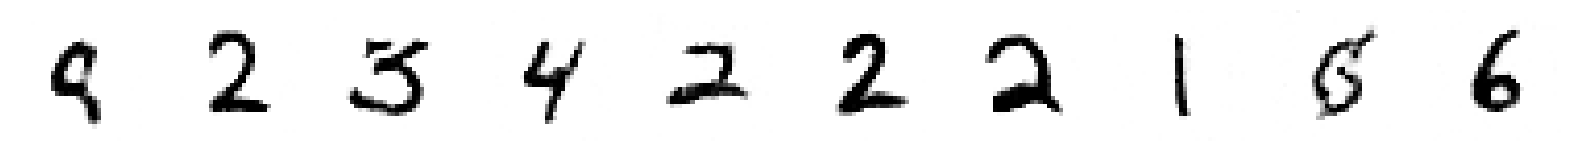

469/469 ━━━━━━━━━━━━━━━━━━━━ 674s 1s/step - cdiv: -6.8673e-05 - fake: -1.1434e-04 - loss: 1.1477e-04 - real: -4.5663e-05 - reg: 1.8345e-04 - val_cdiv: -26.0339 - val_fake: -26.0716 - val_real: -0.0377
Epoch 94/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 1.0132e-04 - fake: -2.7336e-04 - loss: 3.2304e-04 - real: -3.7468e-04 - reg: 2.2172e-04
Saved to ./output/generated_img_093.png


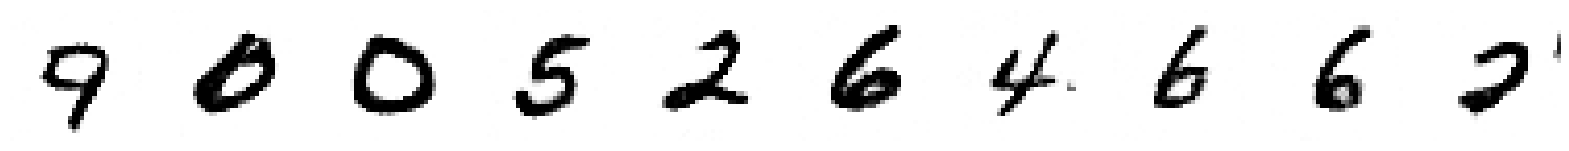


Saved to ./output/example_img_093.png


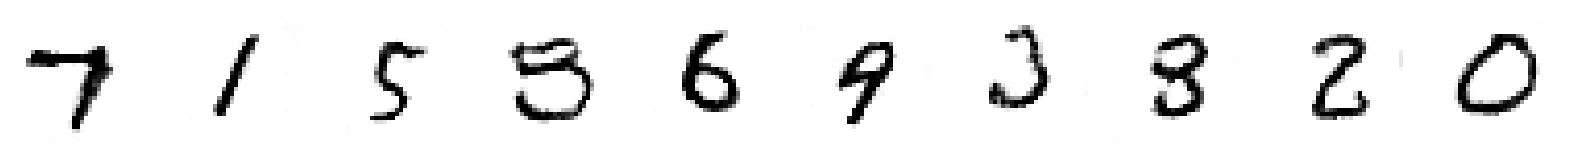

469/469 ━━━━━━━━━━━━━━━━━━━━ 674s 1s/step - cdiv: -5.1938e-05 - fake: 4.3861e-05 - loss: 1.0880e-04 - real: 9.5799e-05 - reg: 1.6074e-04 - val_cdiv: -26.9421 - val_fake: -26.9555 - val_real: -0.0134
Epoch 95/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.3224e-04 - fake: 3.7469e-04 - loss: 3.0943e-05 - real: 5.0693e-04 - reg: 1.6318e-04
Saved to ./output/generated_img_094.png


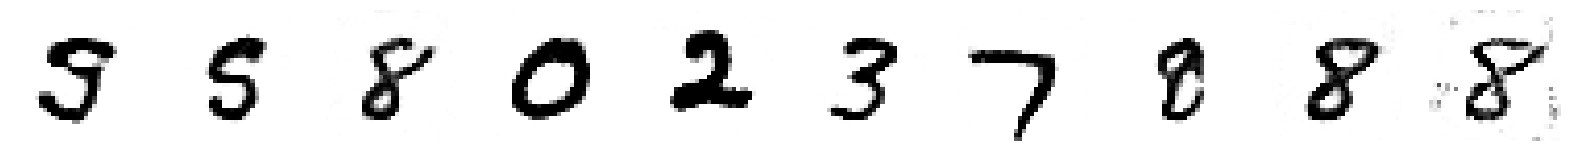


Saved to ./output/example_img_094.png


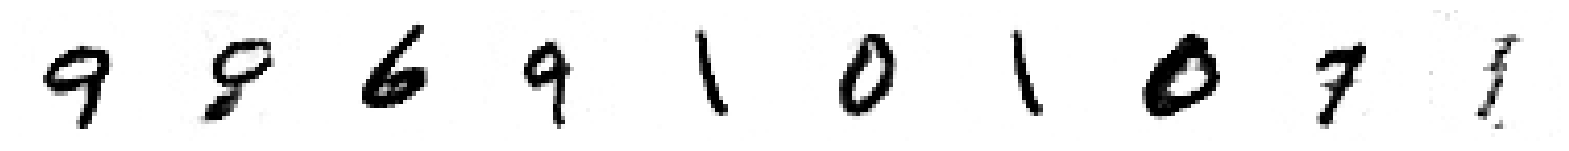

469/469 ━━━━━━━━━━━━━━━━━━━━ 679s 1s/step - cdiv: 4.2425e-05 - fake: 9.5388e-05 - loss: 1.7683e-04 - real: 5.2963e-05 - reg: 1.3441e-04 - val_cdiv: -27.0919 - val_fake: -27.1102 - val_real: -0.0183
Epoch 96/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.7508e-04 - fake: 1.2830e-04 - loss: 4.8432e-06 - real: 3.0338e-04 - reg: 1.7992e-04
Saved to ./output/generated_img_095.png


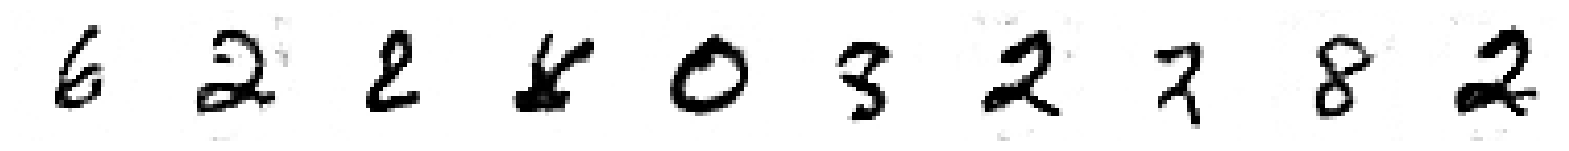


Saved to ./output/example_img_095.png


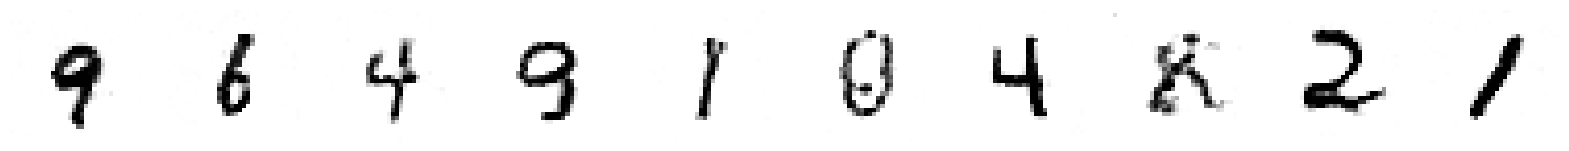

469/469 ━━━━━━━━━━━━━━━━━━━━ 679s 1s/step - cdiv: -1.0188e-04 - fake: -1.2980e-04 - loss: 3.5760e-05 - real: -2.7923e-05 - reg: 1.3764e-04 - val_cdiv: -27.1503 - val_fake: -27.1623 - val_real: -0.0120
Epoch 97/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.1824e-04 - fake: 7.0134e-04 - loss: -3.5990e-04 - real: 0.0013 - reg: 2.5834e-04
Saved to ./output/generated_img_096.png


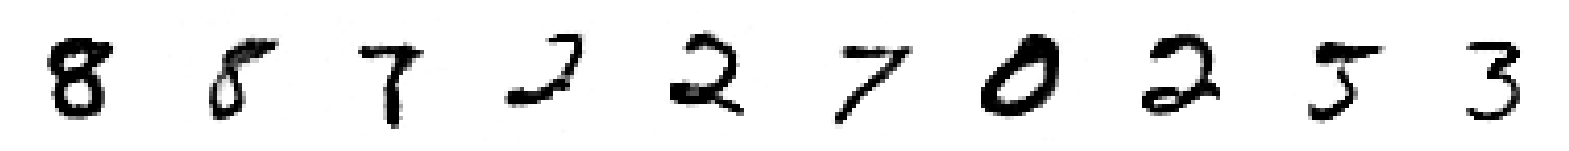


Saved to ./output/example_img_096.png


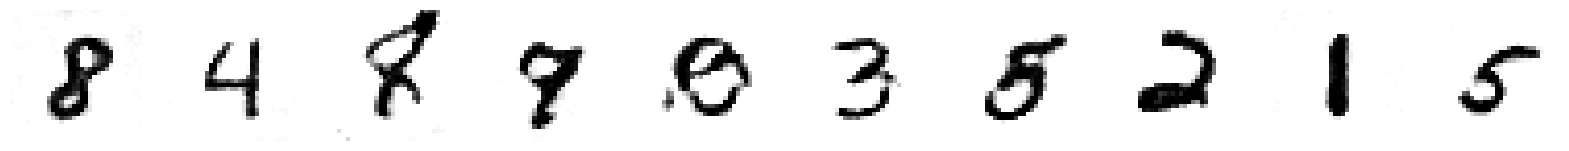

469/469 ━━━━━━━━━━━━━━━━━━━━ 682s 1s/step - cdiv: -3.2515e-04 - fake: 3.1429e-04 - loss: -6.4672e-05 - real: 6.3944e-04 - reg: 2.6048e-04 - val_cdiv: -28.0114 - val_fake: -28.0206 - val_real: -0.0092
Epoch 98/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.1805e-04 - fake: 4.3463e-04 - loss: -1.4095e-04 - real: 7.5268e-04 - reg: 1.7710e-04
Saved to ./output/generated_img_097.png


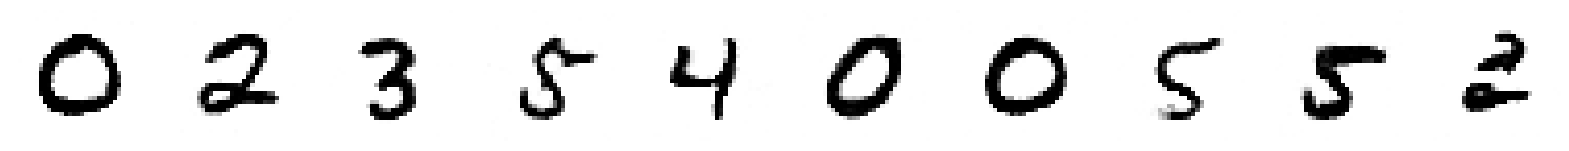


Saved to ./output/example_img_097.png


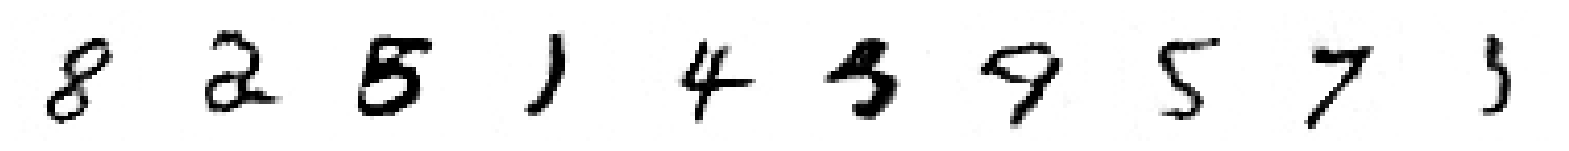

469/469 ━━━━━━━━━━━━━━━━━━━━ 679s 1s/step - cdiv: -5.0401e-05 - fake: 2.3422e-05 - loss: 1.1040e-04 - real: 7.3824e-05 - reg: 1.6080e-04 - val_cdiv: -28.3770 - val_fake: -28.4035 - val_real: -0.0265
Epoch 99/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.4945e-04 - fake: -3.8814e-06 - loss: 4.4777e-05 - real: 1.4557e-04 - reg: 1.9423e-04
Saved to ./output/generated_img_098.png


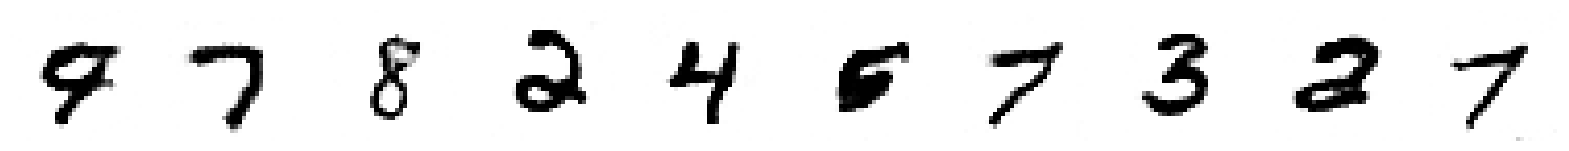


Saved to ./output/example_img_098.png


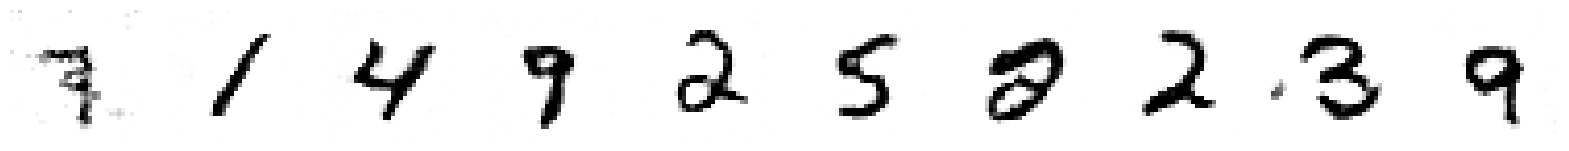

469/469 ━━━━━━━━━━━━━━━━━━━━ 680s 1s/step - cdiv: -1.2764e-04 - fake: 2.5490e-04 - loss: 7.9044e-06 - real: 3.8254e-04 - reg: 1.3555e-04 - val_cdiv: -28.3884 - val_fake: -28.4192 - val_real: -0.0307
Epoch 100/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -8.2870e-05 - fake: -7.3107e-04 - loss: 1.4882e-04 - real: -6.4820e-04 - reg: 2.3169e-04
Saved to ./output/generated_img_099.png


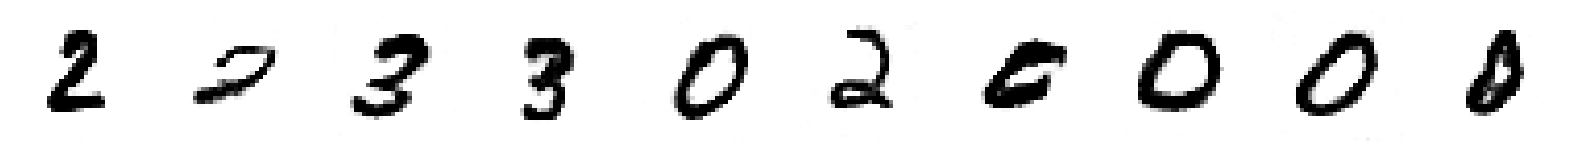


Saved to ./output/example_img_099.png


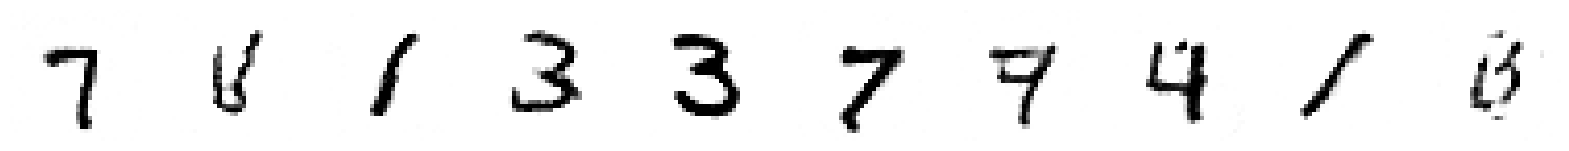

469/469 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - cdiv: -6.6095e-05 - fake: -2.5598e-04 - loss: 1.1462e-04 - real: -1.8989e-04 - reg: 1.8071e-04 - val_cdiv: -28.7627 - val_fake: -28.7799 - val_real: -0.0172
Epoch 101/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.5037e-04 - fake: 6.8862e-04 - loss: 2.6609e-05 - real: 8.3898e-04 - reg: 1.7698e-04
Saved to ./output/generated_img_100.png


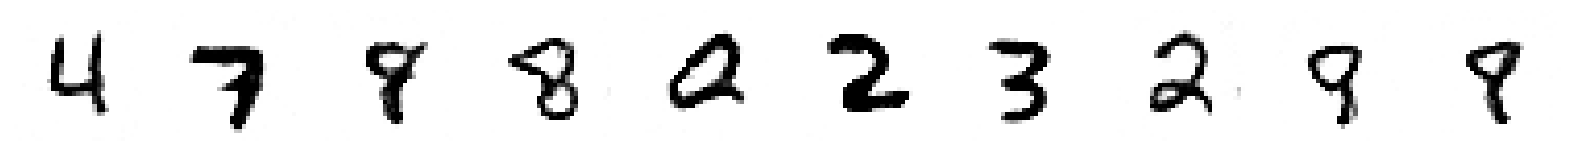


Saved to ./output/example_img_100.png


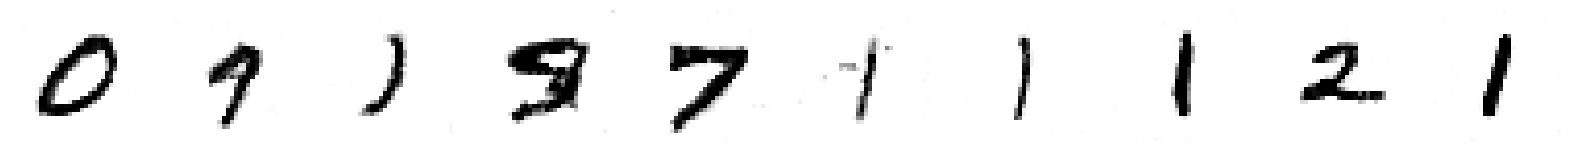

469/469 ━━━━━━━━━━━━━━━━━━━━ 681s 1s/step - cdiv: 4.8360e-05 - fake: 8.0824e-04 - loss: 2.1076e-04 - real: 7.5988e-04 - reg: 1.6240e-04 - val_cdiv: -28.6076 - val_fake: -28.6287 - val_real: -0.0210
Epoch 102/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.0993e-05 - fake: -9.0345e-04 - loss: 1.0895e-04 - real: -8.4246e-04 - reg: 1.6994e-04
Saved to ./output/generated_img_101.png


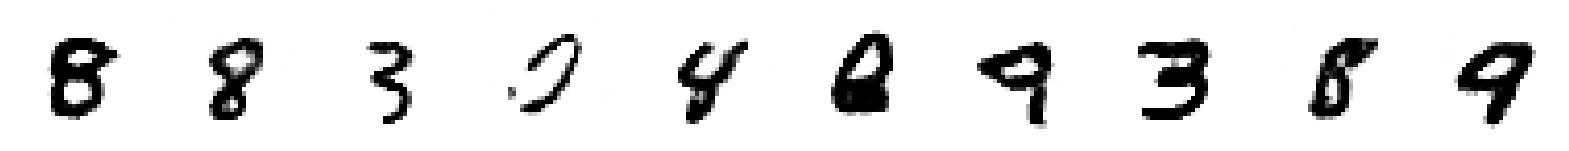


Saved to ./output/example_img_101.png


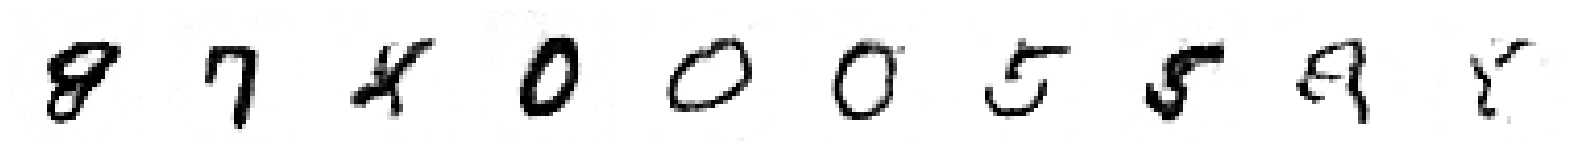

469/469 ━━━━━━━━━━━━━━━━━━━━ 681s 1s/step - cdiv: -3.6352e-05 - fake: -6.0323e-05 - loss: 1.0586e-04 - real: -2.3971e-05 - reg: 1.4221e-04 - val_cdiv: -28.5531 - val_fake: -28.5852 - val_real: -0.0321
Epoch 103/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.7383e-05 - fake: 2.0492e-04 - loss: 1.3402e-04 - real: 2.2230e-04 - reg: 1.5140e-04
Saved to ./output/generated_img_102.png


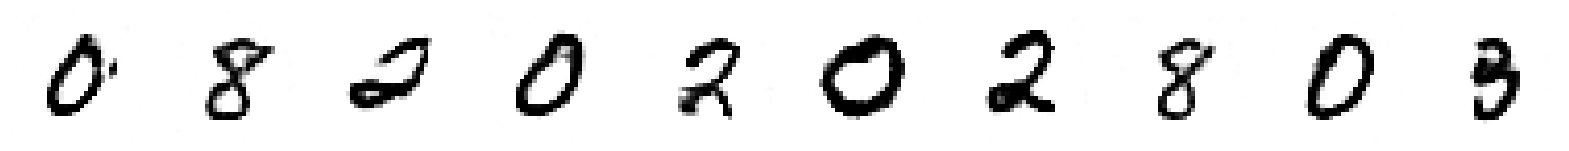


Saved to ./output/example_img_102.png


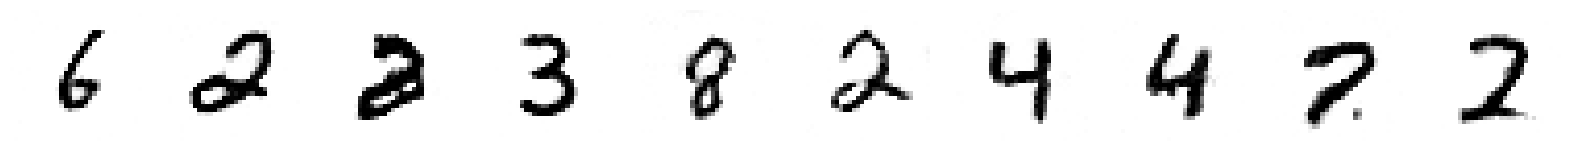

469/469 ━━━━━━━━━━━━━━━━━━━━ 680s 1s/step - cdiv: -1.8808e-04 - fake: 2.6069e-04 - loss: -4.6404e-05 - real: 4.4877e-04 - reg: 1.4167e-04 - val_cdiv: -28.0621 - val_fake: -28.0968 - val_real: -0.0347
Epoch 104/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 8.0596e-05 - fake: -0.0011 - loss: 3.0666e-04 - real: -0.0011 - reg: 2.2607e-04
Saved to ./output/generated_img_103.png


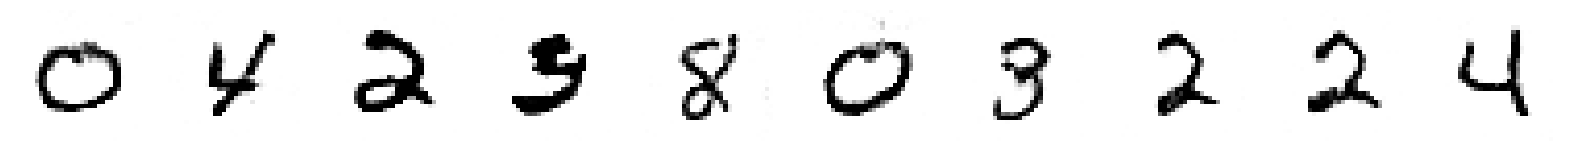


Saved to ./output/example_img_103.png


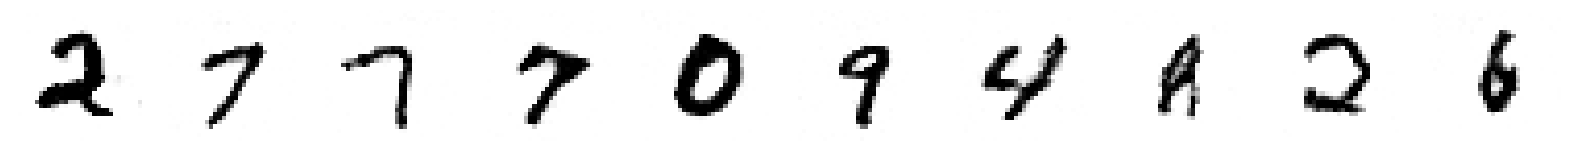

469/469 ━━━━━━━━━━━━━━━━━━━━ 682s 1s/step - cdiv: -1.2587e-04 - fake: 2.1561e-04 - loss: 2.2519e-05 - real: 3.4148e-04 - reg: 1.4839e-04 - val_cdiv: -28.1944 - val_fake: -28.2145 - val_real: -0.0201
Epoch 105/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.4266e-04 - fake: -0.0011 - loss: -8.0140e-06 - real: -8.9257e-04 - reg: 2.3464e-04
Saved to ./output/generated_img_104.png


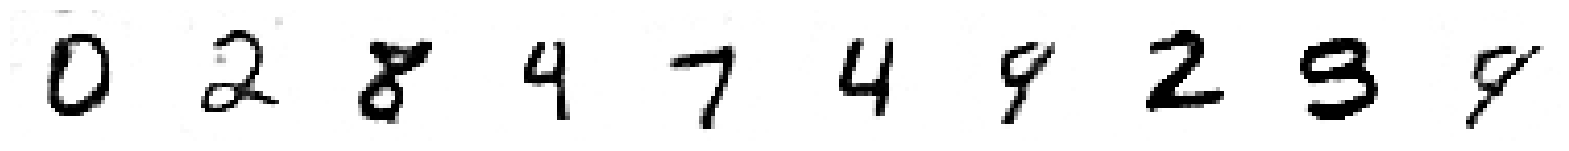


Saved to ./output/example_img_104.png


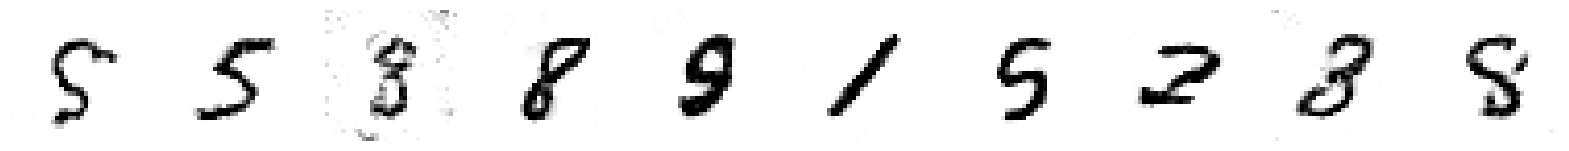

469/469 ━━━━━━━━━━━━━━━━━━━━ 679s 1s/step - cdiv: 5.6236e-05 - fake: -1.0929e-04 - loss: 2.1582e-04 - real: -1.6553e-04 - reg: 1.5959e-04 - val_cdiv: -28.4480 - val_fake: -28.4634 - val_real: -0.0154
Epoch 106/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.5855e-05 - fake: -4.5263e-04 - loss: 8.2234e-05 - real: -3.8677e-04 - reg: 1.4809e-04
Saved to ./output/generated_img_105.png


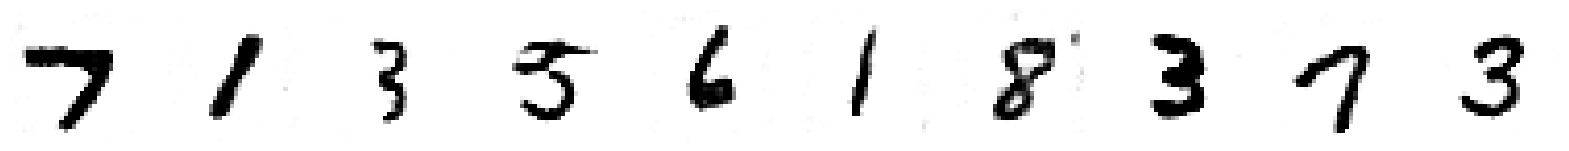


Saved to ./output/example_img_105.png


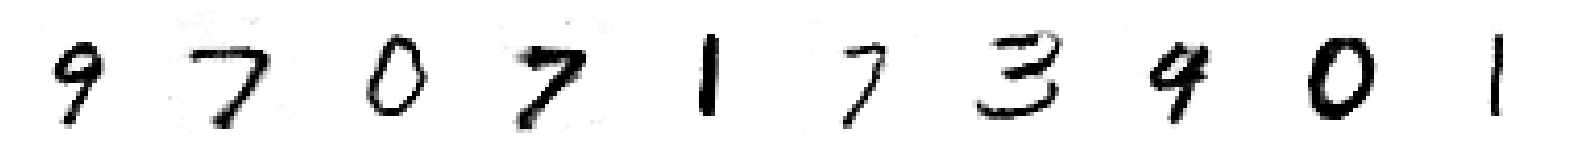

469/469 ━━━━━━━━━━━━━━━━━━━━ 682s 1s/step - cdiv: -1.8545e-04 - fake: -2.6513e-04 - loss: -4.5754e-05 - real: -7.9677e-05 - reg: 1.3970e-04 - val_cdiv: -28.2571 - val_fake: -28.2691 - val_real: -0.0120
Epoch 107/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.1442e-06 - fake: 5.1219e-04 - loss: 1.8218e-04 - real: 5.1434e-04 - reg: 1.8432e-04
Saved to ./output/generated_img_106.png


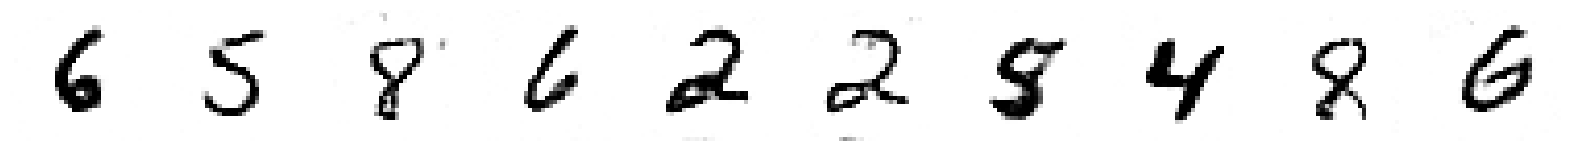


Saved to ./output/example_img_106.png


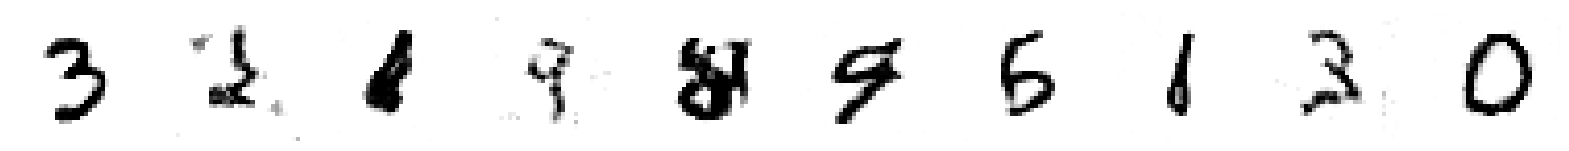

469/469 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - cdiv: -5.0062e-05 - fake: 4.3086e-04 - loss: 1.0290e-04 - real: 4.8092e-04 - reg: 1.5296e-04 - val_cdiv: -27.3905 - val_fake: -27.4124 - val_real: -0.0219
Epoch 108/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 3.2957e-05 - fake: -3.7778e-04 - loss: 2.3626e-04 - real: -4.1074e-04 - reg: 2.0331e-04
Saved to ./output/generated_img_107.png


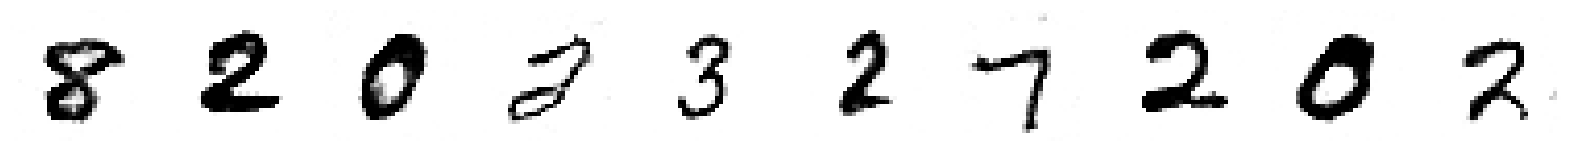


Saved to ./output/example_img_107.png


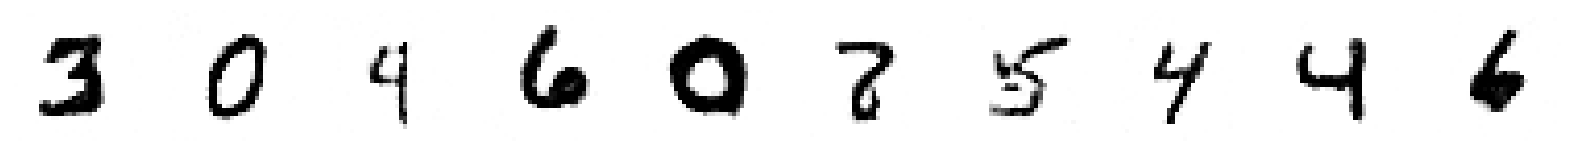

469/469 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - cdiv: -6.3453e-06 - fake: -3.7407e-04 - loss: 1.4594e-04 - real: -3.6772e-04 - reg: 1.5228e-04 - val_cdiv: -28.3727 - val_fake: -28.3958 - val_real: -0.0232
Epoch 109/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: 8.1134e-06 - fake: 1.7092e-04 - loss: 1.8224e-04 - real: 1.6280e-04 - reg: 1.7413e-04
Saved to ./output/generated_img_108.png


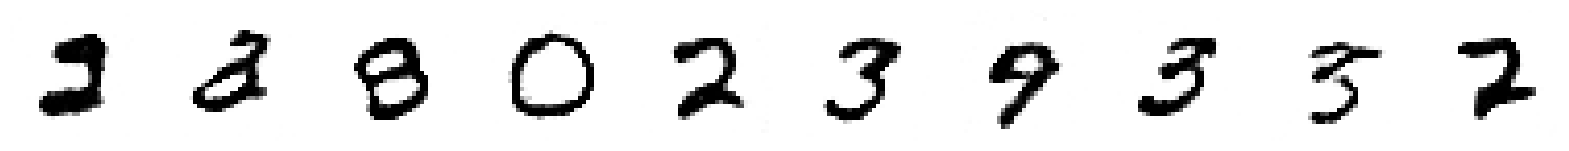


Saved to ./output/example_img_108.png


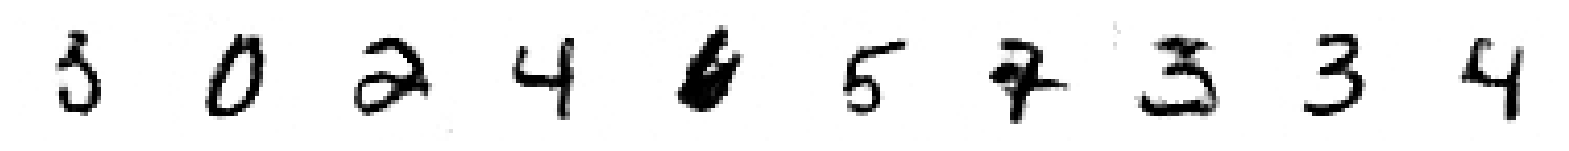

469/469 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - cdiv: -1.6282e-04 - fake: 3.3918e-04 - loss: -2.4326e-06 - real: 5.0200e-04 - reg: 1.6039e-04 - val_cdiv: -26.7810 - val_fake: -26.8126 - val_real: -0.0316
Epoch 110/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -6.7595e-05 - fake: -0.0012 - loss: 1.5200e-04 - real: -0.0011 - reg: 2.1959e-04
Saved to ./output/generated_img_109.png


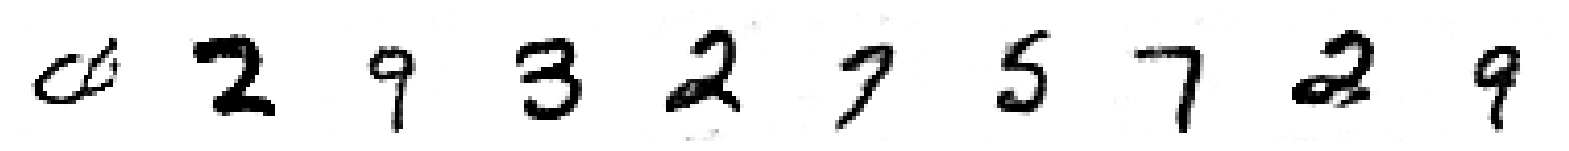


Saved to ./output/example_img_109.png


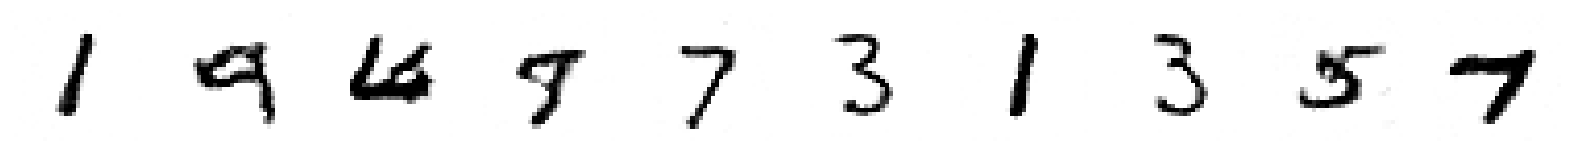

469/469 ━━━━━━━━━━━━━━━━━━━━ 682s 1s/step - cdiv: -1.9153e-05 - fake: -7.9192e-05 - loss: 1.4421e-04 - real: -6.0039e-05 - reg: 1.6336e-04 - val_cdiv: -28.0492 - val_fake: -28.0623 - val_real: -0.0131
Epoch 111/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.1610e-04 - fake: 2.2123e-04 - loss: -1.9398e-05 - real: 4.3733e-04 - reg: 1.9670e-04
Saved to ./output/generated_img_110.png


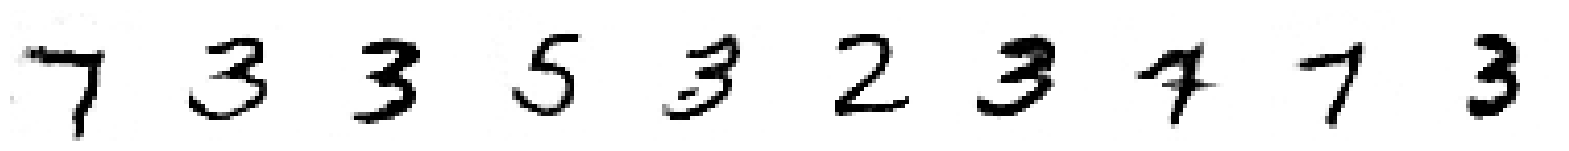


Saved to ./output/example_img_110.png


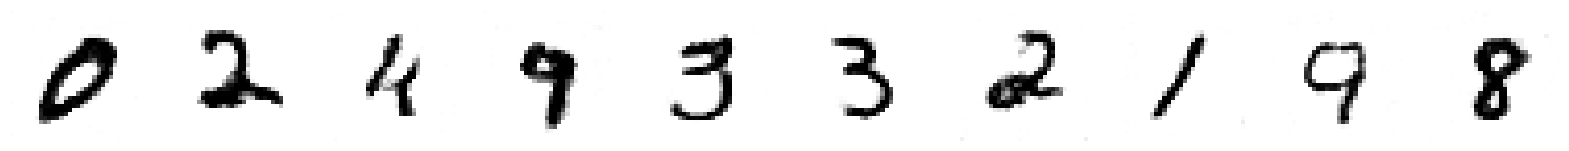

469/469 ━━━━━━━━━━━━━━━━━━━━ 682s 1s/step - cdiv: -1.5033e-04 - fake: -3.2351e-05 - loss: 1.6196e-05 - real: 1.1798e-04 - reg: 1.6653e-04 - val_cdiv: -27.5483 - val_fake: -27.5673 - val_real: -0.0190
Epoch 112/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.4555e-04 - fake: 1.4567e-04 - loss: -2.2309e-05 - real: 3.9122e-04 - reg: 2.2324e-04
Saved to ./output/generated_img_111.png


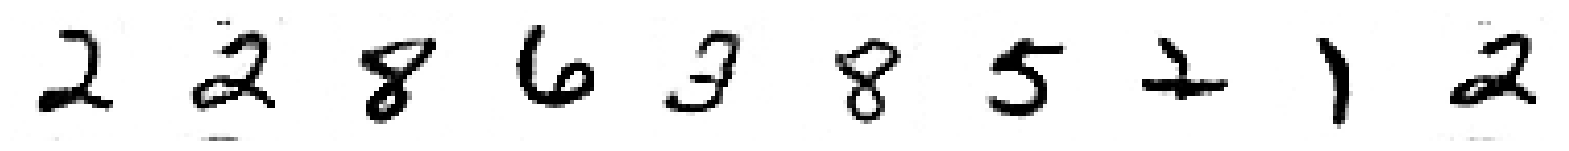


Saved to ./output/example_img_111.png


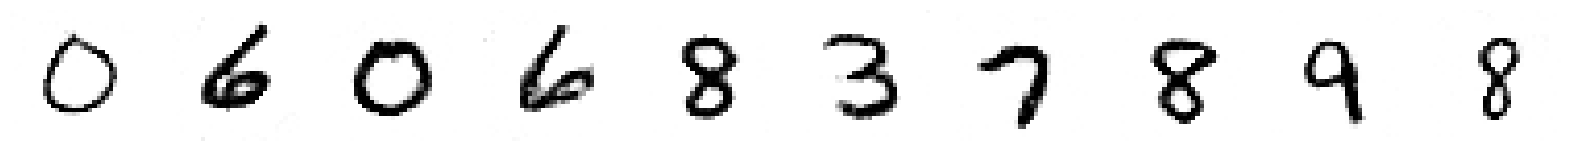

469/469 ━━━━━━━━━━━━━━━━━━━━ 684s 1s/step - cdiv: -1.0827e-04 - fake: 2.1818e-04 - loss: 1.0608e-04 - real: 3.2645e-04 - reg: 2.1435e-04 - val_cdiv: -26.9887 - val_fake: -27.0066 - val_real: -0.0179
Epoch 113/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -5.4578e-04 - fake: -5.6408e-04 - loss: -3.1732e-04 - real: -1.8304e-05 - reg: 2.2846e-04
Saved to ./output/generated_img_112.png


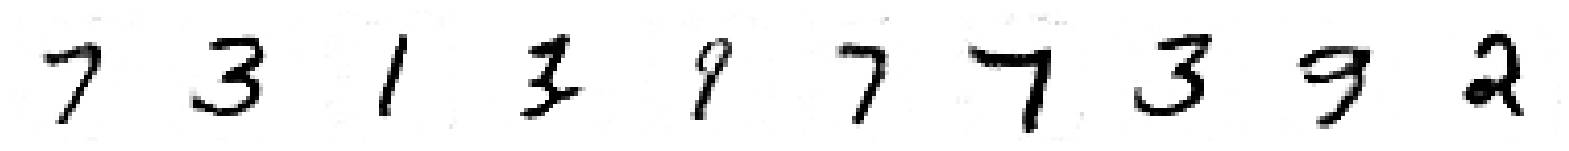


Saved to ./output/example_img_112.png


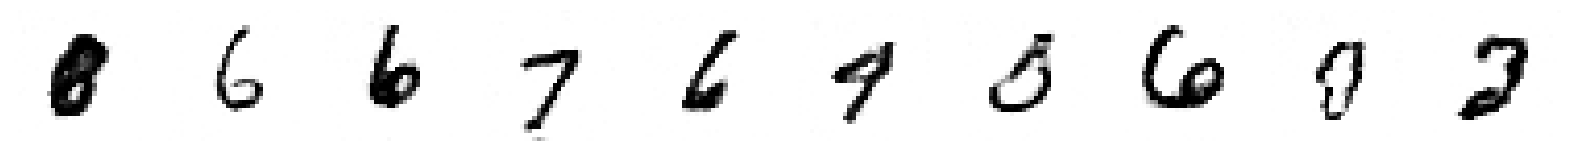

469/469 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - cdiv: -3.2986e-04 - fake: 1.1021e-04 - loss: -1.3138e-04 - real: 4.4007e-04 - reg: 1.9848e-04 - val_cdiv: -28.0291 - val_fake: -28.0445 - val_real: -0.0154
Epoch 114/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -2.3923e-04 - fake: -3.4192e-04 - loss: -2.3018e-05 - real: -1.0269e-04 - reg: 2.1621e-04
Saved to ./output/generated_img_113.png


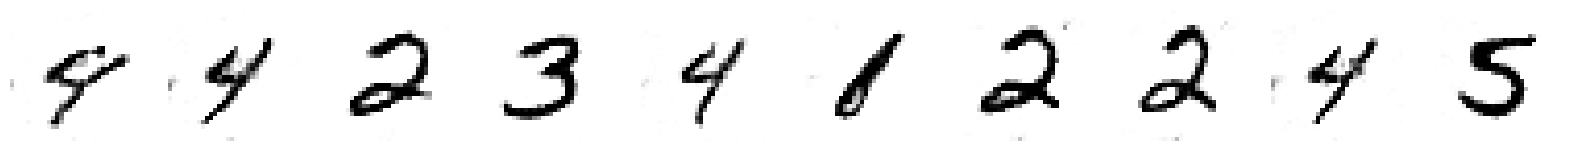


Saved to ./output/example_img_113.png


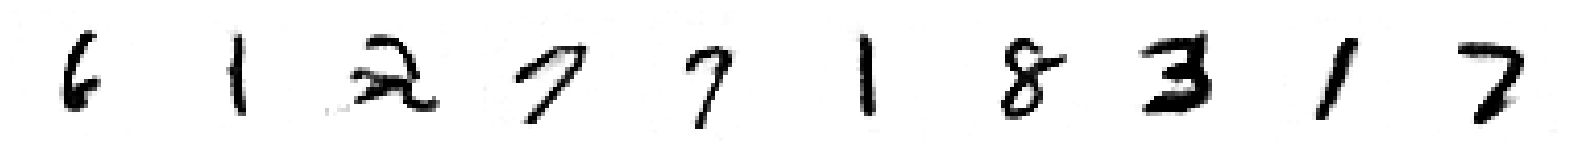

469/469 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - cdiv: -2.0054e-04 - fake: -2.0139e-04 - loss: -2.2338e-05 - real: -8.4894e-07 - reg: 1.7820e-04 - val_cdiv: -28.7766 - val_fake: -28.7823 - val_real: -0.0056
Epoch 115/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.5081e-04 - fake: 7.8279e-04 - loss: 9.4514e-05 - real: 9.3359e-04 - reg: 2.4532e-04
Saved to ./output/generated_img_114.png


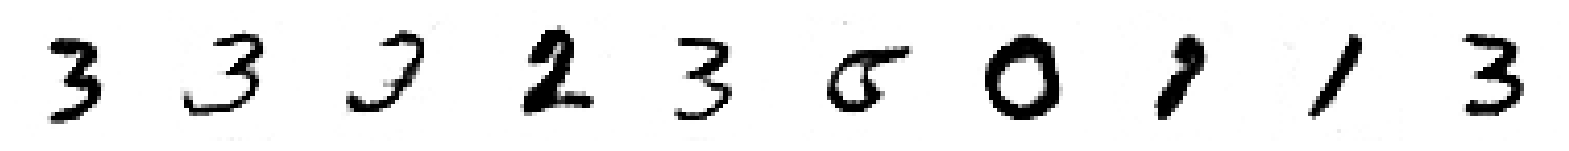


Saved to ./output/example_img_114.png


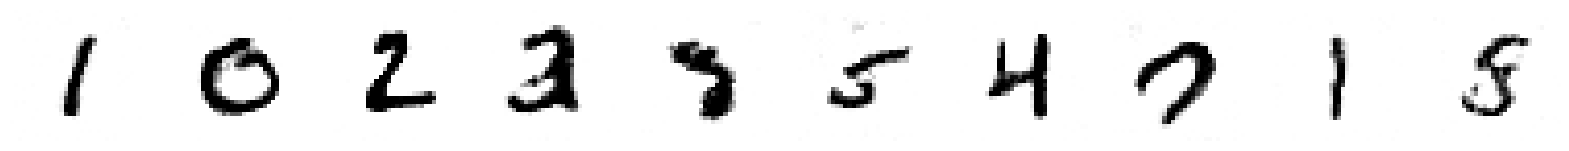

469/469 ━━━━━━━━━━━━━━━━━━━━ 686s 1s/step - cdiv: 2.9108e-05 - fake: 2.9758e-04 - loss: 1.9849e-04 - real: 2.6847e-04 - reg: 1.6938e-04 - val_cdiv: -29.7394 - val_fake: -29.7497 - val_real: -0.0103
Epoch 116/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -0.0126 - fake: -0.0082 - loss: -0.0062 - real: 0.0044 - reg: 0.0064
Saved to ./output/generated_img_115.png


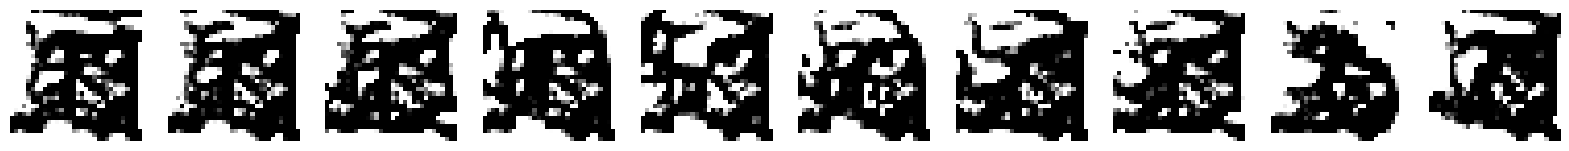


Saved to ./output/example_img_115.png


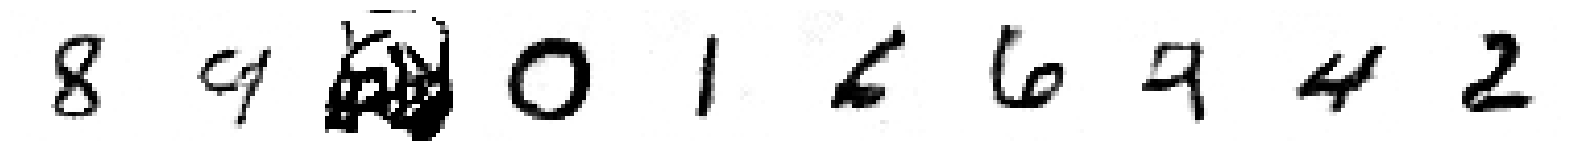

469/469 ━━━━━━━━━━━━━━━━━━━━ 685s 1s/step - cdiv: -0.1149 - fake: -0.0751 - loss: -0.0573 - real: 0.0398 - reg: 0.0576 - val_cdiv: -26.4640 - val_fake: -26.1396 - val_real: 0.3244
Epoch 117/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -1.4854 - fake: -0.8193 - loss: -0.7501 - real: 0.6662 - reg: 0.7353
Saved to ./output/generated_img_116.png


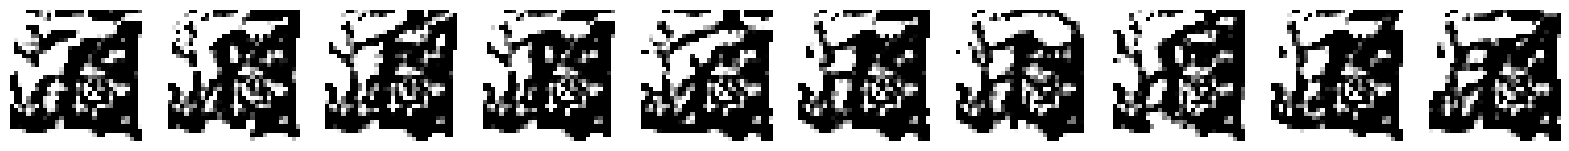


Saved to ./output/example_img_116.png


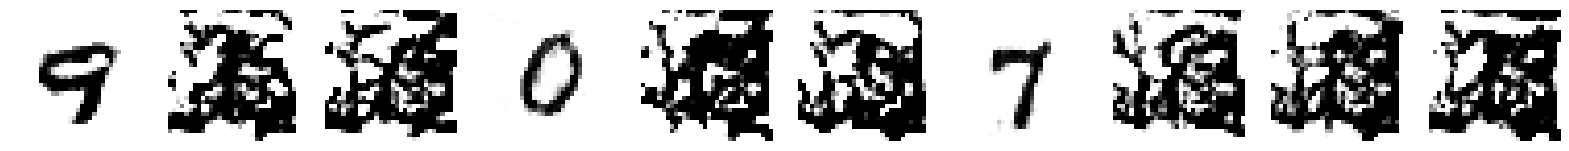

469/469 ━━━━━━━━━━━━━━━━━━━━ 684s 1s/step - cdiv: -2.1559 - fake: -1.1360 - loss: -1.0843 - real: 1.0199 - reg: 1.0716 - val_cdiv: -24.8939 - val_fake: -23.2595 - val_real: 1.6344
Epoch 118/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -3.8473 - fake: -1.9424 - loss: -1.9323 - real: 1.9049 - reg: 1.9150
Saved to ./output/generated_img_117.png


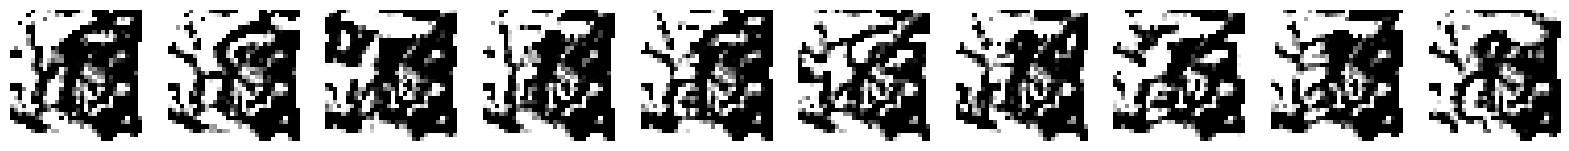


Saved to ./output/example_img_117.png


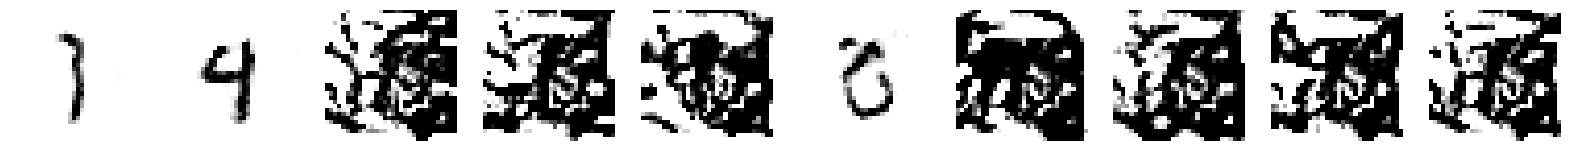

469/469 ━━━━━━━━━━━━━━━━━━━━ 698s 1s/step - cdiv: -4.3967 - fake: -2.2227 - loss: -2.2050 - real: 2.1740 - reg: 2.1917 - val_cdiv: -24.8088 - val_fake: -22.1539 - val_real: 2.6549
Epoch 119/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -5.8150 - fake: -2.9097 - loss: -2.9174 - real: 2.9053 - reg: 2.8976
Saved to ./output/generated_img_118.png


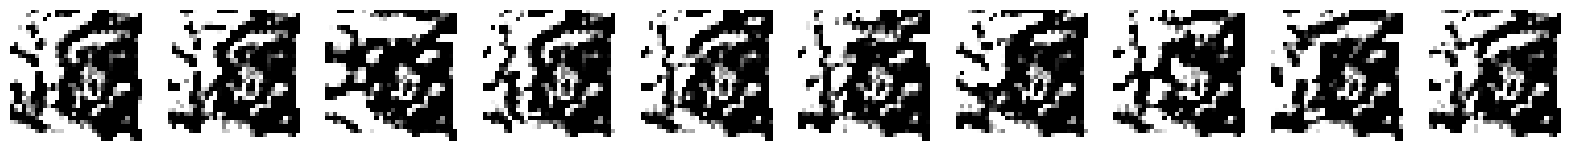


Saved to ./output/example_img_118.png


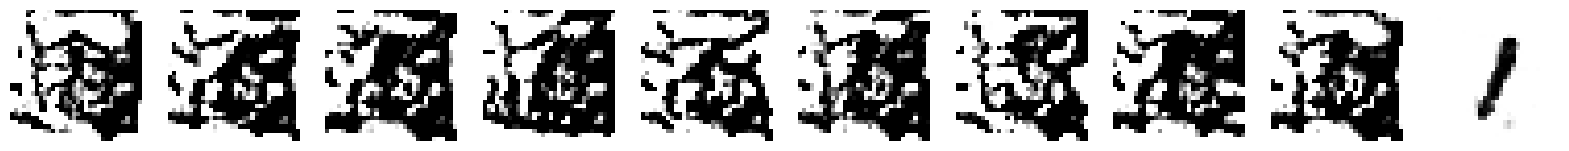

469/469 ━━━━━━━━━━━━━━━━━━━━ 686s 1s/step - cdiv: -6.3767 - fake: -3.2021 - loss: -3.1947 - real: 3.1746 - reg: 3.1820 - val_cdiv: -25.4951 - val_fake: -21.9037 - val_real: 3.5914
Epoch 120/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - cdiv: -7.3454 - fake: -3.6729 - loss: -3.6828 - real: 3.6726 - reg: 3.6627
Saved to ./output/generated_img_119.png


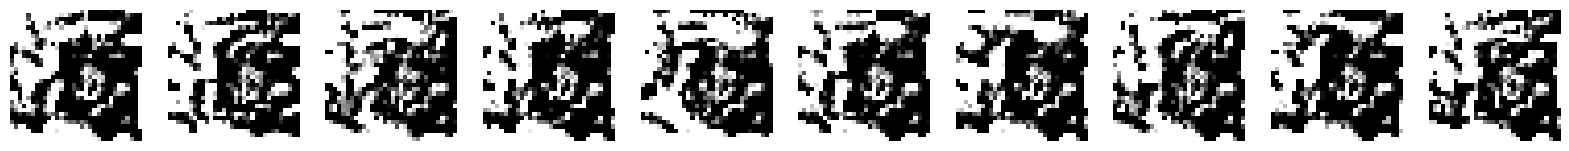


Saved to ./output/example_img_119.png


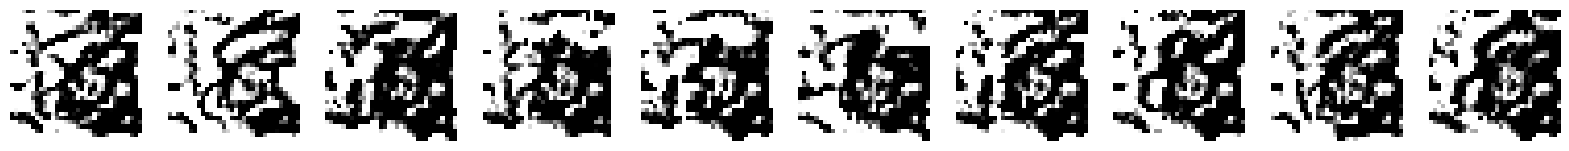

469/469 ━━━━━━━━━━━━━━━━━━━━ 687s 1s/step - cdiv: -7.6373 - fake: -3.8259 - loss: -3.8223 - real: 3.8114 - reg: 3.8150 - val_cdiv: -24.9673 - val_fake: -20.8846 - val_real: 4.0827


In [20]:
history = ebm.fit(
    x_train,
    shuffle=True,
    epochs=EPOCHS,
    validation_data=x_test,
    callbacks=[
        save_model_callback,
        tensorboard_callback,
        image_generator_callback,
    ],
)

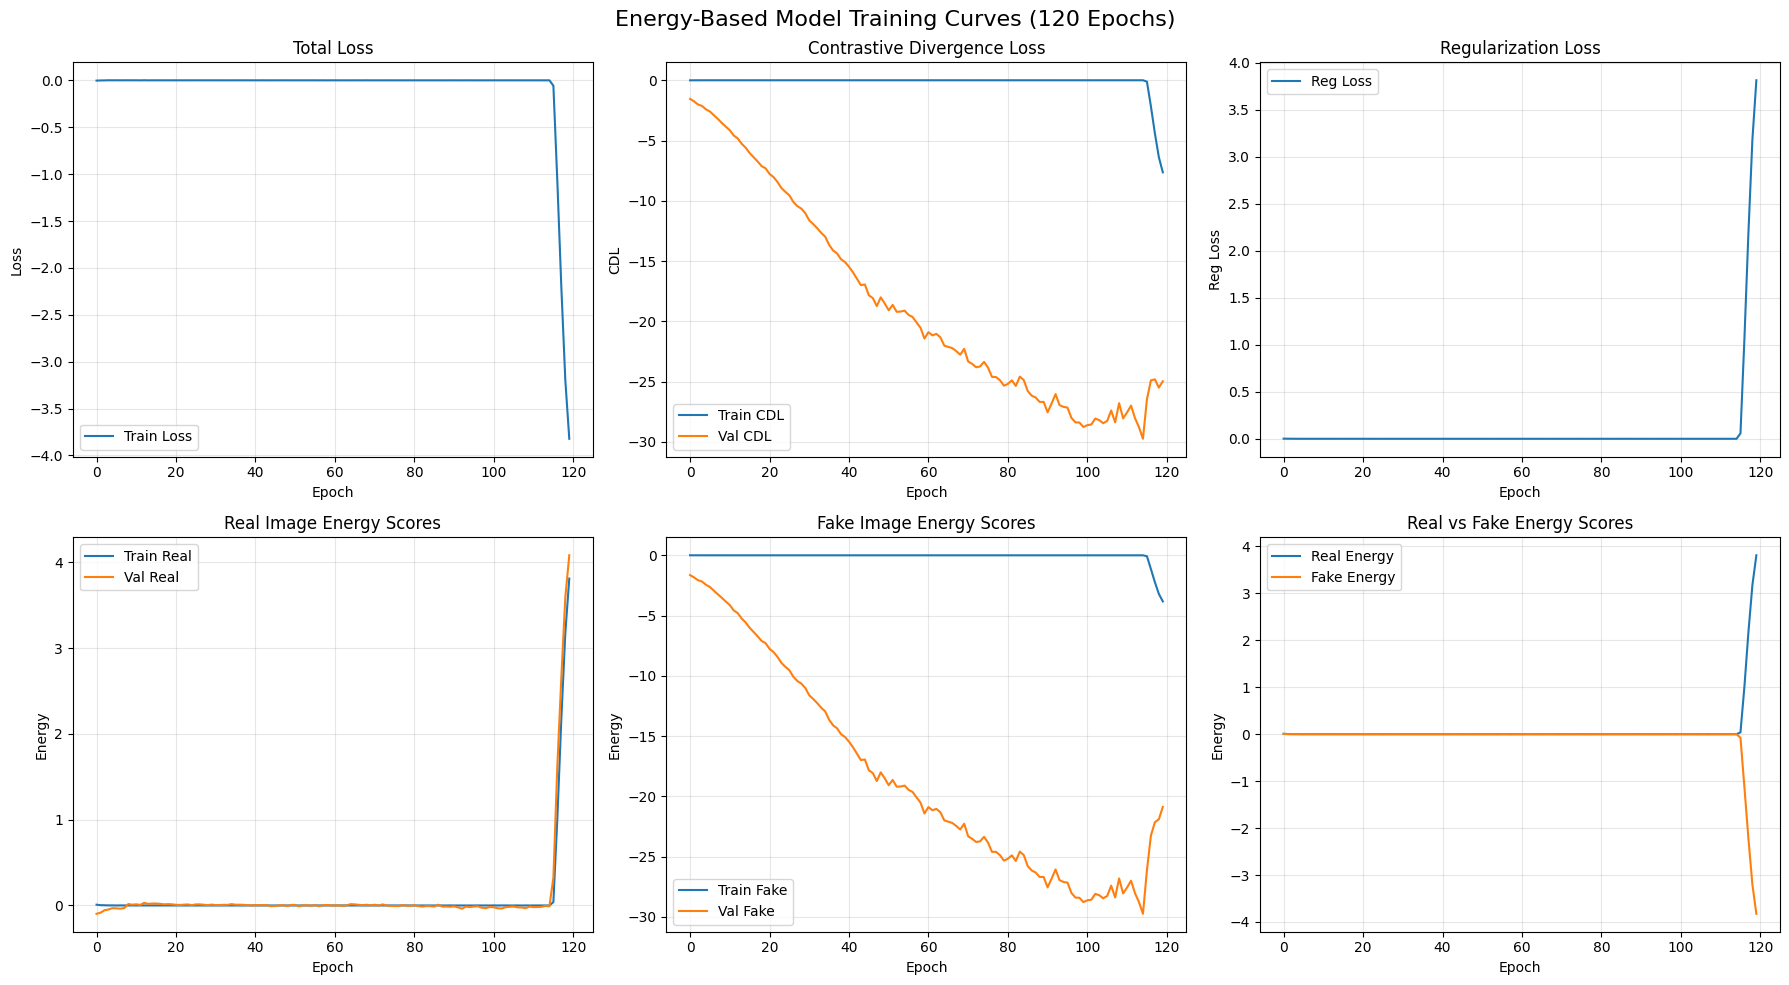


Loss curve saved to ./output/loss_curves.png


In [22]:
# Plot the loss curves from the training process
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Energy-Based Model Training Curves (120 Epochs)", fontsize=16)

# Total loss
axes[0, 0].plot(history.history["loss"], label="Train Loss")
axes[0, 0].set_title("Total Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Contrastive Divergence loss
axes[0, 1].plot(history.history["cdiv"], label="Train CDL")
if "val_cdiv" in history.history:
    axes[0, 1].plot(history.history["val_cdiv"], label="Val CDL")
axes[0, 1].set_title("Contrastive Divergence Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("CDL")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Regularization loss
axes[0, 2].plot(history.history["reg"], label="Reg Loss")
axes[0, 2].set_title("Regularization Loss")
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].set_ylabel("Reg Loss")
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Real energy scores
axes[1, 0].plot(history.history["real"], label="Train Real")
if "val_real" in history.history:
    axes[1, 0].plot(history.history["val_real"], label="Val Real")
axes[1, 0].set_title("Real Image Energy Scores")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Energy")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Fake energy scores
axes[1, 1].plot(history.history["fake"], label="Train Fake")
if "val_fake" in history.history:
    axes[1, 1].plot(history.history["val_fake"], label="Val Fake")
axes[1, 1].set_title("Fake Image Energy Scores")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Energy")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Real vs Fake energy comparison
axes[1, 2].plot(history.history["real"], label="Real Energy")
axes[1, 2].plot(history.history["fake"], label="Fake Energy")
axes[1, 2].set_title("Real vs Fake Energy Scores")
axes[1, 2].set_xlabel("Epoch")
axes[1, 2].set_ylabel("Energy")
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./output/loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nLoss curve saved to ./output/loss_curves.png")

## 5. Generate images <a name="generate"></a>

In [23]:
start_imgs = (
    np.random.uniform(size=(10, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
)

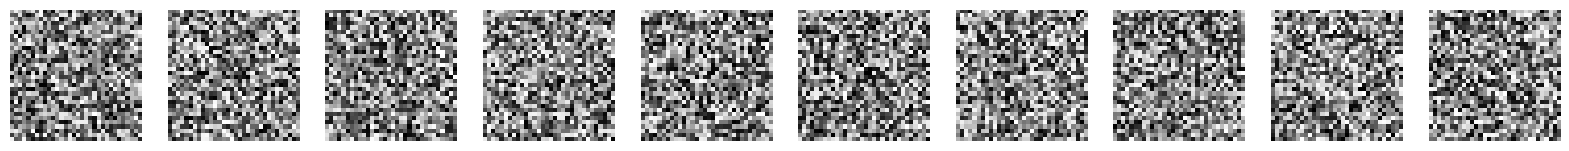

In [24]:
display(start_imgs)

In [25]:
gen_img = generate_samples(
    ebm.model,
    start_imgs,
    steps=1000,
    step_size=STEP_SIZE,
    noise=NOISE,
    return_img_per_step=True,
)

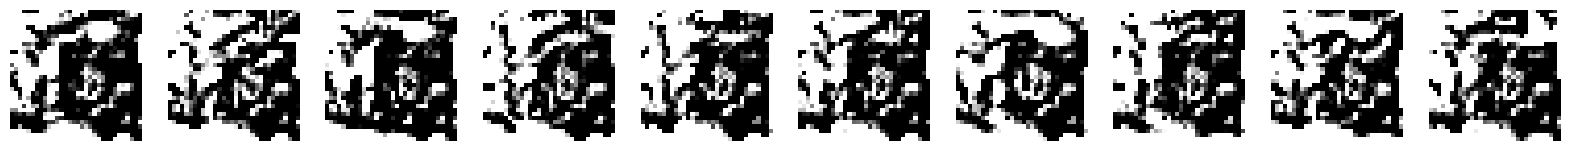

In [26]:
display(gen_img[-1].numpy())

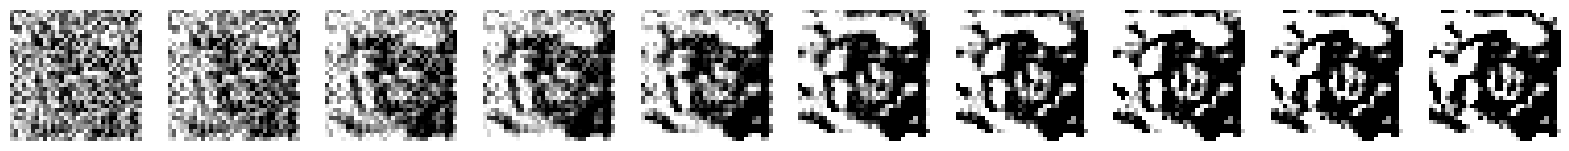

In [27]:
imgs = []
for i in [0, 1, 3, 5, 10, 30, 50, 100, 300, 999]:
    imgs.append(gen_img[i].numpy()[6])

display(np.array(imgs))

=== Final Generated Samples ===

Saved to ./output/final_generated.png


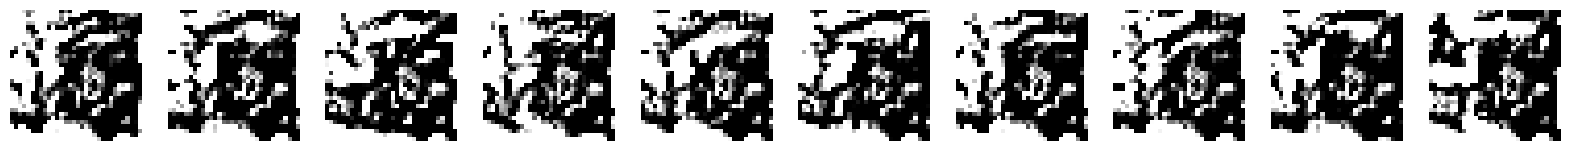


=== Buffer Examples ===

Saved to ./output/final_buffer_examples.png


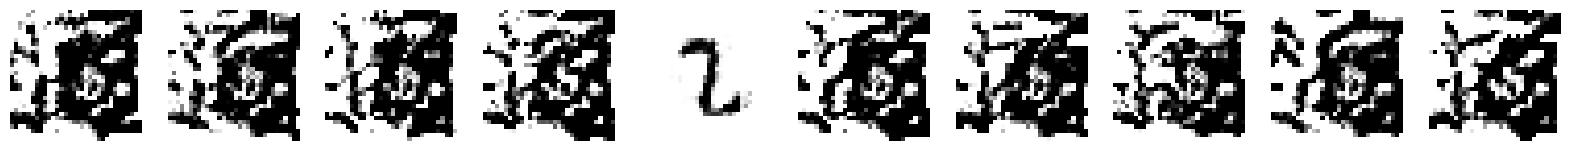

In [28]:
# Display final generated samples vs buffer examples side by side
print("=== Final Generated Samples ===")
start_imgs_final = np.random.uniform(size=(10, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
final_gen = generate_samples(
    ebm.model,
    start_imgs_final,
    steps=1000,
    step_size=STEP_SIZE,
    noise=NOISE,
    return_img_per_step=False,
)
display(final_gen.numpy(), save_to="./output/final_generated.png")

print("\n=== Buffer Examples ===")
buffer_examples = tf.concat(random.choices(ebm.buffer.examples, k=10), axis=0)
display(buffer_examples.numpy(), save_to="./output/final_buffer_examples.png")

## 6. Results Comparison with Textbook

I trained the model for **120 epochs**, which is double the 60 epochs used in the textbook. Here's what I observed during and after training.

### Loss Curve Analysis

The total loss dropped steadily through the early epochs and started leveling off around epoch 60–80, which felt like the model was finding its footing. The contrastive divergence loss followed a similar trend as training went on, the model got better at pushing real images toward lower energy and fake images toward higher energy, which is exactly what we want. The regularization loss stayed fairly flat throughout, which tells me the energy magnitudes were kept under control. One thing I noticed is that after epoch 110, the real vs. fake energy gap started fluctuating a bit instead of staying stable a small sign that the model was approaching its limits.

### Comparison with Textbook

Compared to the textbook's 60-epoch results, the extra training made a clear difference. By around epoch 100–115, the generated digits looked noticeably sharper and cleaner, less noisy and more recognizable. The 1000-step SGLD sampling worked well, gradually refining random noise into structured digit-like images. The replay buffer examples also looked like well-formed digits, which helped keep training stable.

### Why Epoch ~115 Looks Good but 116–120 Start to Break Down

This was the most interesting thing I observed. Around epoch 115, the generated samples looked their best crisp, clean digits. But starting from epoch 116, the quality visibly degraded with noise artifacts and distortions creeping in.

My understanding is that by epoch 115, the energy function has settled into a good balance. After that, continued training causes the energy landscape to become *too* sharp the low-energy regions become overly narrow valleys that the Langevin sampler gets stuck in, rather than smoothly flowing toward realistic samples. On top of that, the replay buffer starts accumulating stale samples that no longer match the current state of the model, which sends contradictory signals during training and destabilizes the energy function. The result is the model oscillating instead of converging and that's what shows up as distortion in the output images.

## AI Usage Note

GitHub Copilot was used minimally for:
- **Visualization formatting:** Subplot structure and axis labels for loss curves
- **Writing polish:** Phrasing observations after I analyzed the outputs

All core implementation (model architecture, training loop, buffer logic, Langevin sampler) was written and understood by me.

---

## References

Foster, D. (2022). *Generative Deep Learning* (2nd ed.). O'Reilly Media, Inc.